In [1]:
# ========================================================================
# SETUP DE PATHS - USAR source/config.py (NÃO HARDCODED PATHS!)
# ========================================================================

import sys
from pathlib import Path

# Adicionar source ao path
notebook_dir = Path.cwd()

# Se estiver na pasta EDA, subir dois níveis para chegar ao root do projeto
if notebook_dir.name == 'EDA':
    project_root = notebook_dir.parent.parent
elif notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

sys.path.insert(0, str(project_root))

print(f"Notebook directory: {notebook_dir}")
print(f"Project root: {project_root}")

# Importar configuração
from source.config import (
    PROJ_ROOT, DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR, EXTERNAL_DATA_DIR,
    MODELS_DIR, FIGURES_DIR, get_data_path, get_model_path, get_figure_path
)

from loguru import logger

logger.info(f"📁 Projeto: {PROJ_ROOT}")
logger.info(f"📁 Dados: {DATA_DIR}")
logger.info(f"📁 Figuras: {FIGURES_DIR}")

# ========================================================================

Notebook directory: c:\Users\win\Desktop\TCC\money_laundering\notebooks\EDA
Project root: c:\Users\win\Desktop\TCC\money_laundering
2026-01-31 17:40:06.951 | INFO     | source.config:<module>:77 - [CONFIG] PROJ_ROOT: C:\Users\win\Desktop\TCC\money_laundering
2026-01-31 17:40:06.954 | INFO     | source.config:<module>:78 - [CONFIG] Python executando de: c:\Users\win\Desktop\TCC\money_laundering\notebooks\EDA
2026-01-31 17:40:06.954 | INFO     | __main__:<module>:32 - 📁 Projeto: C:\Users\win\Desktop\TCC\money_laundering
2026-01-31 17:40:06.955 | INFO     | __main__:<module>:33 - 📁 Dados: C:\Users\win\Desktop\TCC\money_laundering\data
2026-01-31 17:40:06.955 | INFO     | __main__:<module>:34 - 📁 Figuras: C:\Users\win\Desktop\TCC\money_laundering\reports\figures


# Análise Exploratória de Dados (EDA) - Anti-Money Laundering

**REFATORADO:** Agora usa `source/config.py` para todos os paths (zero hardcoding)

**Metodologia:** Scikit-Learn Production Pipelines  
**Data:** Janeiro 2026

## 1. Importação de Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados

In [3]:
# Carregar dados usando config.py (NÃO hardcoded path)
file_path = get_data_path('trans_enriched.csv', 'raw')
df = pd.read_csv(file_path)

logger.success(f"✅ Dataset carregado de: {file_path}")
logger.info(f"Shape: {df.shape}")
logger.info(f"Total de registros: {df.shape[0]:,}")
logger.info(f"Total de colunas: {df.shape[1]}")

2026-01-31 17:42:05.432 | SUCCESS  | __main__:<module>:5 - ✅ Dataset carregado de: C:\Users\win\Desktop\TCC\money_laundering\data\raw\trans_enriched.csv
2026-01-31 17:42:05.434 | INFO     | __main__:<module>:6 - Shape: (31251483, 21)
2026-01-31 17:42:05.435 | INFO     | __main__:<module>:7 - Total de registros: 31,251,483
2026-01-31 17:42:05.435 | INFO     | __main__:<module>:8 - Total de colunas: 21


## 3. Visão Geral dos Dados

In [4]:
# Primeiras linhas
print("=" * 80)
print("PRIMEIRAS 5 LINHAS DO DATASET")
print("=" * 80)
display(df.head())

PRIMEIRAS 5 LINHAS DO DATASET


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,...,From Bank Name,Bank ID,Account Number,From Entity ID,From Entity Name,To Bank Name,Bank ID_To,Account Number_To,To Entity ID,To Entity Name
0,2022/09/01 00:15,20,800104D70,20,800104D70,8095.07,US Dollar,8095.07,US Dollar,Reinvestment,...,Regents Credit Union,20,800104D70,2AA23697070,Sole Proprietorship #1,Regents Credit Union,20,800104D70,2AA23697070,Sole Proprietorship #1
1,2022/09/01 00:18,3196,800107150,3196,800107150,7739.29,US Dollar,7739.29,US Dollar,Reinvestment,...,Bank of Philadelphia,3196,800107150,2AA23466990,Partnership #1,Bank of Philadelphia,3196,800107150,2AA23466990,Partnership #1
2,2022/09/01 00:23,1208,80010E430,1208,80010E430,2654.22,US Dollar,2654.22,US Dollar,Reinvestment,...,Bank of Danbury,1208,80010E430,2AA237140E0,Sole Proprietorship #2,Bank of Danbury,1208,80010E430,2AA237140E0,Sole Proprietorship #2
3,2022/09/01 00:19,3203,80010EA80,3203,80010EA80,13284.41,US Dollar,13284.41,US Dollar,Reinvestment,...,Savings Bank of Augusta,3203,80010EA80,2AA23134470,Sole Proprietorship #3,Savings Bank of Augusta,3203,80010EA80,2AA23134470,Sole Proprietorship #3
4,2022/09/01 00:27,20,800104D20,20,800104D20,9.72,US Dollar,9.72,US Dollar,Reinvestment,...,Regents Credit Union,20,800104D20,2AA1FB24CC0,Individual #1,Regents Credit Union,20,800104D20,2AA1FB24CC0,Individual #1


In [5]:
# Informações sobre tipos de dados
print("=" * 80)
print("INFORMAÇÕES DO DATASET")
print("=" * 80)
df.info()

INFORMAÇÕES DO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 31251483 entries, 0 to 31251482
Data columns (total 21 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   From Account        str    
 3   To Bank             int64  
 4   To Account          str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
 11  From Bank Name      str    
 12  Bank ID             int64  
 13  Account Number      str    
 14  From Entity ID      str    
 15  From Entity Name    str    
 16  To Bank Name        str    
 17  Bank ID_To          int64  
 18  Account Number_To   str    
 19  To Entity ID        str    
 20  To Entity Name      str    
dtypes: float64(2), int64(5), str(14)
memory usage: 10.0 GB


In [6]:
# Tipos de dados por coluna
print("=" * 80)
print("TIPOS DE DADOS")
print("=" * 80)
print(df.dtypes)

TIPOS DE DADOS
Timestamp                 str
From Bank               int64
From Account              str
To Bank                 int64
To Account                str
Amount Received       float64
Receiving Currency        str
Amount Paid           float64
Payment Currency          str
Payment Format            str
Is Laundering           int64
From Bank Name            str
Bank ID                 int64
Account Number            str
From Entity ID            str
From Entity Name          str
To Bank Name              str
Bank ID_To              int64
Account Number_To         str
To Entity ID              str
To Entity Name            str
dtype: object


## 4. Análise de Valores Ausentes

In [7]:
# Valores ausentes
print("=" * 80)
print("VALORES AUSENTES")
print("=" * 80)

missing_data = pd.DataFrame({
    'Total_Missing': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total_Missing'] > 0].sort_values('Total_Missing', ascending=False)

if len(missing_data) > 0:
    display(missing_data)
    
    # Visualização
    plt.figure(figsize=(12, 6))
    missing_data['Percentage'].plot(kind='barh', color='coral')
    plt.xlabel('Percentual de Valores Ausentes (%)')
    plt.title('Percentual de Valores Ausentes por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("✓ Não há valores ausentes no dataset!")

VALORES AUSENTES
✓ Não há valores ausentes no dataset!


## 5. Análise de Duplicados

In [8]:
# Verificação de duplicados
print("=" * 80)
print("ANÁLISE DE DUPLICADOS")
print("=" * 80)

total_duplicates = df.duplicated().sum()
percentage_duplicates = (total_duplicates / len(df) * 100).round(2)

print(f"Total de registros duplicados: {total_duplicates:,}")
print(f"Percentual de duplicados: {percentage_duplicates}%")

if total_duplicates > 0:
    print("\nExemplos de registros duplicados:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("\n✓ Não há registros duplicados no dataset!")

ANÁLISE DE DUPLICADOS
Total de registros duplicados: 14
Percentual de duplicados: 0.0%

Exemplos de registros duplicados:


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,...,From Bank Name,Bank ID,Account Number,From Entity ID,From Entity Name,To Bank Name,Bank ID_To,Account Number_To,To Entity ID,To Entity Name
2926923,2022/09/01 12:55,28977,8166FF501,1218000,84FDFB3F1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,...,Bank of Houston,28977,8166FF501,2AA2346A5B0,Corporation #2659,Crytpo Bank #551,1218000,84FDFB3F1,2AA21128590,Sole Proprietorship #142813
2926927,2022/09/01 12:55,28977,8166FF501,1218000,84FDFB3F1,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,...,Bank of Houston,28977,8166FF501,2AA2346A5B0,Corporation #2659,Crytpo Bank #551,1218000,84FDFB3F1,2AA21128590,Sole Proprietorship #142813
8888241,2022/09/04 21:27,113547,810733831,113547,810733830,0.000001,Bitcoin,0.010000,US Dollar,ACH,...,Sappo Credit Union,113547,810733831,2AA233D9E90,Partnership #27910,Sappo Credit Union,113547,810733830,2AA201E0740,Sole Proprietorship #21782
8888242,2022/09/04 21:27,113547,810733831,2210310,84CBF2891,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,...,Sappo Credit Union,113547,810733831,2AA233D9E90,Partnership #27910,Crytpo Bank #19,2210310,84CBF2891,2AA21128590,Sole Proprietorship #142813
8888243,2022/09/04 21:27,113547,810733831,113547,810733830,0.000001,Bitcoin,0.010000,US Dollar,ACH,...,Sappo Credit Union,113547,810733831,2AA233D9E90,Partnership #27910,Sappo Credit Union,113547,810733830,2AA201E0740,Sole Proprietorship #21782
8888244,2022/09/04 21:27,113547,810733831,2210310,84CBF2891,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,...,Sappo Credit Union,113547,810733831,2AA233D9E90,Partnership #27910,Crytpo Bank #19,2210310,84CBF2891,2AA21128590,Sole Proprietorship #142813
12923005,2022/09/07 01:02,23710,80B5BDEE1,1214789,84F62EB91,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,...,The Pine Community Bank,23710,80B5BDEE1,2AA22ED91F0,Sole Proprietorship #9625,Crytpo Bank #615,1214789,84F62EB91,2AA1FB799E0,Partnership #142215
12923007,2022/09/07 01:02,23710,80B5BDEE1,1214789,84F62EB91,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,...,The Pine Community Bank,23710,80B5BDEE1,2AA22ED91F0,Sole Proprietorship #9625,Crytpo Bank #615,1214789,84F62EB91,2AA1FB799E0,Partnership #142215
13879036,2022/09/07 13:50,233594,8205F45E1,233594,8205F45E0,0.000001,Bitcoin,0.010000,US Dollar,ACH,...,Bank of Seattle,233594,8205F45E1,2AA237CC530,Partnership #31079,Bank of Seattle,233594,8205F45E0,2AA2063BFE0,Sole Proprietorship #148252
13879037,2022/09/07 13:50,233594,8205F45E1,1210027,8503D2651,0.000001,Bitcoin,0.000001,Bitcoin,Bitcoin,...,Bank of Seattle,233594,8205F45E1,2AA237CC530,Partnership #31079,Crytpo Bank #26,1210027,8503D2651,2AA2385E860,Direct #1


## 6. Identificação de Variáveis Numéricas e Categóricas

In [9]:
# Separação de variáveis numéricas e categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("=" * 80)
print("TIPOS DE VARIÁVEIS")
print("=" * 80)
print(f"\n📊 Variáveis Numéricas ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  • {col}")

print(f"\n📝 Variáveis Categóricas ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  • {col}")

TIPOS DE VARIÁVEIS

📊 Variáveis Numéricas (7):
  • From Bank
  • To Bank
  • Amount Received
  • Amount Paid
  • Is Laundering
  • Bank ID
  • Bank ID_To

📝 Variáveis Categóricas (14):
  • Timestamp
  • From Account
  • To Account
  • Receiving Currency
  • Payment Currency
  • Payment Format
  • From Bank Name
  • Account Number
  • From Entity ID
  • From Entity Name
  • To Bank Name
  • Account Number_To
  • To Entity ID
  • To Entity Name


## 6.1. Distribuição da Variável Alvo (Is Laundering)

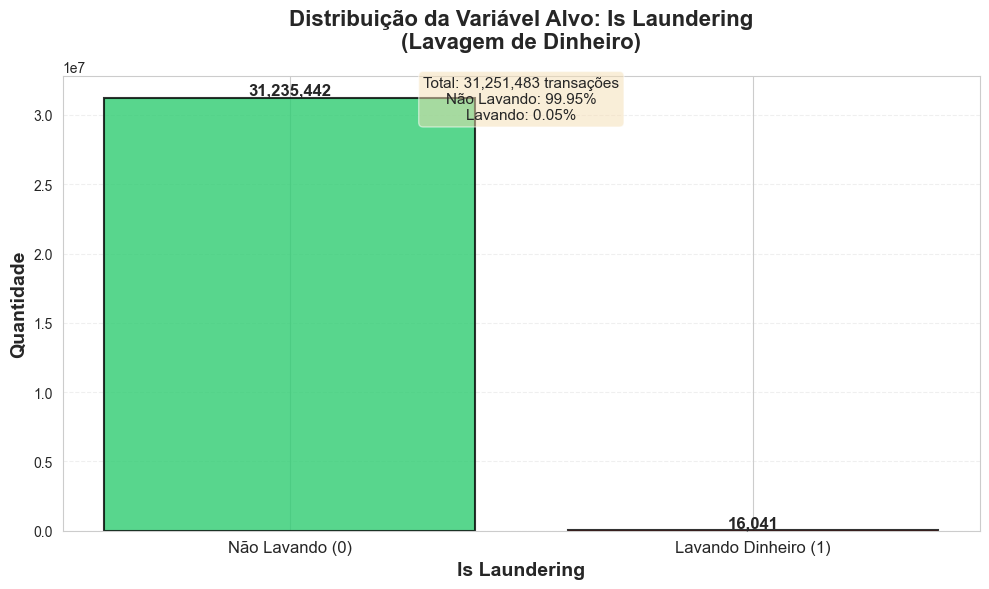

DISTRIBUIÇÃO DA VARIÁVEL ALVO: IS LAUNDERING

📊 Quantidade de transações por categoria:
  • Não Lavando (0): 31,235,442 (99.95%)
  • Lavando Dinheiro (1): 16,041 (0.05%)

📈 Total de transações: 31,251,483
📊 Proporção: 1 lavagem para cada 1947.23 transações normais


In [10]:
# Análise da variável alvo Is Laundering
import matplotlib.pyplot as plt

# Contagem dos valores
laundering_counts = df['Is Laundering'].value_counts()

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
bars = plt.bar(laundering_counts.index, laundering_counts.values, 
               color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5)

# Adicionar rótulos nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Configurações do gráfico
plt.xlabel('Is Laundering', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade', fontsize=14, fontweight='bold')
plt.title('Distribuição da Variável Alvo: Is Laundering\n(Lavagem de Dinheiro)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks([0, 1], ['Não Lavando (0)', 'Lavando Dinheiro (1)'], fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Adicionar informações percentuais
total = laundering_counts.sum()
percentages = (laundering_counts / total * 100).round(2)
plt.text(0.5, max(laundering_counts.values) * 0.95, 
         f'Total: {total:,} transações\n'
         f'Não Lavando: {percentages[0]:.2f}%\n'
         f'Lavando: {percentages[1]:.2f}%',
         ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("=" * 80)
print("DISTRIBUIÇÃO DA VARIÁVEL ALVO: IS LAUNDERING")
print("=" * 80)
print(f"\n📊 Quantidade de transações por categoria:")
print(f"  • Não Lavando (0): {laundering_counts[0]:,} ({percentages[0]:.2f}%)")
print(f"  • Lavando Dinheiro (1): {laundering_counts[1]:,} ({percentages[1]:.2f}%)")
print(f"\n📈 Total de transações: {total:,}")
print(f"📊 Proporção: 1 lavagem para cada {laundering_counts[0]/laundering_counts[1]:.2f} transações normais")

## 7. Análise de Variáveis Numéricas

In [ ]:
# Estatísticas descritivas das variáveis numéricas
print("=" * 80)
print("ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS")
print("=" * 80)
display(df[numeric_cols].describe().T)

ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
From Bank,31251483.0,2.752574e+05,5.934461e+05,0.000000,2597.00,41805.00,211348.00,3.219766e+06
To Bank,31251483.0,3.912862e+05,6.353363e+05,0.000000,28488.00,143122.00,249308.00,3.219766e+06
Amount Received,31251483.0,7.953413e+06,1.764884e+09,0.000001,204.55,1452.11,11991.28,2.020628e+12
Amount Paid,31251483.0,5.392240e+06,1.298679e+09,0.000001,205.91,1455.31,11918.30,2.020628e+12
Is Laundering,31251483.0,5.132876e-04,2.265004e-02,0.000000,0.00,0.00,0.00,1.000000e+00
Bank ID,31251483.0,2.752574e+05,5.934461e+05,0.000000,2597.00,41805.00,211348.00,3.219766e+06
Bank ID_To,31251483.0,3.912862e+05,6.353363e+05,0.000000,28488.00,143122.00,249308.00,3.219766e+06


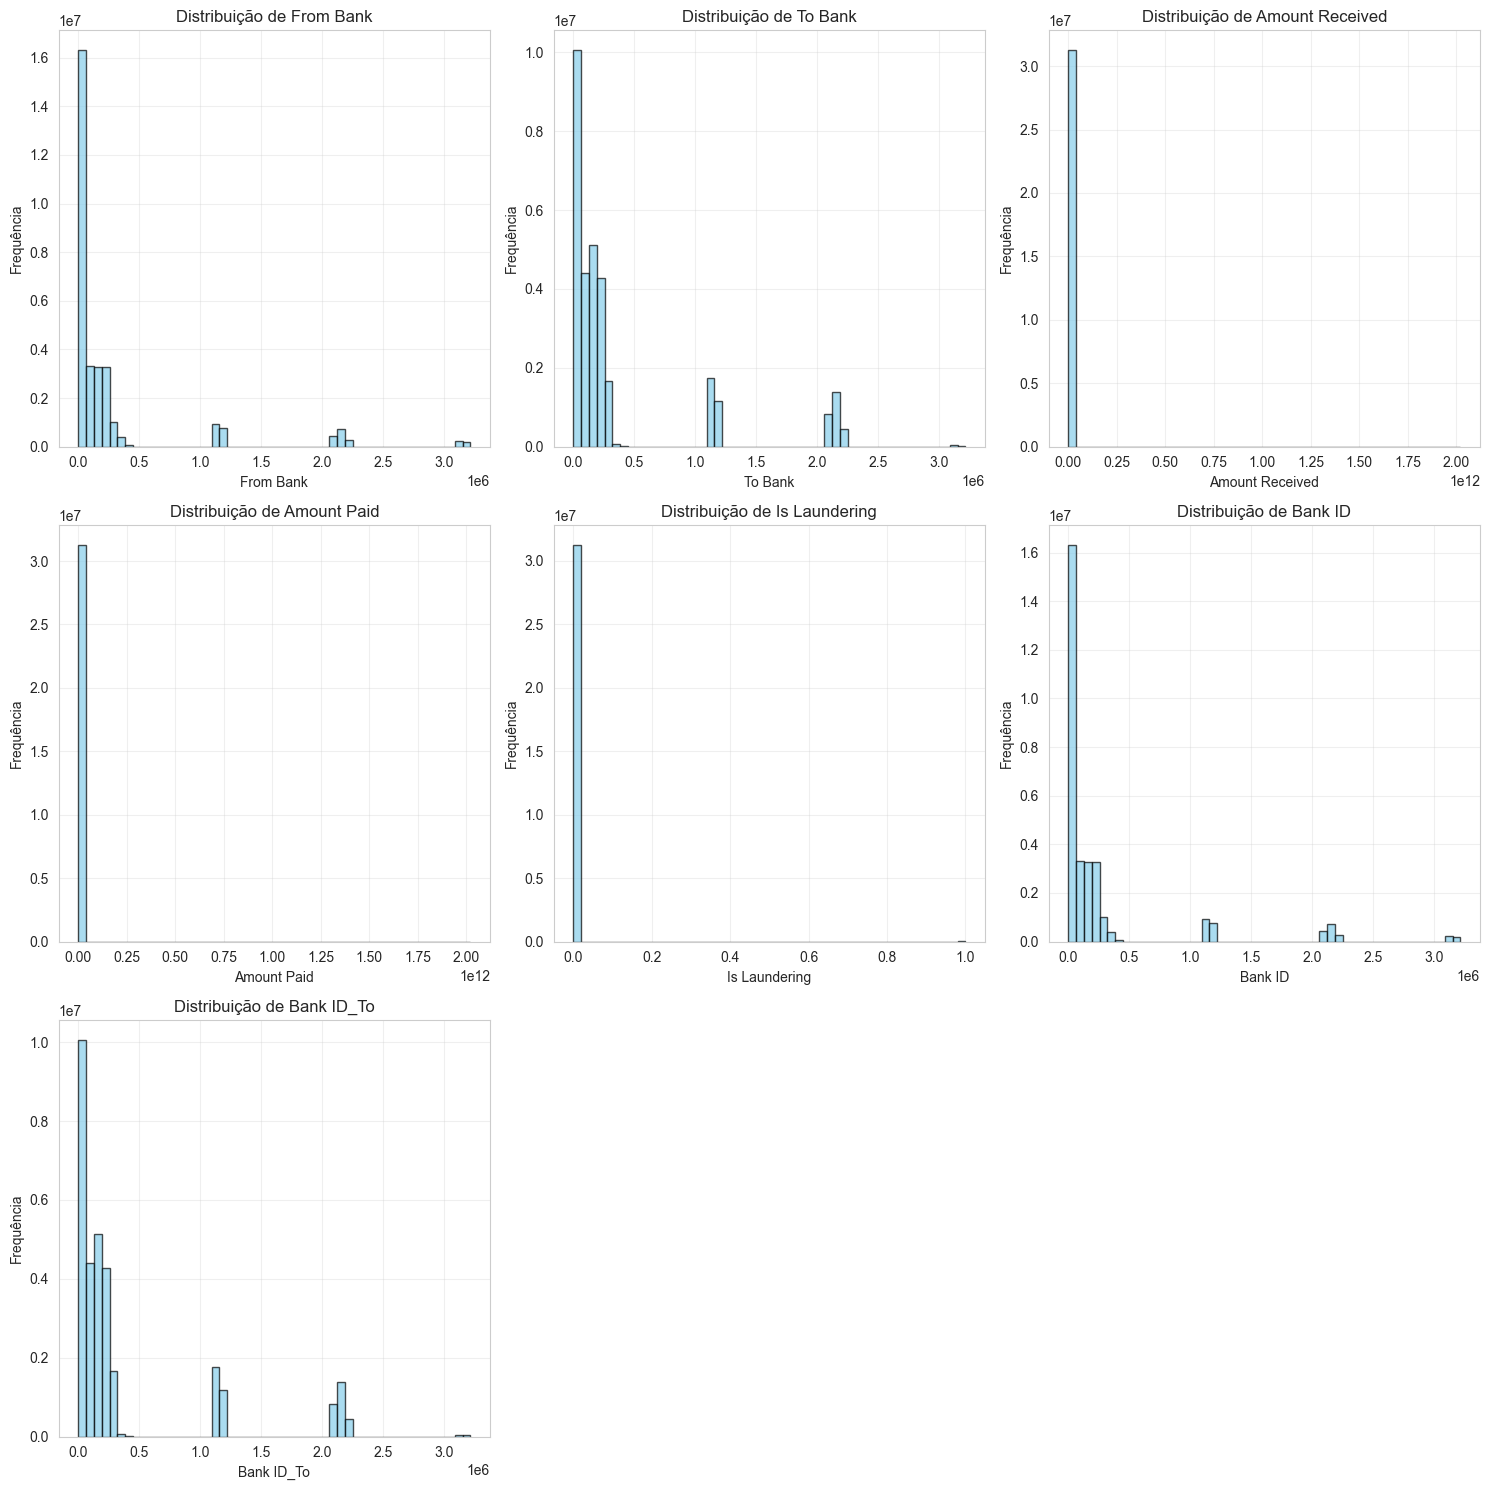

In [ ]:
# Distribuição das variáveis numéricas
if len(numeric_cols) > 0:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        axes[idx].hist(df[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribuição de {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(True, alpha=0.3)
    
    # Remover eixos extras
    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

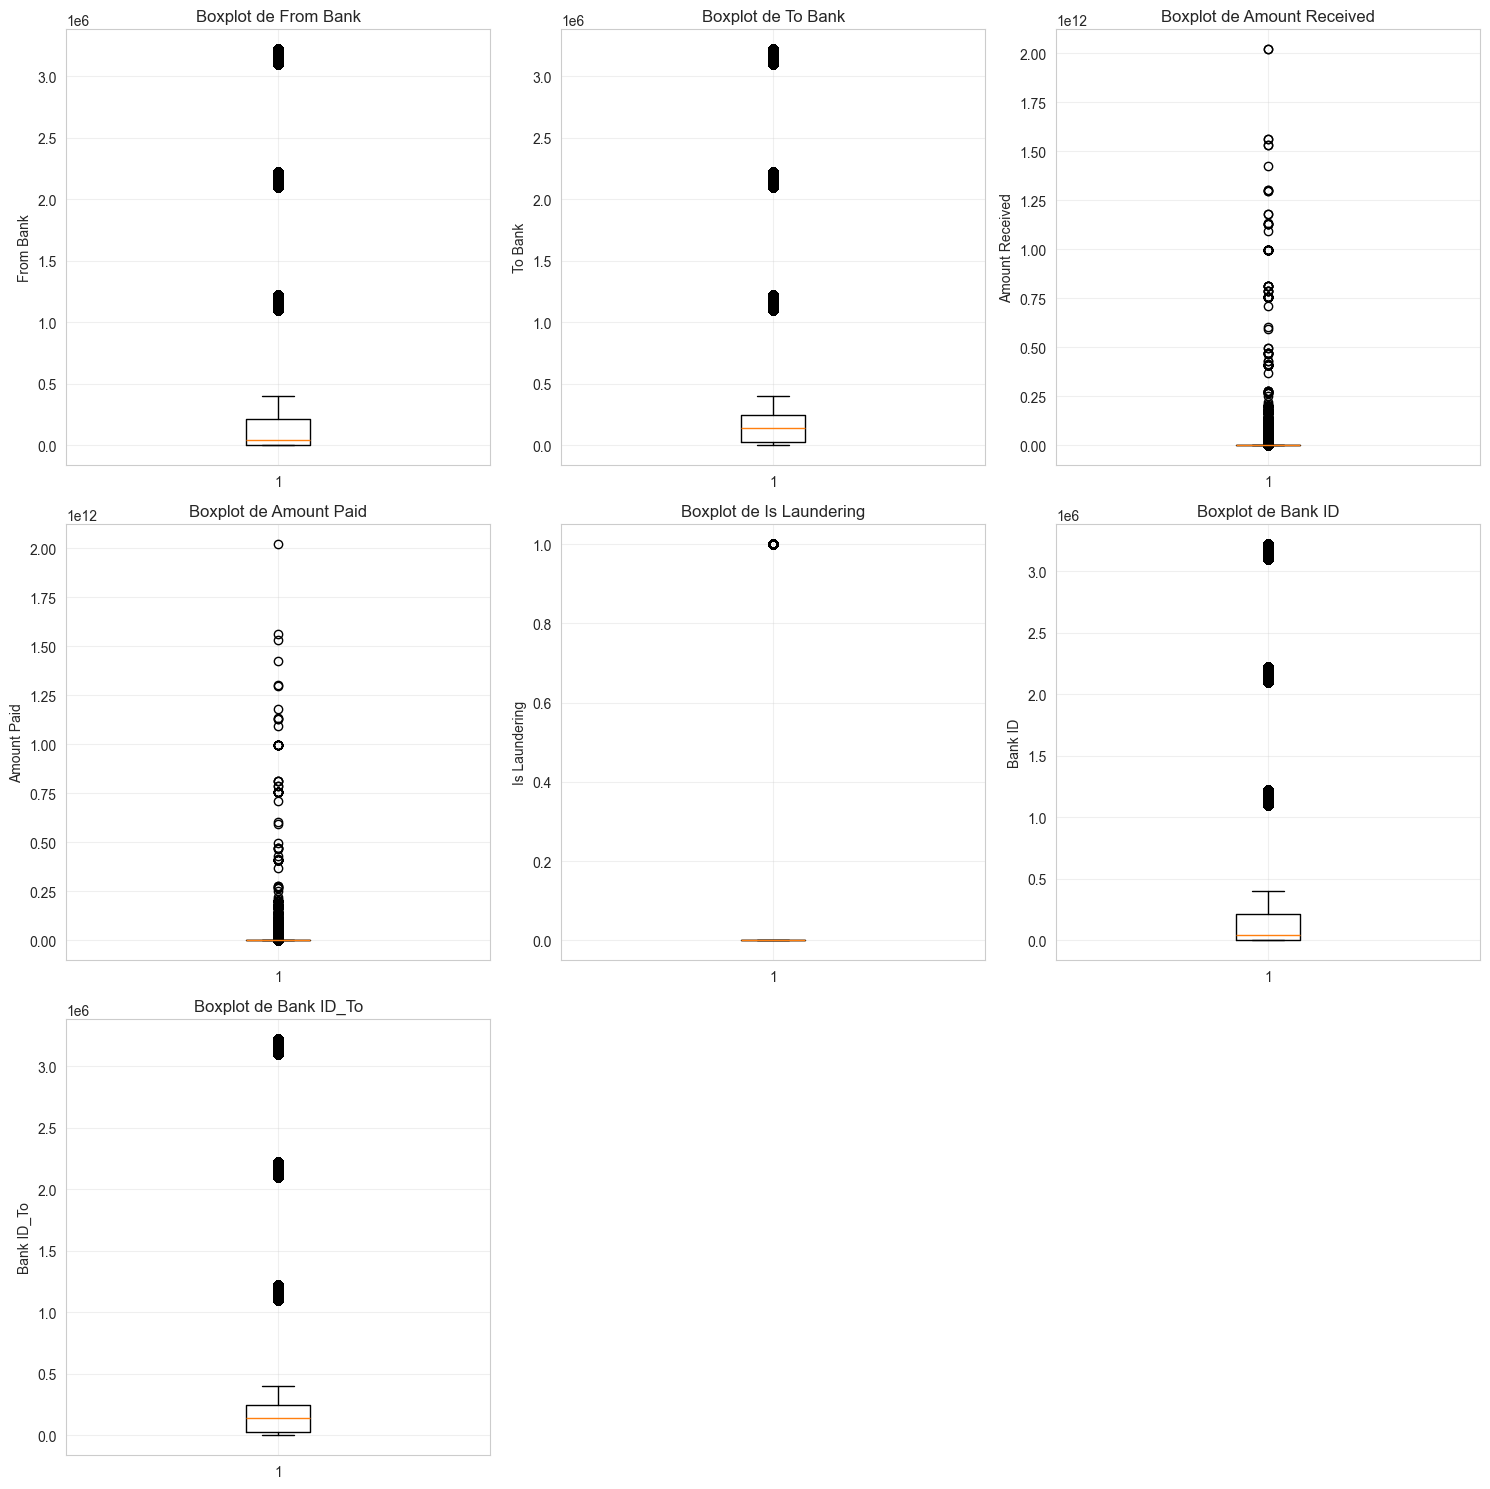

In [ ]:
# Boxplots para visualização de outliers
if len(numeric_cols) > 0:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'Boxplot de {col}')
        axes[idx].set_ylabel(col)
        axes[idx].grid(True, alpha=0.3)
    
    # Remover eixos extras
    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

## 8. Detecção de Outliers (Método IQR)

In [ ]:
# Detecção de outliers usando IQR (Interquartile Range)
print("=" * 80)
print("ANÁLISE DE OUTLIERS - MÉTODO IQR")
print("=" * 80)

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = round(n_outliers / len(df) * 100, 2)
    
    outlier_summary.append({
        'Variável': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite_Inferior': lower_bound,
        'Limite_Superior': upper_bound,
        'N_Outliers': n_outliers,
        'Percentual': pct_outliers
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

ANÁLISE DE OUTLIERS - MÉTODO IQR


,Variável,Q1,Q3,IQR,Limite_Inferior,Limite_Superior,N_Outliers,Percentual
0,From Bank,2597.00,211348.00,208751.00,-310529.500,524474.500,3548039,11.35
1,To Bank,28488.00,249308.00,220820.00,-302742.000,580538.000,5653596,18.09
2,Amount Received,204.55,11991.28,11786.73,-17475.545,29671.375,5375692,17.20
3,Amount Paid,205.91,11918.30,11712.39,-17362.675,29486.885,5361739,17.16
4,Is Laundering,0.00,0.00,0.00,0.000,0.000,16041,0.05
5,Bank ID,2597.00,211348.00,208751.00,-310529.500,524474.500,3548039,11.35
6,Bank ID_To,28488.00,249308.00,220820.00,-302742.000,580538.000,5653596,18.09


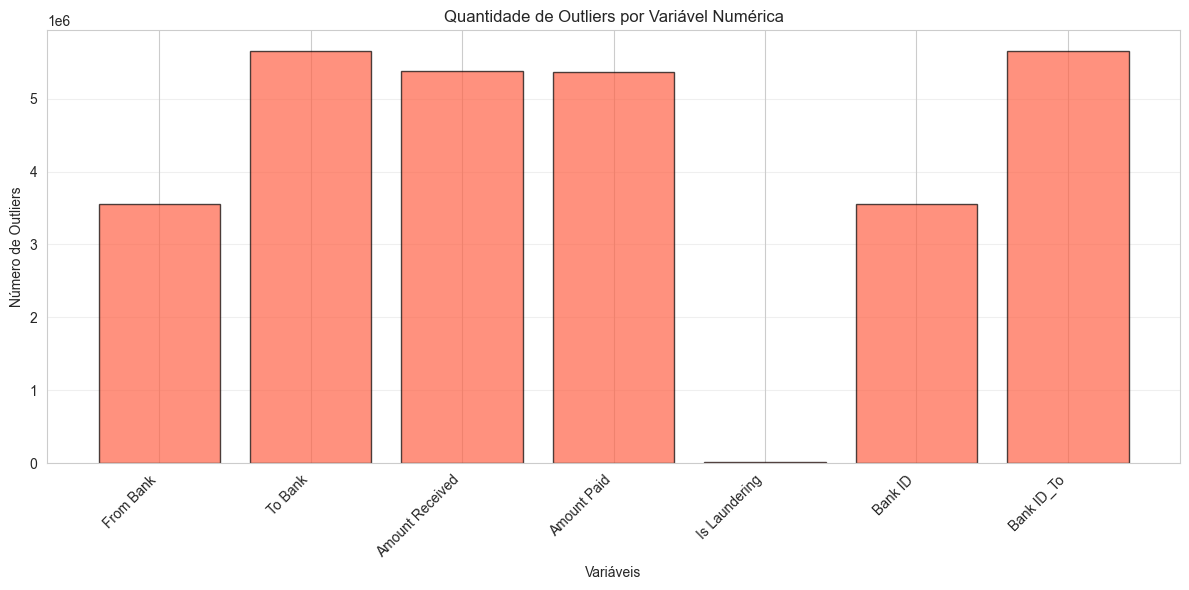

In [ ]:
# Visualização da quantidade de outliers
if len(outlier_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.bar(outlier_df['Variável'], outlier_df['N_Outliers'], color='tomato', alpha=0.7, edgecolor='black')
    plt.xlabel('Variáveis')
    plt.ylabel('Número de Outliers')
    plt.title('Quantidade de Outliers por Variável Numérica')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## 9. Matriz de Correlação

MATRIZ DE CORRELAÇÃO


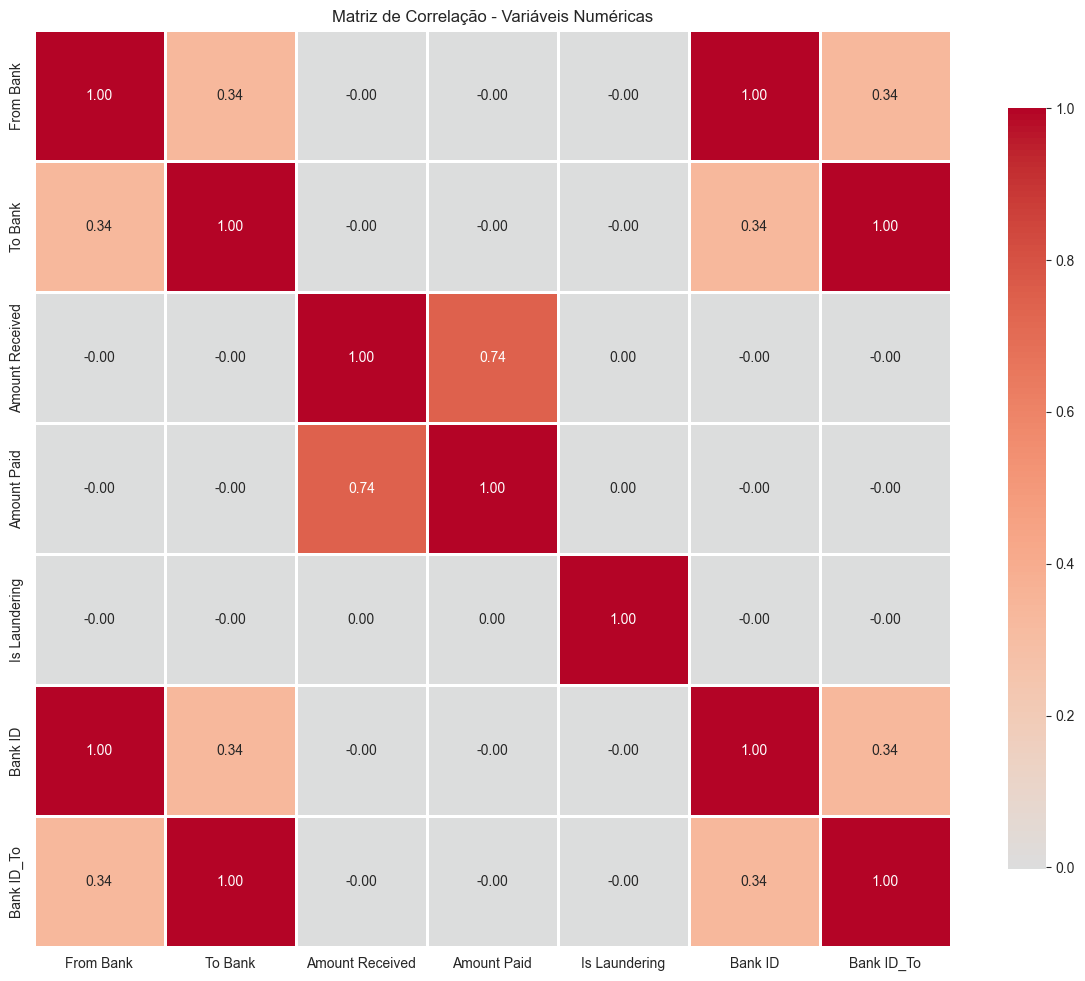


🔍 Correlações Fortes (|r| > 0.7):


,Var1,Var2,Correlação
0,From Bank,Bank ID,1.000
1,To Bank,Bank ID_To,1.000
2,Amount Received,Amount Paid,0.743


In [ ]:
# Matriz de correlação
if len(numeric_cols) > 1:
    print("=" * 80)
    print("MATRIZ DE CORRELAÇÃO")
    print("=" * 80)
    
    correlation_matrix = df[numeric_cols].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlação - Variáveis Numéricas')
    plt.tight_layout()
    plt.show()
    
    # Correlações fortes (> 0.7 ou < -0.7)
    print("\n🔍 Correlações Fortes (|r| > 0.7):")
    strong_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                strong_corr.append({
                    'Var1': correlation_matrix.columns[i],
                    'Var2': correlation_matrix.columns[j],
                    'Correlação': correlation_matrix.iloc[i, j].round(3)
                })
    
    if strong_corr:
        display(pd.DataFrame(strong_corr))
    else:
        print("  Não foram encontradas correlações fortes entre as variáveis.")

## 10. Análise de Variáveis Categóricas

In [ ]:
# Análise de variáveis categóricas
if len(categorical_cols) > 0:
    print("=" * 80)
    print("ANÁLISE DE VARIÁVEIS CATEGÓRICAS")
    print("=" * 80)
    
    for col in categorical_cols:
        print(f"\n{'='*80}")
        print(f"Variável: {col}")
        print(f"{'='*80}")
        
        value_counts = df[col].value_counts()
        value_percentages = df[col].value_counts(normalize=True) * 100
        
        summary = pd.DataFrame({
            'Contagem': value_counts,
            'Percentual': value_percentages.round(2)
        })
        
        print(f"\nNúmero de categorias únicas: {df[col].nunique()}")
        print(f"\nDistribuição:")
        display(summary.head(20))  # Mostrar top 20 categorias

ANÁLISE DE VARIÁVEIS CATEGÓRICAS

Variável: Timestamp

Número de categorias únicas: 23761

Distribuição:


,Contagem,Percentual
Timestamp,,
2022/09/01 00:04,43194,0.14
2022/09/01 00:08,43062,0.14
2022/09/01 00:29,43020,0.14
2022/09/01 00:16,43018,0.14
2022/09/01 00:03,42982,0.14
2022/09/01 00:21,42978,0.14
2022/09/01 00:00,42955,0.14
2022/09/01 00:26,42948,0.14
2022/09/01 00:02,42945,0.14



Variável: From Account

Número de categorias únicas: 1969950

Distribuição:


,Contagem,Percentual
From Account,,
10042B660,1092870,3.50
10042B6A8,665519,2.13
10042B6F0,152825,0.49
10042B780,115258,0.37
10042B858,94249,0.30
10042B978,93430,0.30
10042B8A0,92949,0.30
10042B810,87671,0.28
10042B738,83710,0.27



Variável: To Account

Número de categorias únicas: 1653152

Distribuição:


...

,Contagem,Percentual
Account Number_To,,
10042B660,6811,0.02
10042B6A8,4346,0.01
10042B6F0,954,0.00
10042B780,692,0.00
10042B858,627,0.00
10042B810,571,0.00
10042B738,558,0.00
10042B978,542,0.00
10042B8A0,536,0.00



Variável: To Entity ID

Número de categorias únicas: 650488

Distribuição:


,Contagem,Percentual
To Entity ID,,
2AA2385E860,131636,0.42
2AA204036A0,122729,0.39
2AA21D683C0,60787,0.19
2AA20D14DE0,59255,0.19
2AA2354E9F0,57529,0.18
2AA21128590,52849,0.17
2AA23078BD0,44392,0.14
2AA23220660,33432,0.11
2AA234462B0,27747,0.09



Variável: To Entity Name

Número de categorias únicas: 650488

Distribuição:


,Contagem,Percentual
To Entity Name,,
Direct #1,131636,0.42
Sole Proprietorship #142810,122729,0.39
Corporation #137061,60787,0.19
Sole Proprietorship #142809,59255,0.19
Corporation #136151,57529,0.18
Sole Proprietorship #142813,52849,0.17
Corporation #128549,44392,0.14
Partnership #136131,33432,0.11
Partnership #140251,27747,0.09


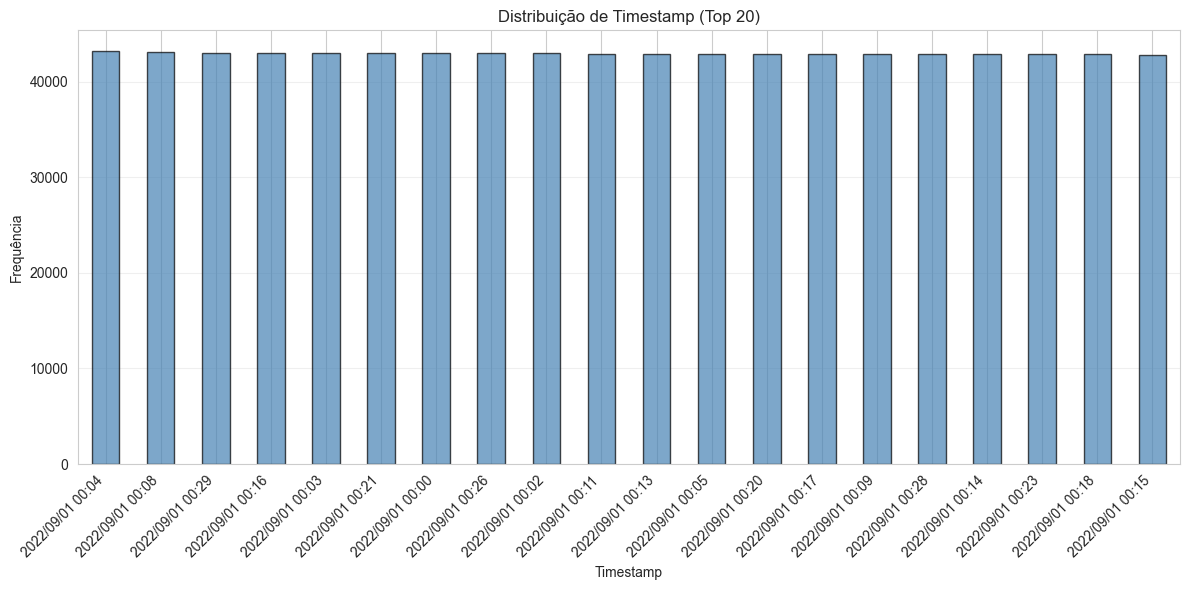

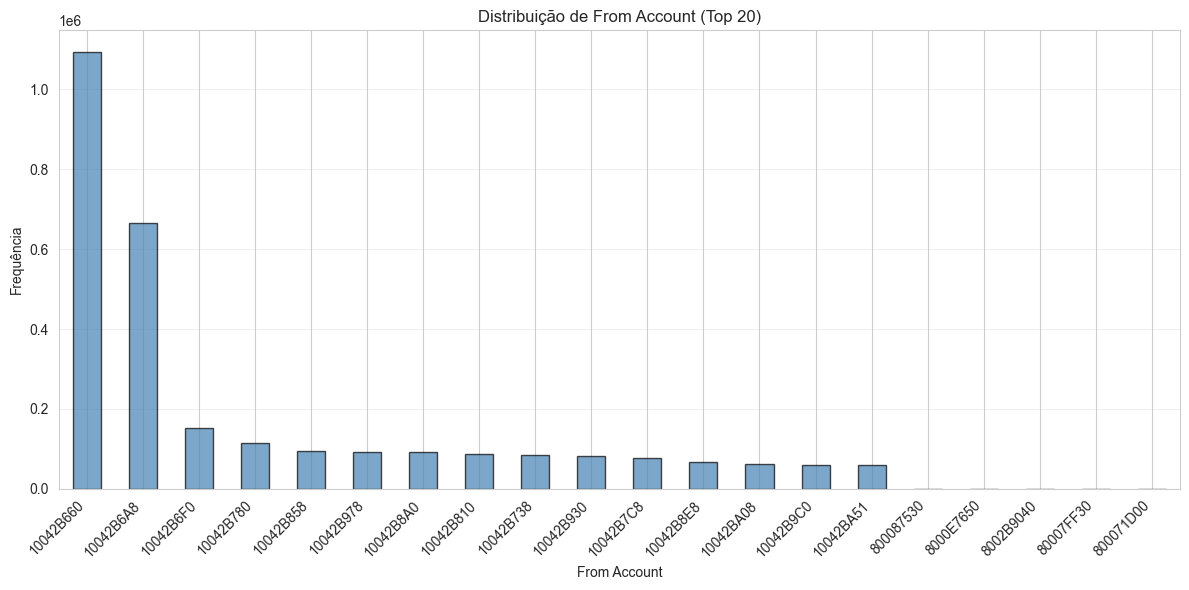

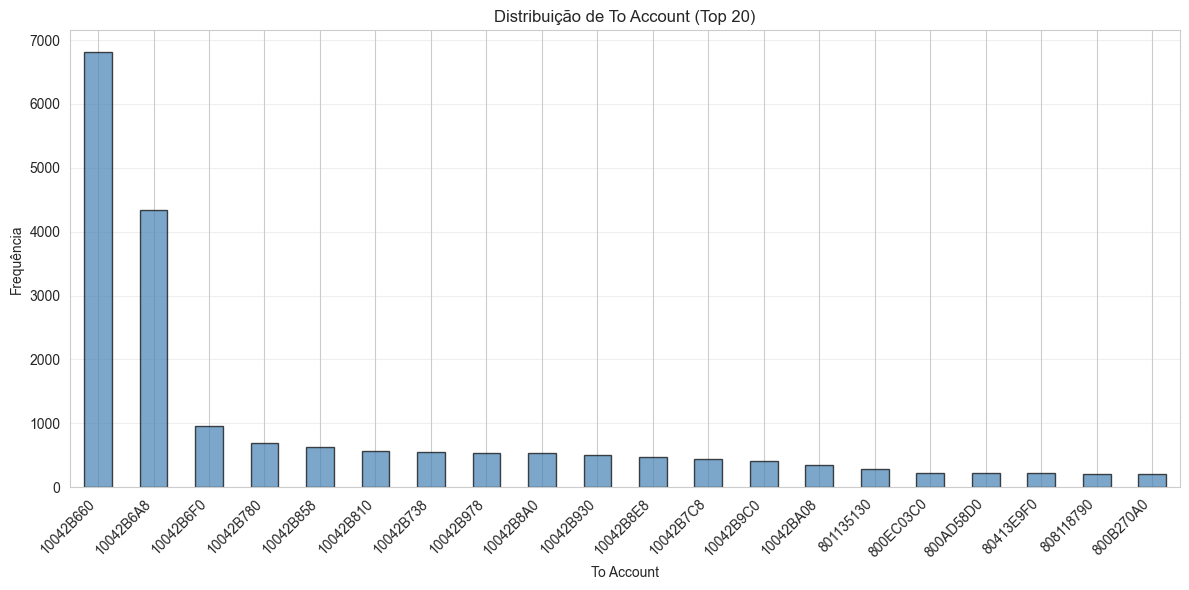

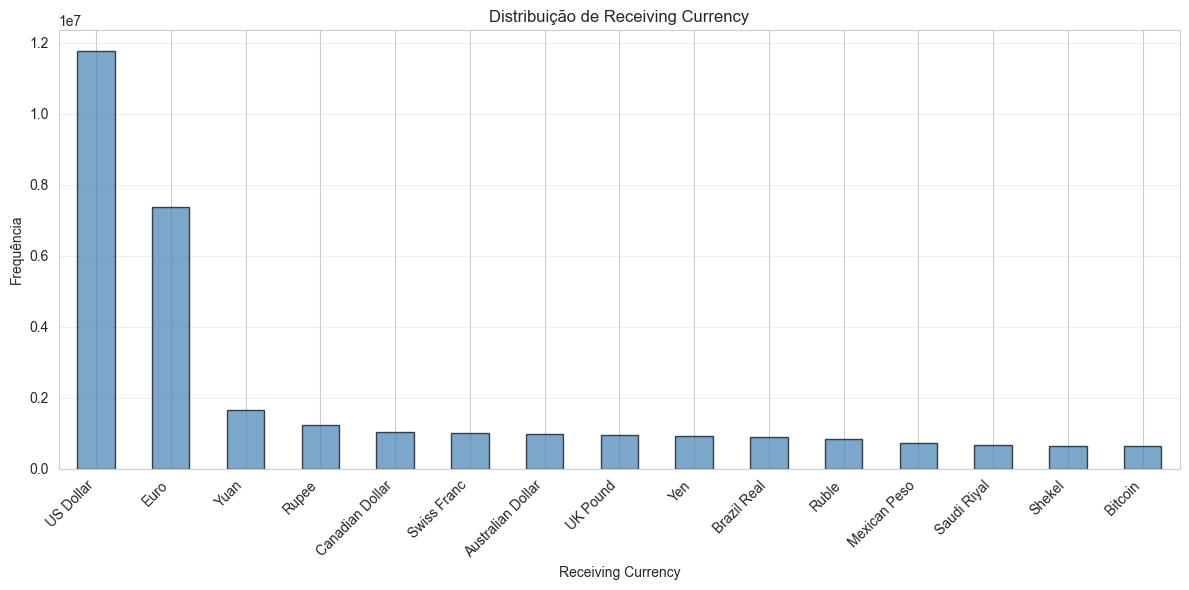

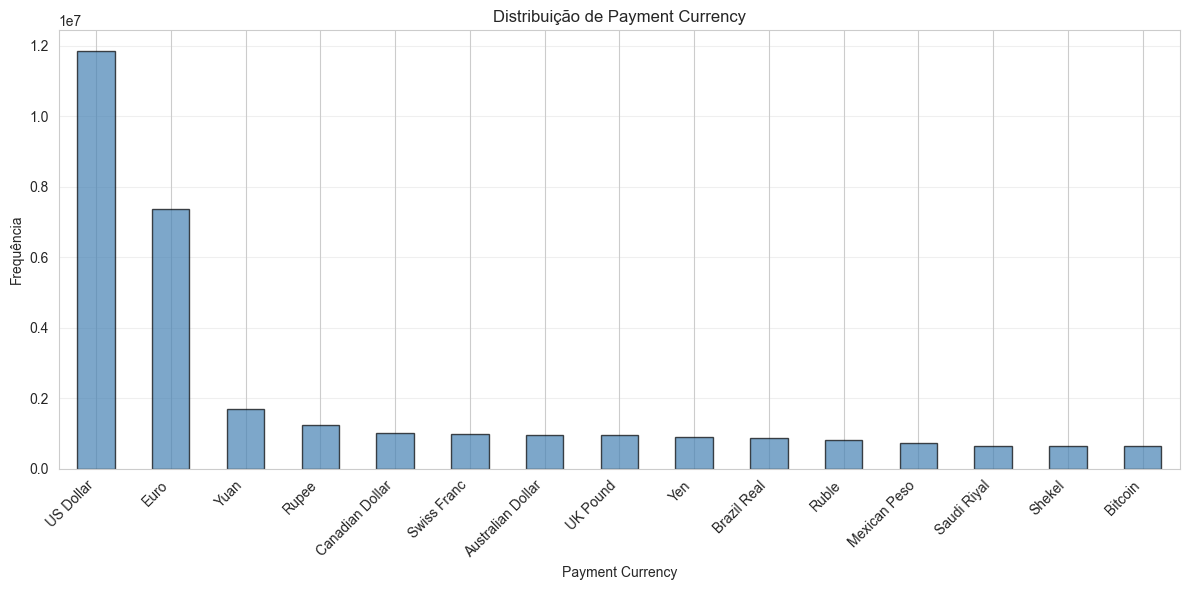

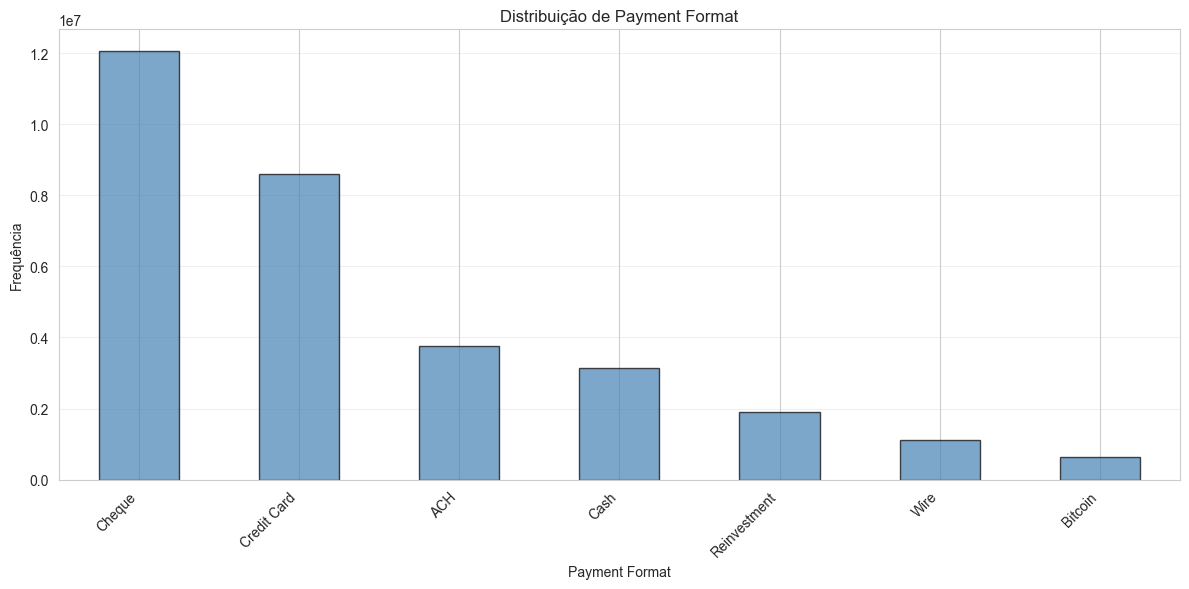

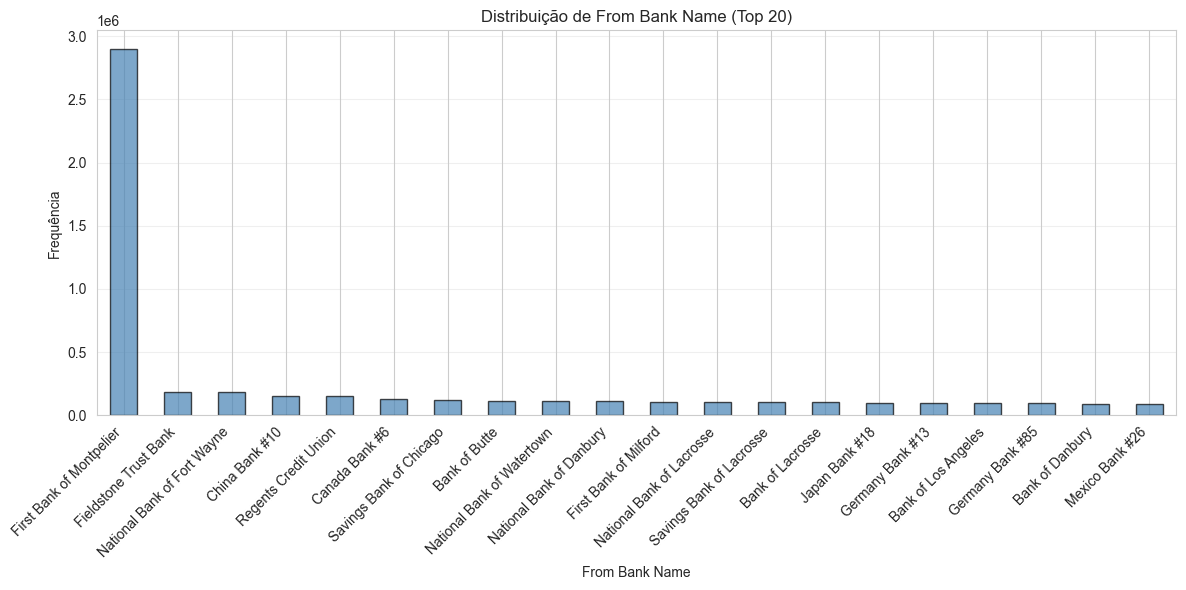

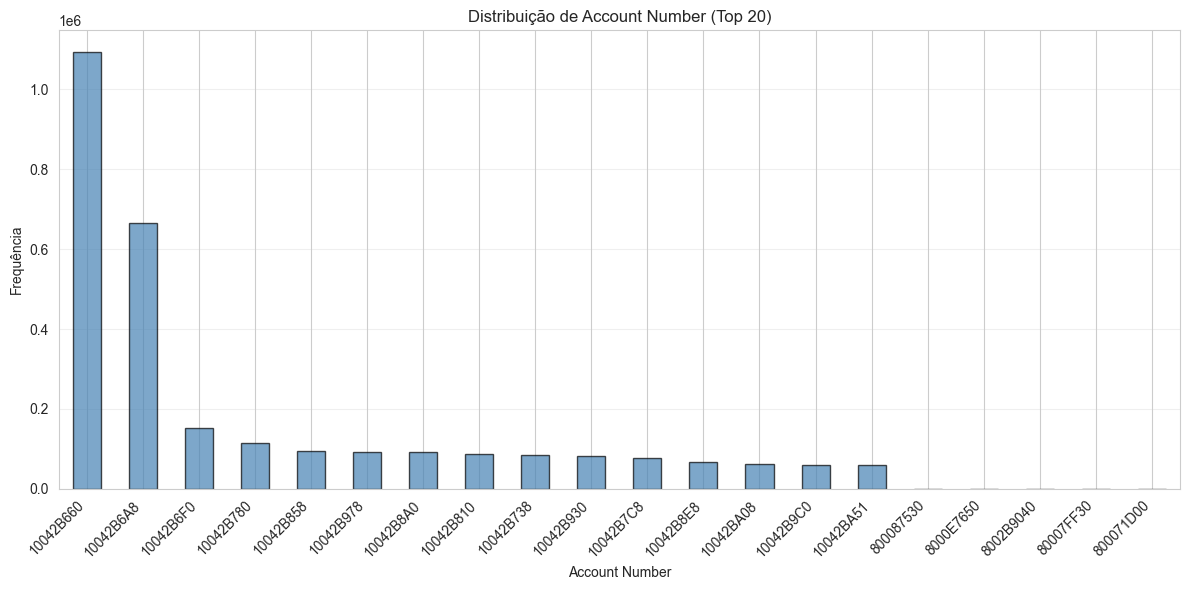

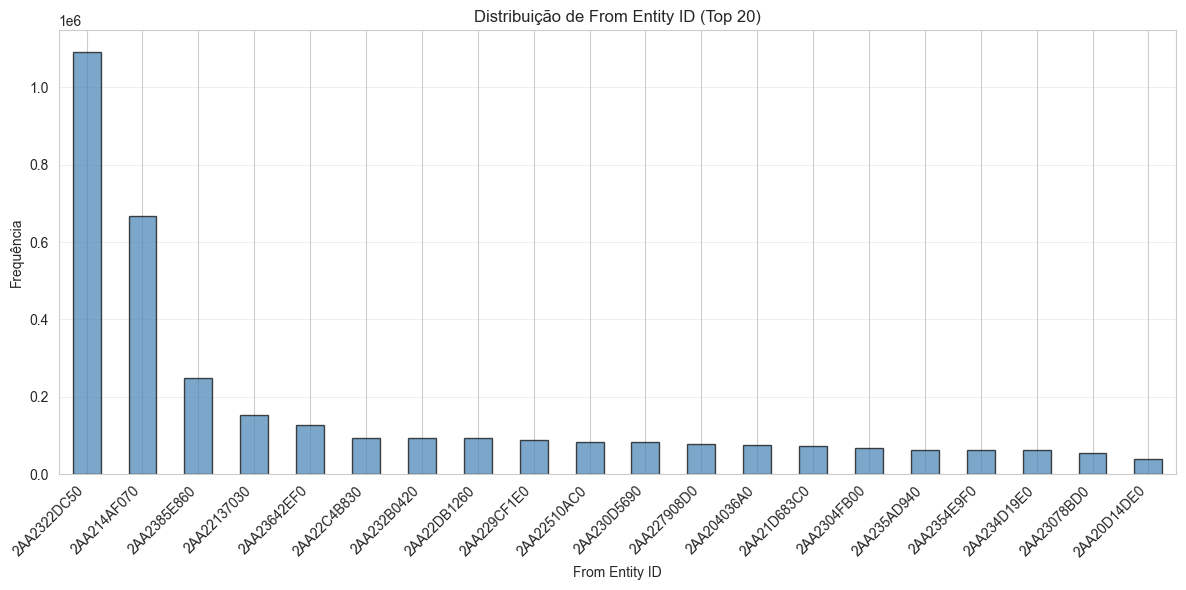

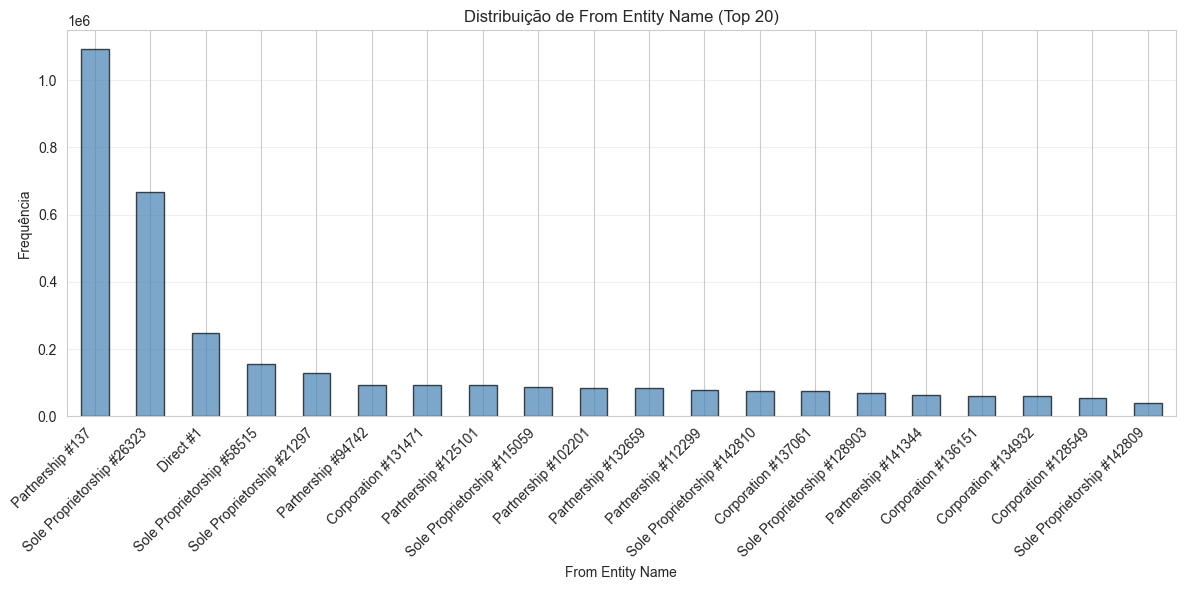

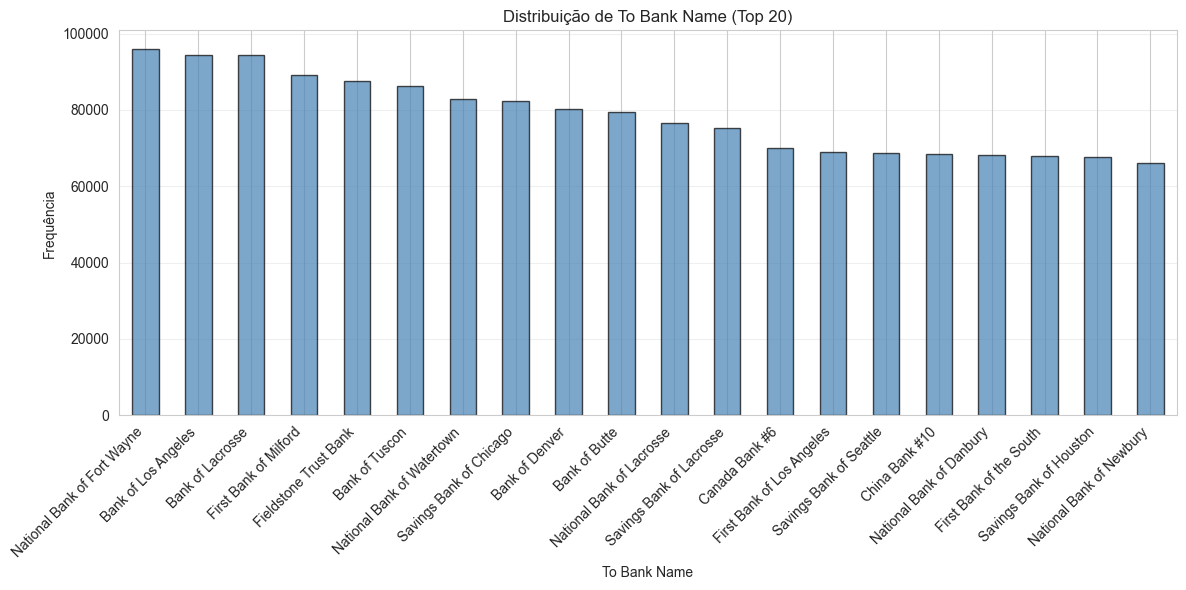

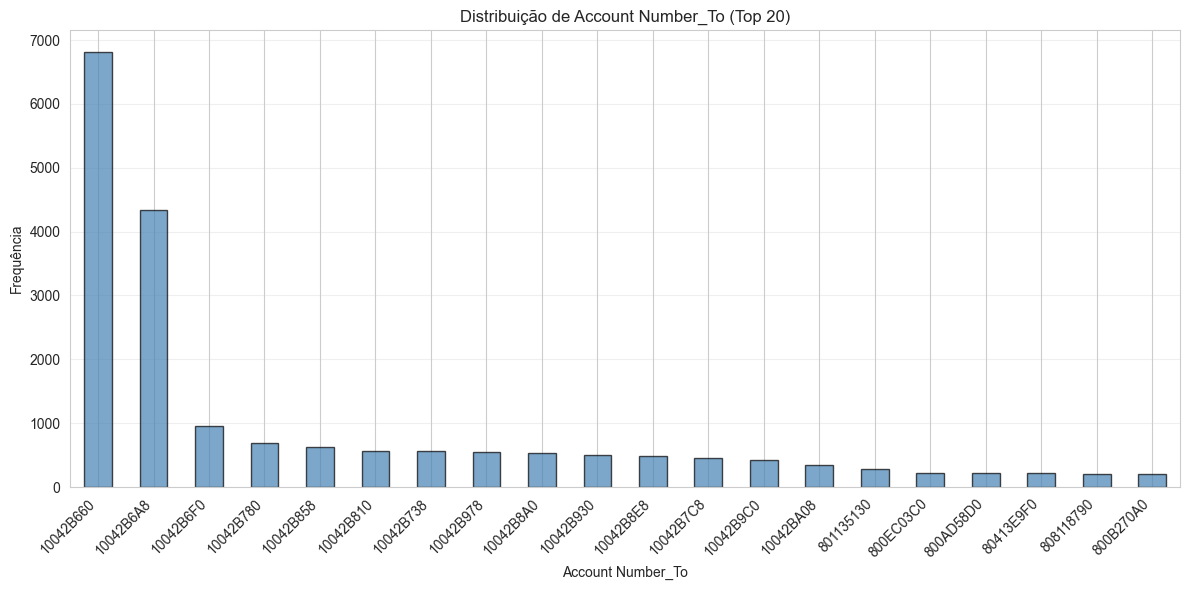

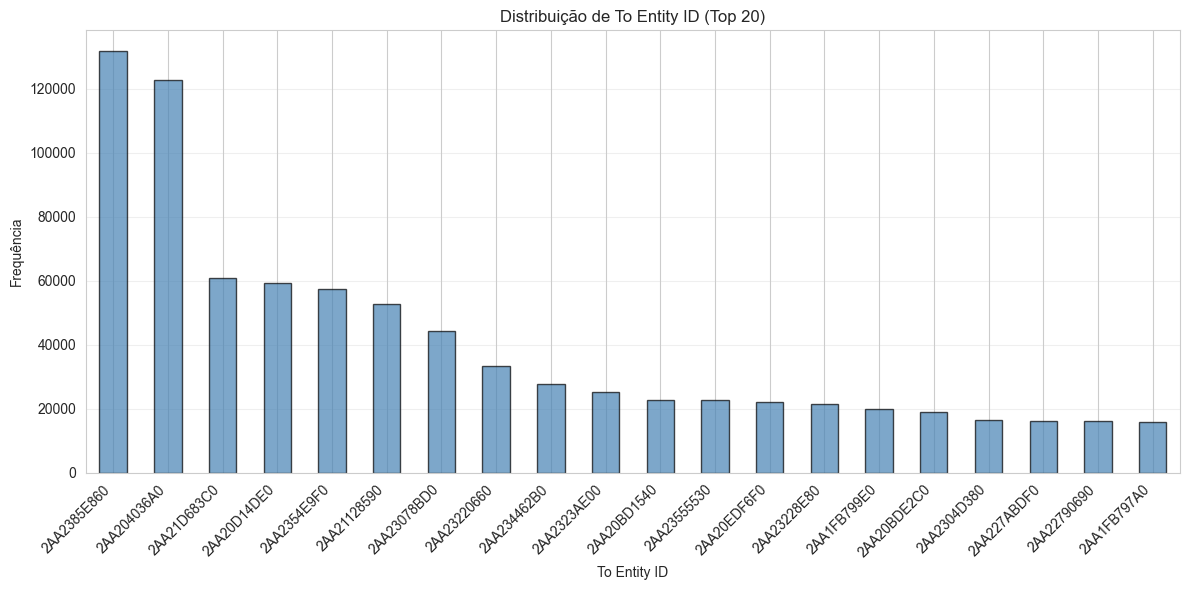

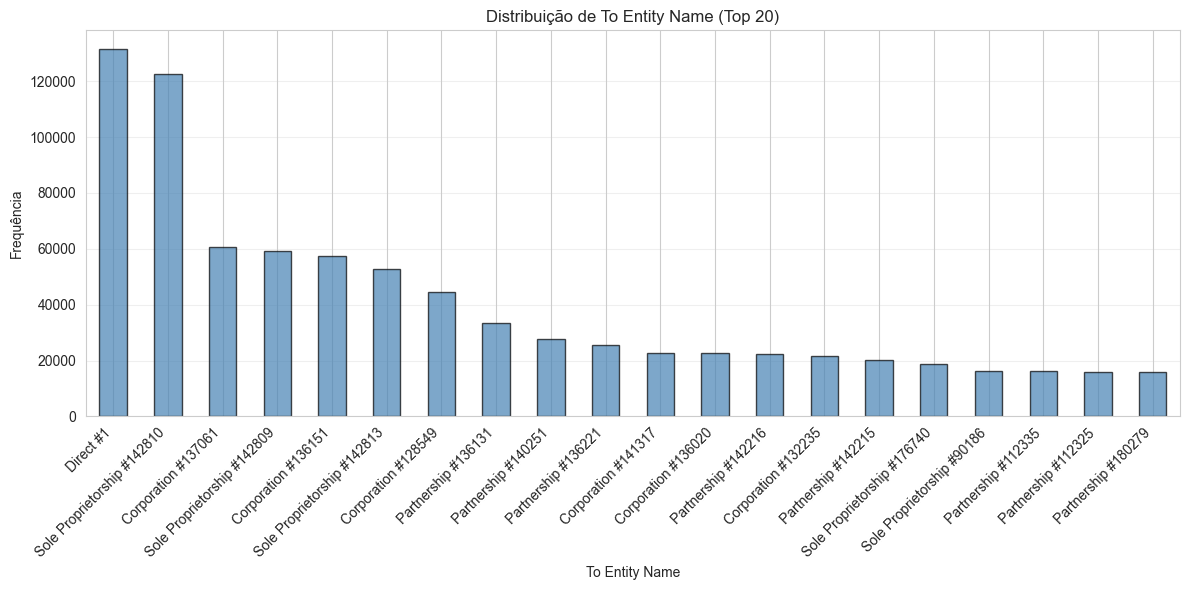

In [ ]:
# Gráficos de barras para variáveis categóricas
if len(categorical_cols) > 0:
    for col in categorical_cols:
        value_counts = df[col].value_counts()
        
        # Limitar a 20 categorias mais frequentes
        if len(value_counts) > 20:
            value_counts = value_counts.head(20)
            title_suffix = " (Top 20)"
        else:
            title_suffix = ""
        
        plt.figure(figsize=(12, 6))
        value_counts.plot(kind='bar', color='steelblue', alpha=0.7, edgecolor='black')
        plt.title(f'Distribuição de {col}{title_suffix}')
        plt.xlabel(col)
        plt.ylabel('Frequência')
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

## 10.5. Análise de Relação: From Bank vs To Bank

## 11. Resumo da Análise Exploratória

In [ ]:
# Resumo final da análise
print("=" * 80)
print("RESUMO DA ANÁLISE EXPLORATÓRIA")
print("=" * 80)

summary_stats = {
    'Total de Registros': f"{len(df):,}",
    'Total de Colunas': df.shape[1],
    'Variáveis Numéricas': len(numeric_cols),
    'Variáveis Categóricas': len(categorical_cols),
    'Registros Duplicados': f"{df.duplicated().sum():,} ({(df.duplicated().sum()/len(df)*100):.2f}%)",
    'Valores Ausentes': f"{df.isnull().sum().sum():,} ({(df.isnull().sum().sum()/(len(df)*df.shape[1])*100):.2f}%)",
    'Memória Utilizada': f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
}

for key, value in summary_stats.items():
    print(f"{key}: {value}")

print("\n" + "=" * 80)
print("ANÁLISE CONCLUÍDA!")
print("=" * 80)

RESUMO DA ANÁLISE EXPLORATÓRIA
Total de Registros: 31,251,483
Total de Colunas: 21
Variáveis Numéricas: 7
Variáveis Categóricas: 14
Registros Duplicados: 14 (0.00%)
Valores Ausentes: 0 (0.00%)
Memória Utilizada: 30659.31 MB

ANÁLISE CONCLUÍDA!


In [ ]:
# Análise da relação entre From Bank e To Bank
print("=" * 80)
print("ANÁLISE: FROM BANK vs TO BANK")
print("=" * 80)

# Criar coluna indicadora: mesma instituição ou instituições diferentes
df['Same_Bank'] = df['From Bank'] == df['To Bank']

# Contar transações
same_bank_count = df['Same_Bank'].sum()
diff_bank_count = (~df['Same_Bank']).sum()
total_trans = len(df)

print(f"\n📊 DISTRIBUIÇÃO DE TRANSAÇÕES:")
print(f"{'─' * 80}")
print(f"Transações no MESMO banco:     {same_bank_count:>15,} ({same_bank_count/total_trans*100:>6.2f}%)")
print(f"Transações entre bancos DIFERENTES: {diff_bank_count:>10,} ({diff_bank_count/total_trans*100:>6.2f}%)")
print(f"Total de transações:           {total_trans:>15,} (100.00%)")

# Estatísticas por tipo de transação
print(f"\n\n💰 ANÁLISE DE VALORES POR TIPO DE TRANSAÇÃO:")
print(f"{'─' * 80}")

same_bank_stats = df[df['Same_Bank']==True]['Amount Received'].describe()
diff_bank_stats = df[df['Same_Bank']==False]['Amount Received'].describe()

comparison = pd.DataFrame({
    'Mesmo Banco': same_bank_stats,
    'Bancos Diferentes': diff_bank_stats
})

display(comparison.T)

ANÁLISE: FROM BANK vs TO BANK

📊 DISTRIBUIÇÃO DE TRANSAÇÕES:
────────────────────────────────────────────────────────────────────────────────
Transações no MESMO banco:           2,727,212 (  8.73%)
Transações entre bancos DIFERENTES: 28,524,271 ( 91.27%)
Total de transações:                31,251,483 (100.00%)


💰 ANÁLISE DE VALORES POR TIPO DE TRANSAÇÃO:
────────────────────────────────────────────────────────────────────────────────


,count,mean,std,min,25%,50%,75%,max
Mesmo Banco,2727212.0,3.194829e+07,4.048707e+09,0.000001,22.53,1481.48,32874.105,2.020628e+12
Bancos Diferentes,28524271.0,5.659257e+06,1.358425e+09,0.000001,222.13,1450.33,11106.740,2.020628e+12


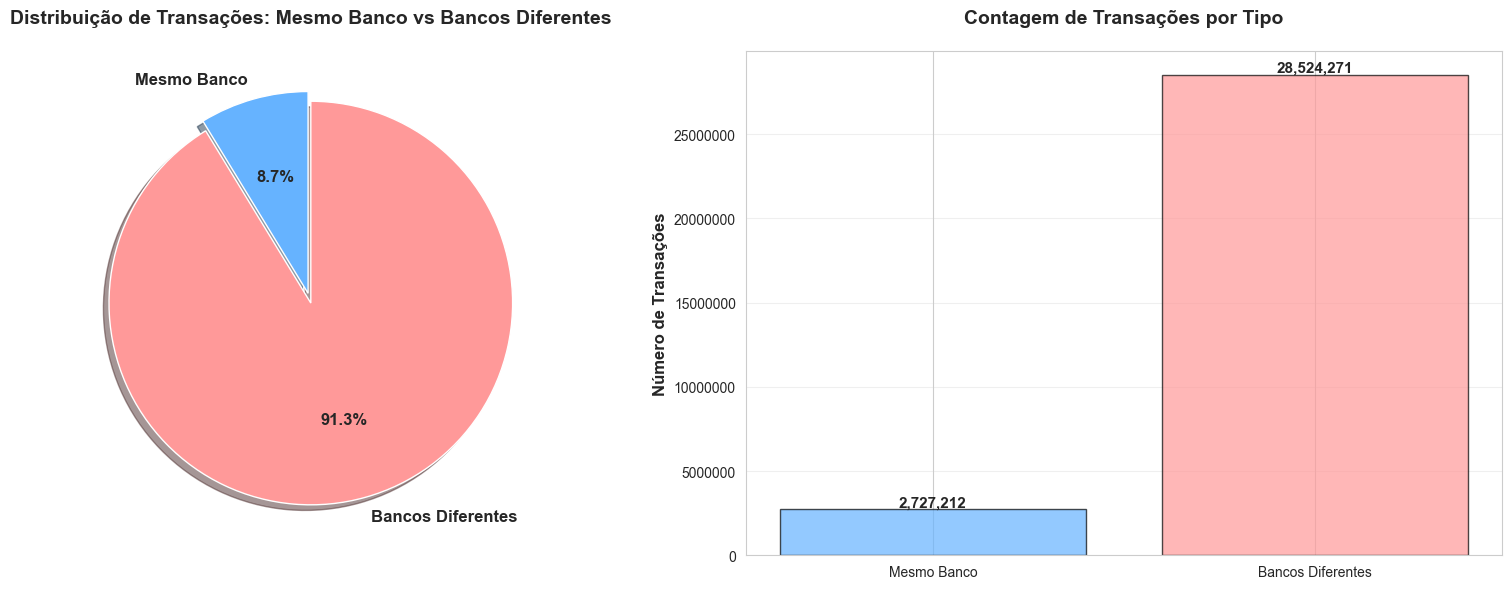

In [ ]:
# Visualização: Pizza da distribuição
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Pizza
labels = ['Mesmo Banco', 'Bancos Diferentes']
sizes = [same_bank_count, diff_bank_count]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Distribuição de Transações: Mesmo Banco vs Bancos Diferentes', 
                  fontsize=14, weight='bold', pad=20)

# Gráfico de Barras
axes[1].bar(labels, sizes, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Número de Transações', fontsize=12, weight='bold')
axes[1].set_title('Contagem de Transações por Tipo', fontsize=14, weight='bold', pad=20)
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, (label, size) in enumerate(zip(labels, sizes)):
    axes[1].text(i, size, f'{size:,}', ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

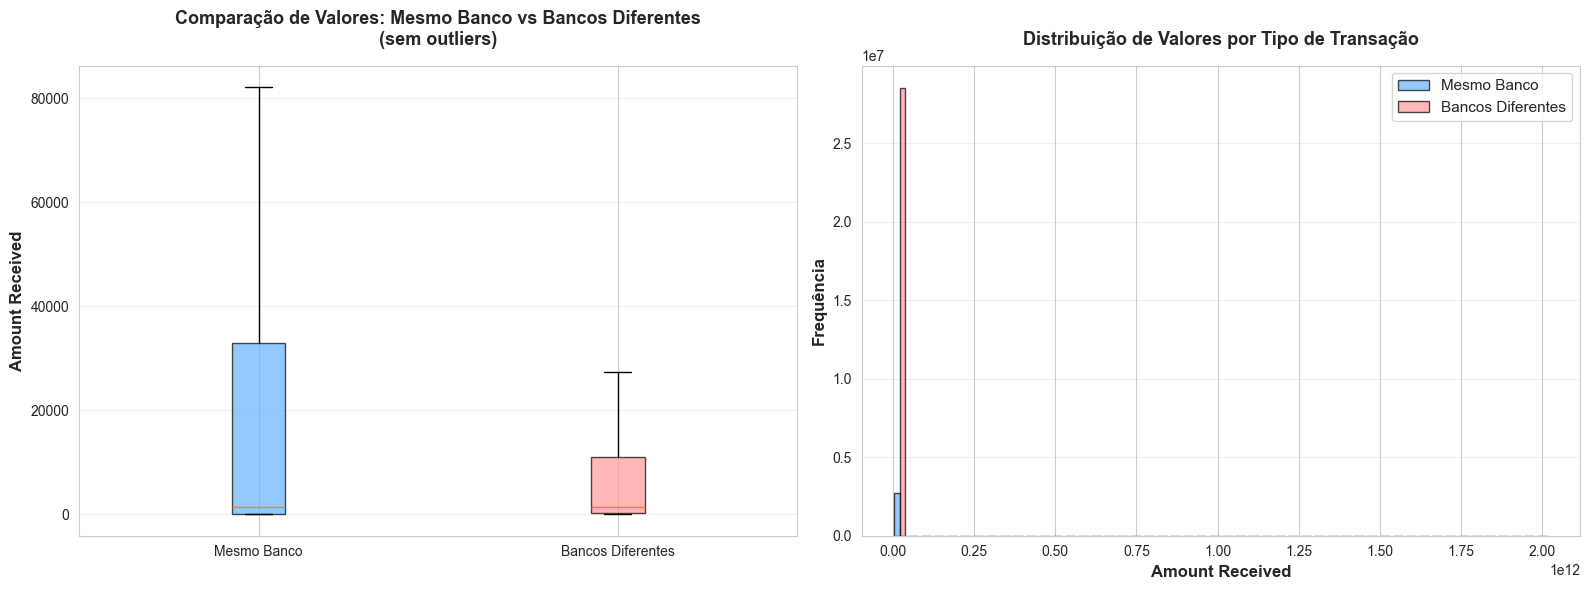

In [ ]:
# Comparação de valores entre tipos de transações
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot comparativo
data_to_plot = [df[df['Same_Bank']==True]['Amount Received'].dropna(), 
                df[df['Same_Bank']==False]['Amount Received'].dropna()]

bp = axes[0].boxplot(data_to_plot, labels=['Mesmo Banco', 'Bancos Diferentes'],
                     patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ['#66b3ff', '#ff9999']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel('Amount Received', fontsize=12, weight='bold')
axes[0].set_title('Comparação de Valores: Mesmo Banco vs Bancos Diferentes\n(sem outliers)', 
                  fontsize=13, weight='bold', pad=15)
axes[0].grid(True, alpha=0.3, axis='y')

# Histograma comparativo
axes[1].hist([df[df['Same_Bank']==True]['Amount Received'].dropna(),
              df[df['Same_Bank']==False]['Amount Received'].dropna()],
             bins=50, label=['Mesmo Banco', 'Bancos Diferentes'],
             color=['#66b3ff', '#ff9999'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Amount Received', fontsize=12, weight='bold')
axes[1].set_ylabel('Frequência', fontsize=12, weight='bold')
axes[1].set_title('Distribuição de Valores por Tipo de Transação', 
                  fontsize=13, weight='bold', pad=15)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


🔍 ANÁLISE DE LAVAGEM DE DINHEIRO (Is Laundering)


,Tipo,Total_Transações,Lavagem_Sim,Lavagem_Não,Taxa_Lavagem_%
0,Mesmo Banco,2727212,111,2727101,0.00
1,Bancos Diferentes,28524271,15930,28508341,0.06


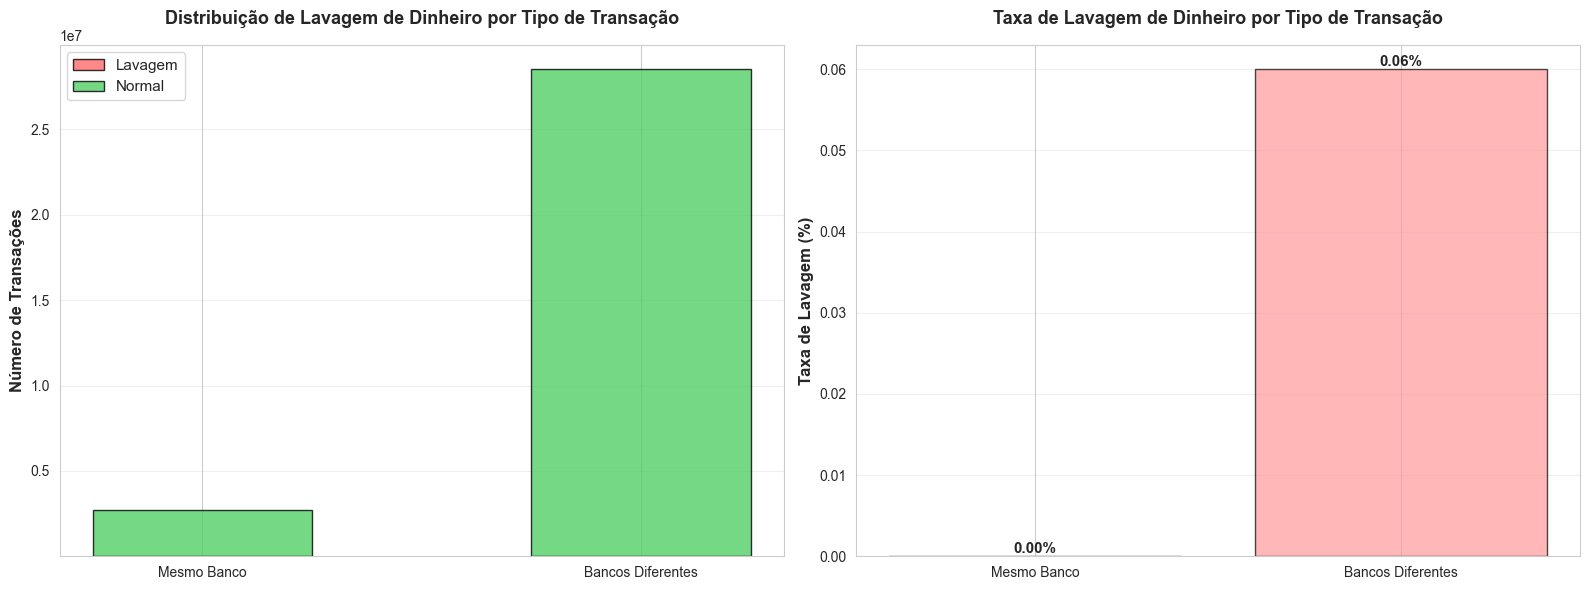

In [ ]:
# Análise de lavagem de dinheiro por tipo de transação
print("\n" + "=" * 80)
print("🔍 ANÁLISE DE LAVAGEM DE DINHEIRO (Is Laundering)")
print("=" * 80)

# Contagem de lavagem por tipo
laundering_analysis = pd.DataFrame({
    'Tipo': ['Mesmo Banco', 'Bancos Diferentes'],
    'Total_Transações': [same_bank_count, diff_bank_count],
    'Lavagem_Sim': [
        df[(df['Same_Bank']==True) & (df['Is Laundering']==1)].shape[0],
        df[(df['Same_Bank']==False) & (df['Is Laundering']==1)].shape[0]
    ]
})

laundering_analysis['Lavagem_Não'] = laundering_analysis['Total_Transações'] - laundering_analysis['Lavagem_Sim']
laundering_analysis['Taxa_Lavagem_%'] = (laundering_analysis['Lavagem_Sim'] / laundering_analysis['Total_Transações'] * 100).round(2)

display(laundering_analysis)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras empilhadas
x = np.arange(len(laundering_analysis))
width = 0.5

p1 = axes[0].bar(x, laundering_analysis['Lavagem_Sim'], width, 
                 label='Lavagem', color='#ff6b6b', edgecolor='black', alpha=0.8)
p2 = axes[0].bar(x, laundering_analysis['Lavagem_Não'], width,
                 bottom=laundering_analysis['Lavagem_Sim'],
                 label='Normal', color='#51cf66', edgecolor='black', alpha=0.8)

axes[0].set_ylabel('Número de Transações', fontsize=12, weight='bold')
axes[0].set_title('Distribuição de Lavagem de Dinheiro por Tipo de Transação', 
                  fontsize=13, weight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(laundering_analysis['Tipo'])
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# Taxa de lavagem
axes[1].bar(laundering_analysis['Tipo'], laundering_analysis['Taxa_Lavagem_%'],
            color=['#66b3ff', '#ff9999'], edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Taxa de Lavagem (%)', fontsize=12, weight='bold')
axes[1].set_title('Taxa de Lavagem de Dinheiro por Tipo de Transação', 
                  fontsize=13, weight='bold', pad=15)
axes[1].grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, (tipo, taxa) in enumerate(zip(laundering_analysis['Tipo'], laundering_analysis['Taxa_Lavagem_%'])):
    axes[1].text(i, taxa, f'{taxa:.2f}%', ha='center', va='bottom', 
                fontsize=11, weight='bold')

plt.tight_layout()
plt.show()


🏦 TOP 10 PARES DE BANCOS MAIS FREQUENTES

Pares de bancos (From → To) com maior número de transações:

 1. 112 → 112            :       13,555 transações (  0.04%)
 2. 12 → 12              :       13,105 transações (  0.04%)
 3. 0 → 0                :       11,705 transações (  0.04%)
 4. 27 → 27              :       11,181 transações (  0.04%)
 5. 11 → 11              :       10,819 transações (  0.03%)
 6. 20 → 20              :       10,448 transações (  0.03%)
 7. 15 → 15              :       10,175 transações (  0.03%)
 8. 114 → 114            :        9,890 transações (  0.03%)
 9. 70 → 27              :        7,190 transações (  0.02%)
10. 4 → 4                :        6,890 transações (  0.02%)


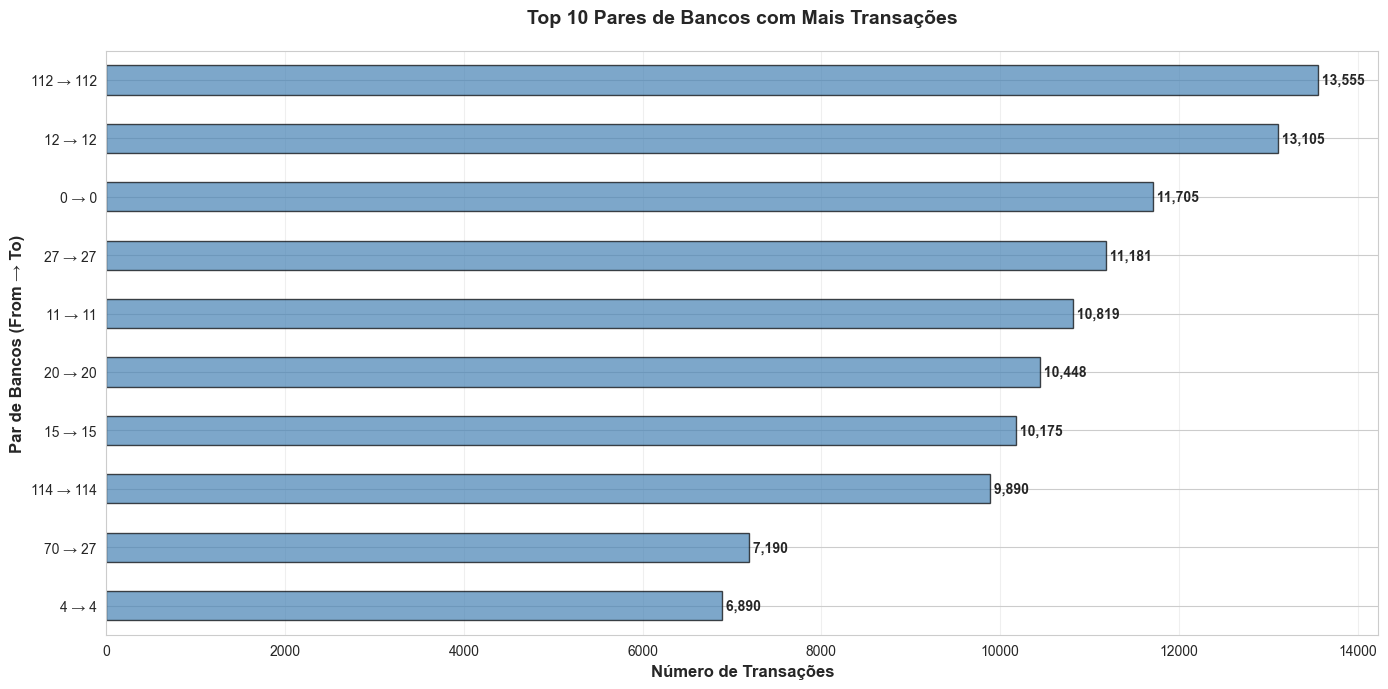

In [ ]:
# Exemplos específicos de pares de bancos mais frequentes
print("\n" + "=" * 80)
print("🏦 TOP 10 PARES DE BANCOS MAIS FREQUENTES")
print("=" * 80)

# Criar coluna com par de bancos
df['Bank_Pair'] = df.apply(lambda row: f"{int(row['From Bank'])} → {int(row['To Bank'])}", axis=1)

# Top 10 pares mais frequentes
top_pairs = df['Bank_Pair'].value_counts().head(10)

print("\nPares de bancos (From → To) com maior número de transações:\n")
for idx, (pair, count) in enumerate(top_pairs.items(), 1):
    percentage = (count / len(df) * 100)
    print(f"{idx:2d}. {pair:20s} : {count:>12,} transações ({percentage:>6.2f}%)")

# Visualização
plt.figure(figsize=(14, 7))
top_pairs.plot(kind='barh', color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Número de Transações', fontsize=12, weight='bold')
plt.ylabel('Par de Bancos (From → To)', fontsize=12, weight='bold')
plt.title('Top 10 Pares de Bancos com Mais Transações', fontsize=14, weight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()

# Adicionar valores nas barras
for i, (pair, count) in enumerate(top_pairs.items()):
    plt.text(count, i, f' {count:,}', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

## 10.6. Análise Detalhada: Is Laundering (Lavagem de Dinheiro)

ANÁLISE DETALHADA: IS LAUNDERING (LAVAGEM DE DINHEIRO)

📊 DISTRIBUIÇÃO GERAL:
────────────────────────────────────────────────────────────────────────────────
Total de transações:                31,251,483 (100.00%)
Transações NORMAIS:                 31,235,442 ( 99.95%)
Transações de LAVAGEM:                  16,041 (  0.05%)


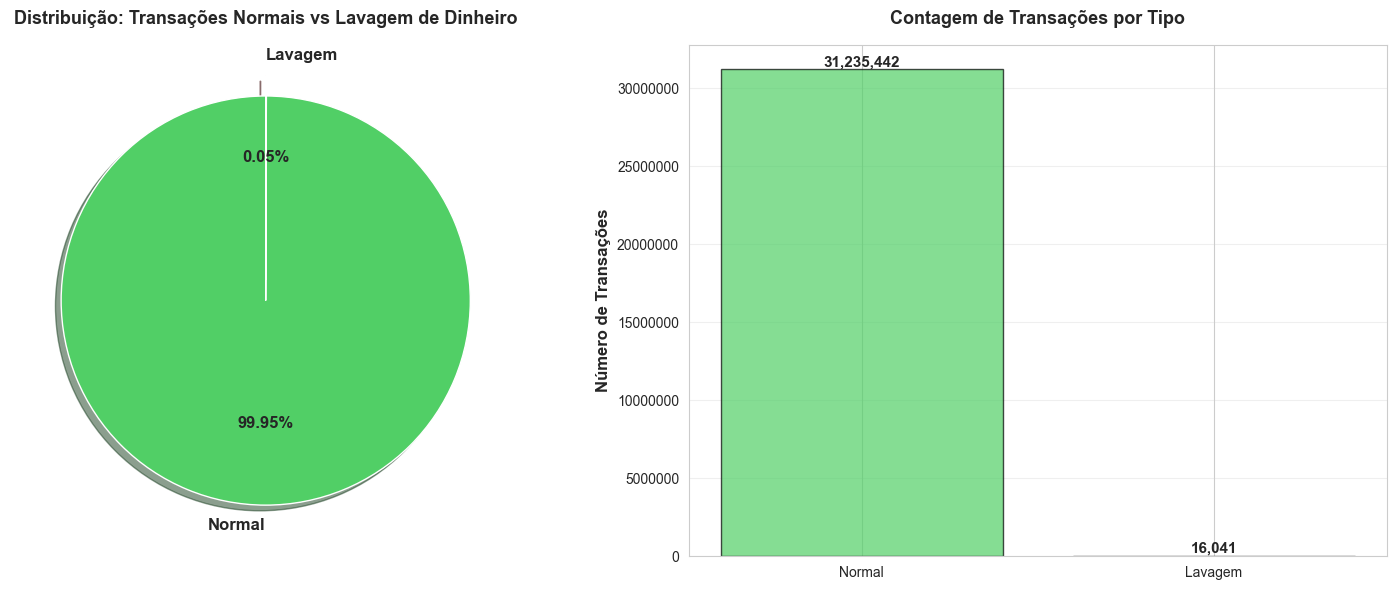

In [ ]:
# Análise geral da variável Is Laundering
print("=" * 80)
print("ANÁLISE DETALHADA: IS LAUNDERING (LAVAGEM DE DINHEIRO)")
print("=" * 80)

# Estatísticas gerais
total_records = len(df)
laundering_count = df['Is Laundering'].sum()
normal_count = total_records - laundering_count
laundering_pct = (laundering_count / total_records * 100)

print(f"\n📊 DISTRIBUIÇÃO GERAL:")
print(f"{'─' * 80}")
print(f"Total de transações:           {total_records:>15,} (100.00%)")
print(f"Transações NORMAIS:            {normal_count:>15,} ({100-laundering_pct:>6.2f}%)")
print(f"Transações de LAVAGEM:         {laundering_count:>15,} ({laundering_pct:>6.2f}%)")

# Visualização básica
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de pizza
labels_laund = ['Normal', 'Lavagem']
sizes_laund = [normal_count, laundering_count]
colors_laund = ['#51cf66', '#ff6b6b']
explode_laund = (0, 0.1)

axes[0].pie(sizes_laund, explode=explode_laund, labels=labels_laund, colors=colors_laund,
            autopct='%1.2f%%', shadow=True, startangle=90, 
            textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Distribuição: Transações Normais vs Lavagem de Dinheiro', 
                  fontsize=13, weight='bold', pad=15)

# Gráfico de barras
axes[1].bar(labels_laund, sizes_laund, color=colors_laund, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Número de Transações', fontsize=12, weight='bold')
axes[1].set_title('Contagem de Transações por Tipo', fontsize=13, weight='bold', pad=15)
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].grid(True, alpha=0.3, axis='y')

for i, (label, size) in enumerate(zip(labels_laund, sizes_laund)):
    axes[1].text(i, size, f'{size:,}', ha='center', va='bottom', 
                fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

### 10.6.1. Lavagem por Banco (From Bank e To Bank)

🏦 ANÁLISE DE LAVAGEM POR BANCO DE ORIGEM (FROM BANK)

Top 15 bancos de ORIGEM com mais casos de lavagem:



,Total_Transações,Casos_Lavagem,Taxa_Lavagem_%
From Bank Name,,,
First Bank of Montpelier,2901203,4109,0.14
National Bank of Fort Wayne,182084,92,0.05
National Bank of Watertown,110287,53,0.05
Capital Savings Bank,77624,52,0.07
Bank of Los Angeles,94255,50,0.05
Bank of Danbury,91592,50,0.05
Bank of Tuscon,90400,50,0.06
Savings Bank of Chicago,122052,49,0.04
Bank of Lacrosse,105212,47,0.04


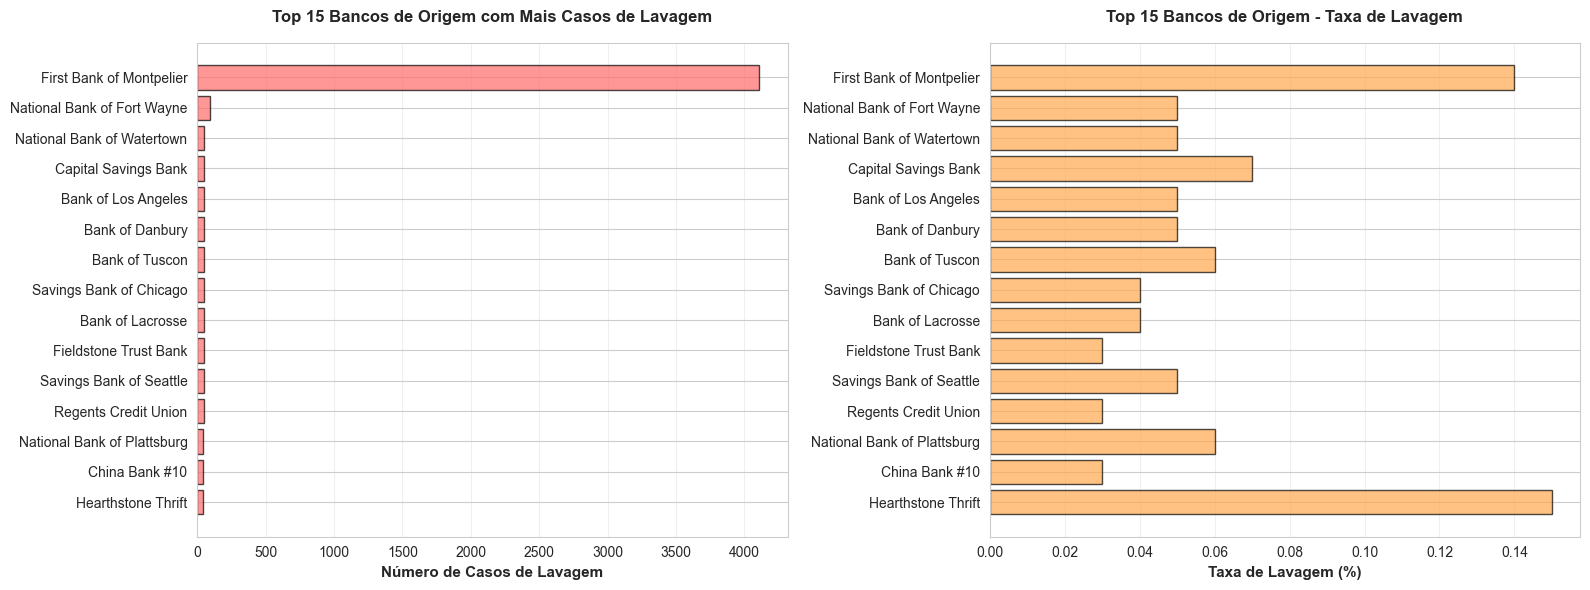

In [ ]:
# Análise de lavagem por banco de origem
print("=" * 80)
print("🏦 ANÁLISE DE LAVAGEM POR BANCO DE ORIGEM (FROM BANK)")
print("=" * 80)

from_bank_laundering = df[df['Is Laundering']==1].groupby('From Bank Name').agg({
    'Is Laundering': 'count'
}).rename(columns={'Is Laundering': 'Casos_Lavagem'})

from_bank_total = df.groupby('From Bank Name').size().rename('Total_Transações')
from_bank_analysis = pd.concat([from_bank_total, from_bank_laundering], axis=1).fillna(0)
from_bank_analysis['Casos_Lavagem'] = from_bank_analysis['Casos_Lavagem'].astype(int)
from_bank_analysis['Taxa_Lavagem_%'] = (from_bank_analysis['Casos_Lavagem'] / 
                                         from_bank_analysis['Total_Transações'] * 100).round(2)
from_bank_analysis = from_bank_analysis.sort_values('Casos_Lavagem', ascending=False)

print(f"\nTop 15 bancos de ORIGEM com mais casos de lavagem:\n")
display(from_bank_analysis.head(15))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_15_from = from_bank_analysis.head(15)
axes[0].barh(range(len(top_15_from)), top_15_from['Casos_Lavagem'], 
            color='#ff6b6b', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(top_15_from)))
axes[0].set_yticklabels(top_15_from.index)
axes[0].set_xlabel('Número de Casos de Lavagem', fontsize=11, weight='bold')
axes[0].set_title('Top 15 Bancos de Origem com Mais Casos de Lavagem', 
                 fontsize=12, weight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(len(top_15_from)), top_15_from['Taxa_Lavagem_%'], 
            color='#ffa94d', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_15_from)))
axes[1].set_yticklabels(top_15_from.index)
axes[1].set_xlabel('Taxa de Lavagem (%)', fontsize=11, weight='bold')
axes[1].set_title('Top 15 Bancos de Origem - Taxa de Lavagem', 
                 fontsize=12, weight='bold', pad=15)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


🏦 ANÁLISE DE LAVAGEM POR BANCO DE DESTINO (TO BANK)

Top 15 bancos de DESTINO com mais casos de lavagem:



,Total_Transações,Casos_Lavagem,Taxa_Lavagem_%
To Bank Name,,,
National Bank of Fort Wayne,96011,106,0.11
Fieldstone Trust Bank,87523,70,0.08
Bank of Los Angeles,94487,69,0.07
National Bank of Danbury,68100,63,0.09
Bank of Lacrosse,94241,63,0.07
First Bank of Milford,89227,61,0.07
Savings Bank of Chicago,82439,58,0.07
Bank of Butte,79475,56,0.07
National Bank of Watertown,82790,51,0.06


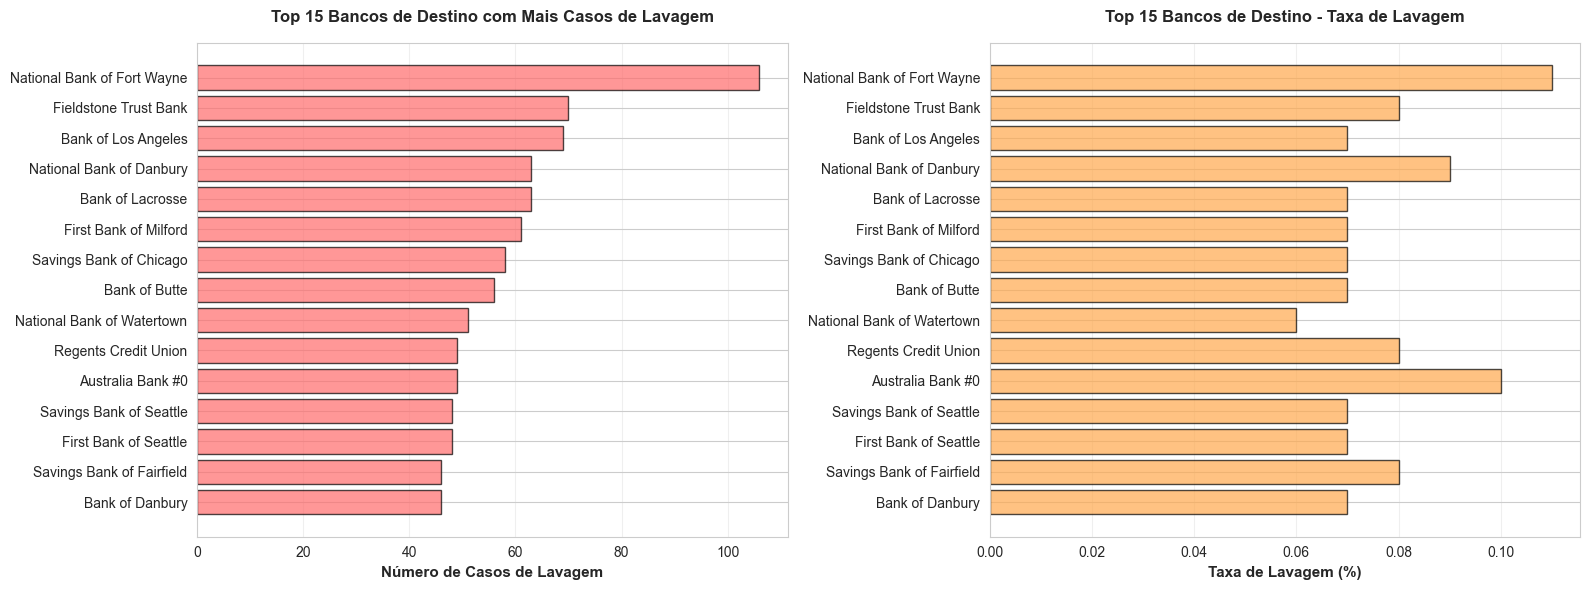

In [ ]:
# Análise de lavagem por banco de destino
print("\n" + "=" * 80)
print("🏦 ANÁLISE DE LAVAGEM POR BANCO DE DESTINO (TO BANK)")
print("=" * 80)

to_bank_laundering = df[df['Is Laundering']==1].groupby('To Bank Name').agg({
    'Is Laundering': 'count'
}).rename(columns={'Is Laundering': 'Casos_Lavagem'})

to_bank_total = df.groupby('To Bank Name').size().rename('Total_Transações')
to_bank_analysis = pd.concat([to_bank_total, to_bank_laundering], axis=1).fillna(0)
to_bank_analysis['Casos_Lavagem'] = to_bank_analysis['Casos_Lavagem'].astype(int)
to_bank_analysis['Taxa_Lavagem_%'] = (to_bank_analysis['Casos_Lavagem'] / 
                                       to_bank_analysis['Total_Transações'] * 100).round(2)
to_bank_analysis = to_bank_analysis.sort_values('Casos_Lavagem', ascending=False)

print(f"\nTop 15 bancos de DESTINO com mais casos de lavagem:\n")
display(to_bank_analysis.head(15))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_15_to = to_bank_analysis.head(15)
axes[0].barh(range(len(top_15_to)), top_15_to['Casos_Lavagem'], 
            color='#ff6b6b', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(top_15_to)))
axes[0].set_yticklabels(top_15_to.index)
axes[0].set_xlabel('Número de Casos de Lavagem', fontsize=11, weight='bold')
axes[0].set_title('Top 15 Bancos de Destino com Mais Casos de Lavagem', 
                 fontsize=12, weight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(len(top_15_to)), top_15_to['Taxa_Lavagem_%'], 
            color='#ffa94d', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_15_to)))
axes[1].set_yticklabels(top_15_to.index)
axes[1].set_xlabel('Taxa de Lavagem (%)', fontsize=11, weight='bold')
axes[1].set_title('Top 15 Bancos de Destino - Taxa de Lavagem', 
                 fontsize=12, weight='bold', pad=15)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### 10.6.2. Lavagem por Formato de Pagamento

💳 ANÁLISE DE LAVAGEM POR FORMATO DE PAGAMENTO

Distribuição de casos de lavagem por formato de pagamento:



,Casos_Lavagem,Total_Transações,Taxa_Lavagem_%
Payment Format,,,
ACH,11679,3773469,0.31
Cheque,2199,12066205,0.02
Credit Card,1309,8613616,0.02
Cash,637,3152974,0.02
Bitcoin,217,631886,0.03
Reinvestment,0,1905360,0.00
Wire,0,1107973,0.00


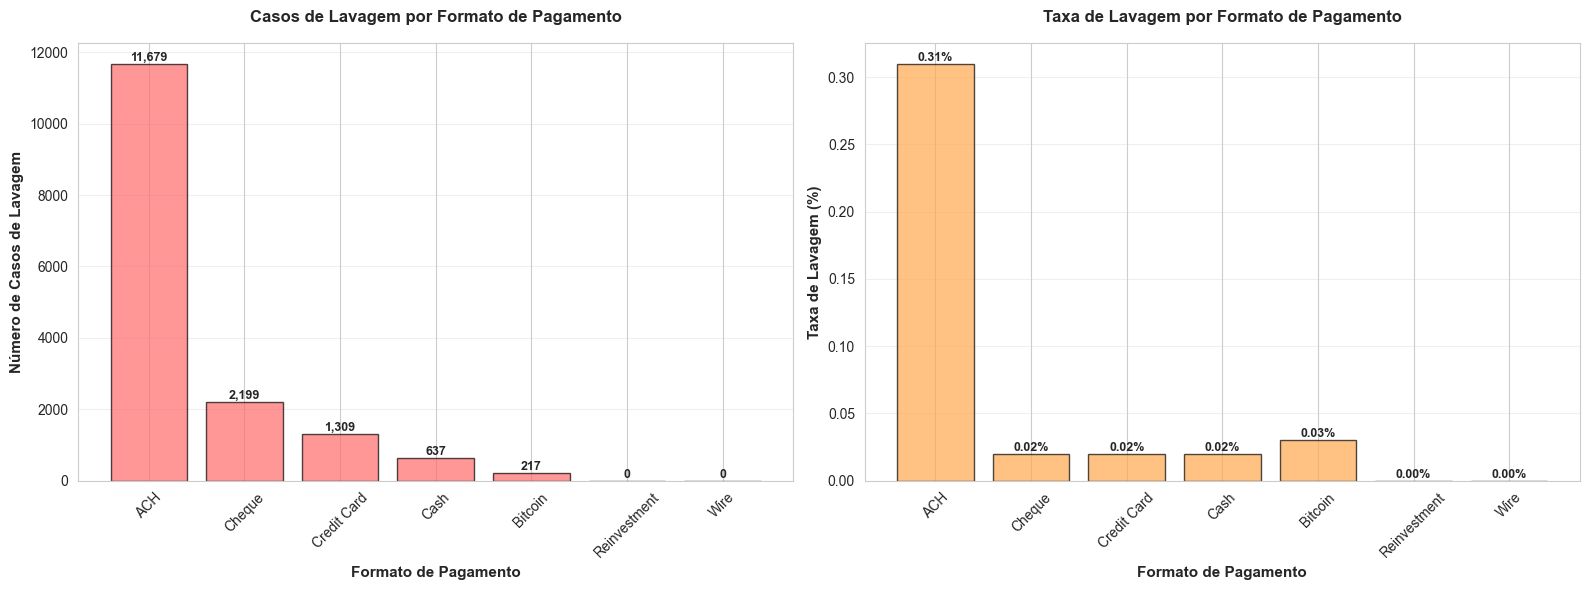

In [ ]:
# Análise de lavagem por formato de pagamento
print("=" * 80)
print("💳 ANÁLISE DE LAVAGEM POR FORMATO DE PAGAMENTO")
print("=" * 80)

payment_laundering = df.groupby('Payment Format').agg({
    'Is Laundering': ['sum', 'count']
})
payment_laundering.columns = ['Casos_Lavagem', 'Total_Transações']
payment_laundering['Taxa_Lavagem_%'] = (payment_laundering['Casos_Lavagem'] / 
                                         payment_laundering['Total_Transações'] * 100).round(2)
payment_laundering = payment_laundering.sort_values('Casos_Lavagem', ascending=False)

print("\nDistribuição de casos de lavagem por formato de pagamento:\n")
display(payment_laundering)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(payment_laundering.index, payment_laundering['Casos_Lavagem'],
           color='#ff6b6b', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Formato de Pagamento', fontsize=11, weight='bold')
axes[0].set_ylabel('Número de Casos de Lavagem', fontsize=11, weight='bold')
axes[0].set_title('Casos de Lavagem por Formato de Pagamento', 
                 fontsize=12, weight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

for i, (idx, val) in enumerate(payment_laundering['Casos_Lavagem'].items()):
    axes[0].text(i, val, f'{int(val):,}', ha='center', va='bottom', 
                fontsize=9, weight='bold')

axes[1].bar(payment_laundering.index, payment_laundering['Taxa_Lavagem_%'],
           color='#ffa94d', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Formato de Pagamento', fontsize=11, weight='bold')
axes[1].set_ylabel('Taxa de Lavagem (%)', fontsize=11, weight='bold')
axes[1].set_title('Taxa de Lavagem por Formato de Pagamento', 
                 fontsize=12, weight='bold', pad=15)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

for i, (idx, val) in enumerate(payment_laundering['Taxa_Lavagem_%'].items()):
    axes[1].text(i, val, f'{val:.2f}%', ha='center', va='bottom', 
                fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

### 10.6.3. Lavagem por Moeda

💰 ANÁLISE DE LAVAGEM POR MOEDA DE RECEBIMENTO

Distribuição de casos de lavagem por moeda de recebimento:



,Casos_Lavagem,Total_Transações,Taxa_Lavagem_%
Receiving Currency,,,
US Dollar,6169,11754603,0.05
Euro,4112,7380310,0.06
Yuan,859,1652247,0.05
Rupee,647,1239924,0.05
Yen,550,905603,0.06
Ruble,509,824268,0.06
UK Pound,496,949185,0.05
Canadian Dollar,478,1015533,0.05
Australian Dollar,467,975666,0.05


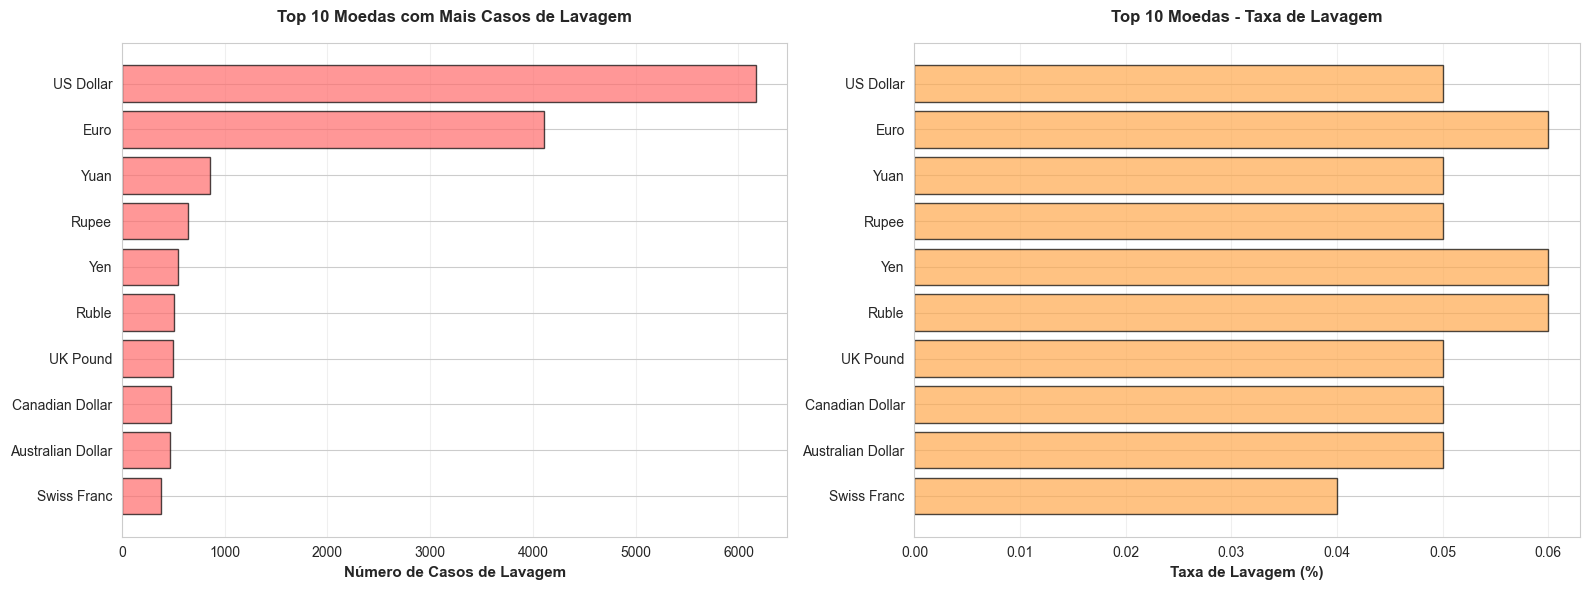

In [ ]:
# Análise de lavagem por moeda de recebimento
print("=" * 80)
print("💰 ANÁLISE DE LAVAGEM POR MOEDA DE RECEBIMENTO")
print("=" * 80)

currency_laundering = df.groupby('Receiving Currency').agg({
    'Is Laundering': ['sum', 'count']
})
currency_laundering.columns = ['Casos_Lavagem', 'Total_Transações']
currency_laundering['Taxa_Lavagem_%'] = (currency_laundering['Casos_Lavagem'] / 
                                          currency_laundering['Total_Transações'] * 100).round(2)
currency_laundering = currency_laundering.sort_values('Casos_Lavagem', ascending=False)

print("\nDistribuição de casos de lavagem por moeda de recebimento:\n")
display(currency_laundering.head(10))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_curr = currency_laundering.head(10)
axes[0].barh(range(len(top_curr)), top_curr['Casos_Lavagem'], 
            color='#ff6b6b', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(top_curr)))
axes[0].set_yticklabels(top_curr.index)
axes[0].set_xlabel('Número de Casos de Lavagem', fontsize=11, weight='bold')
axes[0].set_title('Top 10 Moedas com Mais Casos de Lavagem', 
                 fontsize=12, weight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(len(top_curr)), top_curr['Taxa_Lavagem_%'], 
            color='#ffa94d', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_curr)))
axes[1].set_yticklabels(top_curr.index)
axes[1].set_xlabel('Taxa de Lavagem (%)', fontsize=11, weight='bold')
axes[1].set_title('Top 10 Moedas - Taxa de Lavagem', 
                 fontsize=12, weight='bold', pad=15)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### 10.6.4. Lavagem por Entidade

🏢 ANÁLISE DE LAVAGEM POR ENTIDADE DE DESTINO (TO ENTITY)

Top 20 entidades de DESTINO com mais casos de lavagem:



,Total_Transações,Casos_Lavagem,To Entity Name,Taxa_Lavagem_%
To Entity ID,,,,
2AA2354E9F0,57529,69,Corporation #136151,0.12
2AA2385E860,131636,56,Direct #1,0.04
2AA23078BD0,44392,54,Corporation #128549,0.12
2AA234462B0,27747,36,Partnership #140251,0.13
2AA204036A0,122729,36,Sole Proprietorship #142810,0.03
2AA2323AE00,25409,32,Partnership #136221,0.13
2AA23220660,33432,31,Partnership #136131,0.09
2AA23228E80,21602,29,Corporation #132235,0.13
2AA23555530,22730,28,Corporation #136020,0.12


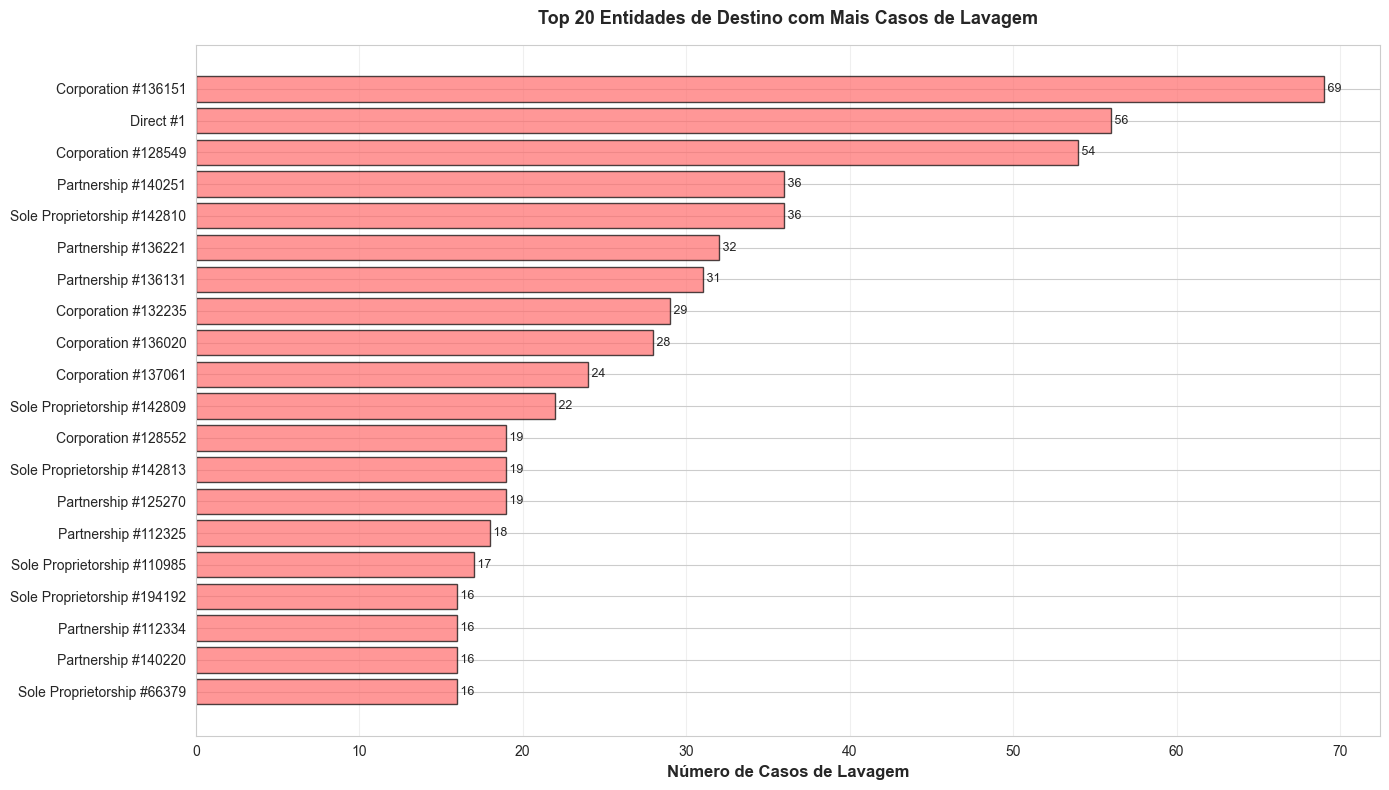

In [ ]:
# Análise de lavagem por entidade de destino (To Entity)
print("=" * 80)
print("🏢 ANÁLISE DE LAVAGEM POR ENTIDADE DE DESTINO (TO ENTITY)")
print("=" * 80)

# Top entidades de destino envolvidas em lavagem
to_entity_laundering = df[df['Is Laundering']==1].groupby('To Entity ID').agg({
    'Is Laundering': 'count',
    'To Entity Name': 'first'
}).rename(columns={'Is Laundering': 'Casos_Lavagem'})

to_entity_total = df.groupby('To Entity ID').size().rename('Total_Transações')
to_entity_analysis = pd.concat([to_entity_total, to_entity_laundering], axis=1).fillna(0)
to_entity_analysis['Casos_Lavagem'] = to_entity_analysis['Casos_Lavagem'].astype(int)
to_entity_analysis['Taxa_Lavagem_%'] = (to_entity_analysis['Casos_Lavagem'] / 
                                         to_entity_analysis['Total_Transações'] * 100).round(2)
to_entity_analysis = to_entity_analysis.sort_values('Casos_Lavagem', ascending=False)

print(f"\nTop 20 entidades de DESTINO com mais casos de lavagem:\n")
display(to_entity_analysis.head(20))

# Visualização
plt.figure(figsize=(14, 8))
top_20_entities = to_entity_analysis.head(20)
bars = plt.barh(range(len(top_20_entities)), top_20_entities['Casos_Lavagem'], 
               color='#ff6b6b', edgecolor='black', alpha=0.7)

# Adicionar labels com nomes das entidades (truncados)
labels = [f"{name[:30]}..." if len(str(name)) > 30 else str(name) 
          for name in top_20_entities['To Entity Name']]
plt.yticks(range(len(top_20_entities)), labels)
plt.xlabel('Número de Casos de Lavagem', fontsize=12, weight='bold')
plt.title('Top 20 Entidades de Destino com Mais Casos de Lavagem', 
         fontsize=13, weight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

# Adicionar valores nas barras
for i, val in enumerate(top_20_entities['Casos_Lavagem']):
    plt.text(val, i, f' {int(val)}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 10.6.5. Análise de Valores nas Transações de Lavagem

💵 ANÁLISE DE VALORES NAS TRANSAÇÕES DE LAVAGEM

Comparação de valores (Amount Received):



,count,mean,std,min,25%,50%,75%,max
Transações Normais,31235442.0,7.941807e+06,1.765175e+09,0.000001,204.40,1450.83,11986.78,2.020628e+12
Transações de Lavagem,16041.0,3.055281e+07,1.054254e+09,0.001492,1480.32,4178.97,16075.25,7.685622e+10


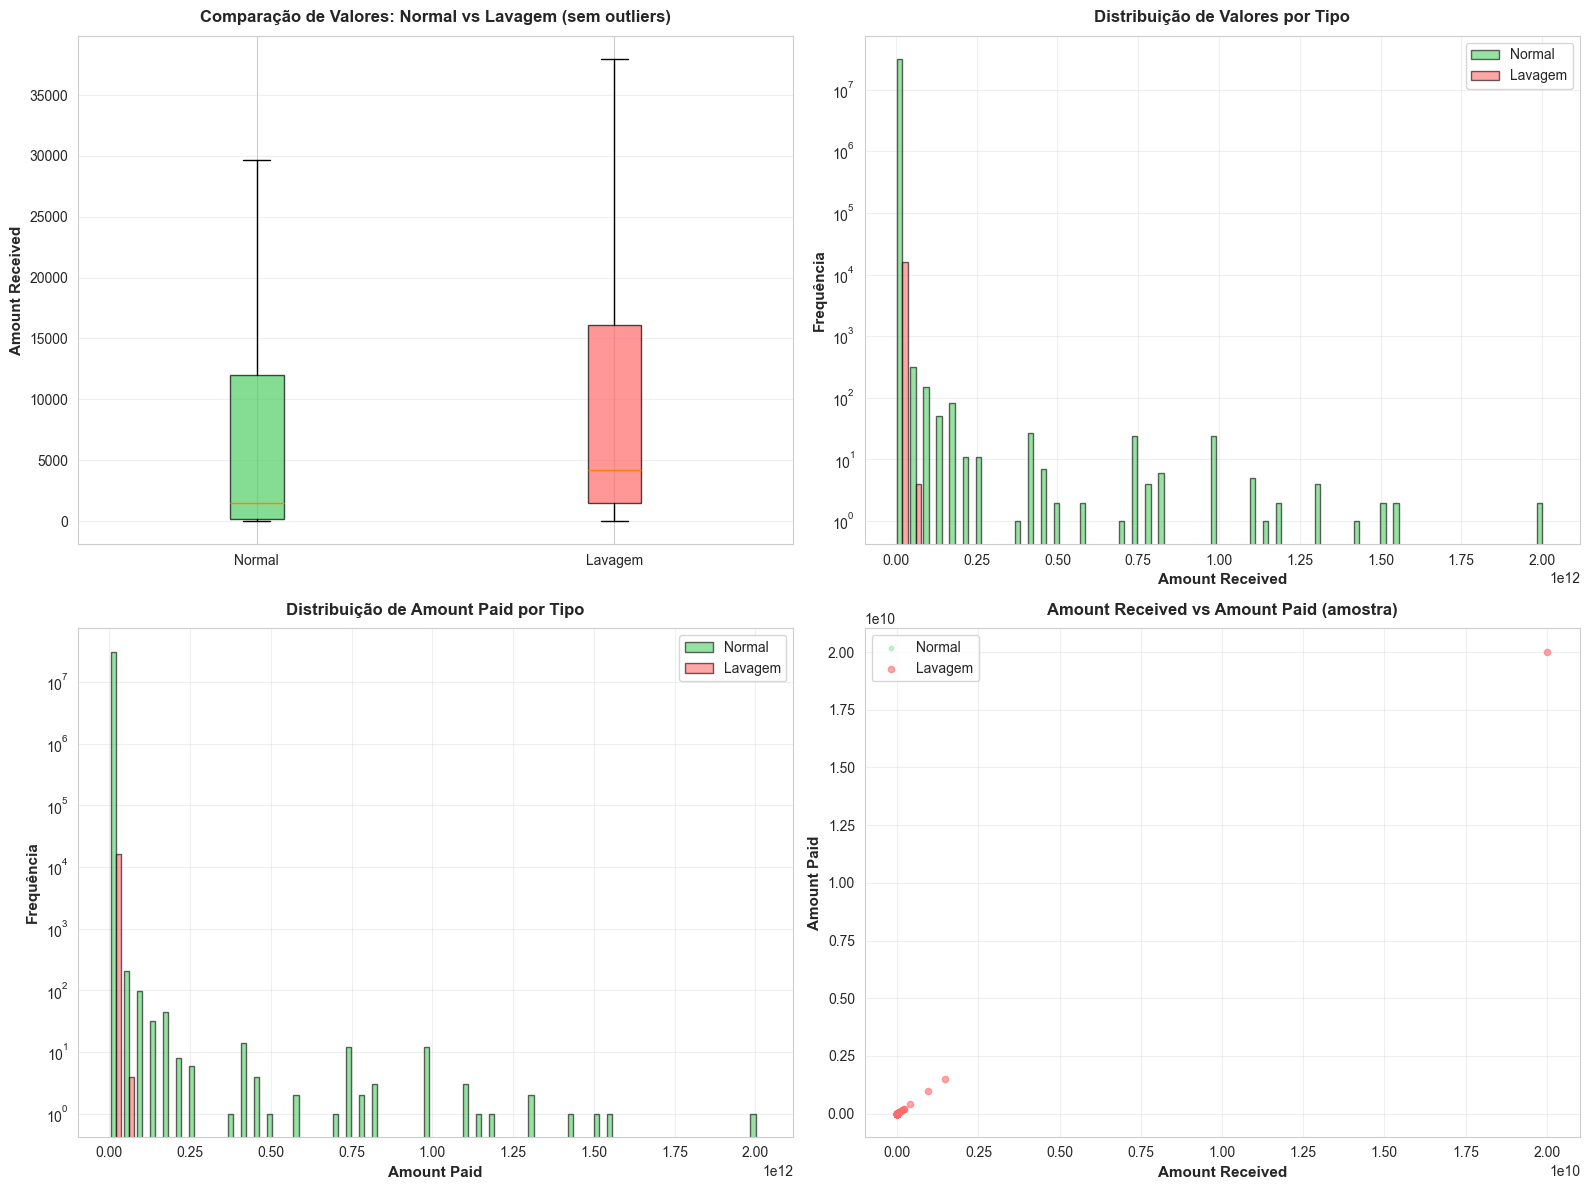

In [ ]:
# Análise de valores nas transações de lavagem
print("=" * 80)
print("💵 ANÁLISE DE VALORES NAS TRANSAÇÕES DE LAVAGEM")
print("=" * 80)

# Comparação de valores entre transações normais e de lavagem
laundering_values = df[df['Is Laundering']==1]['Amount Received'].describe()
normal_values = df[df['Is Laundering']==0]['Amount Received'].describe()

comparison_values = pd.DataFrame({
    'Transações Normais': normal_values,
    'Transações de Lavagem': laundering_values
})

print("\nComparação de valores (Amount Received):\n")
display(comparison_values.T)

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Boxplot comparativo (sem outliers)
data_values = [df[df['Is Laundering']==0]['Amount Received'].dropna(),
               df[df['Is Laundering']==1]['Amount Received'].dropna()]

bp = axes[0, 0].boxplot(data_values, labels=['Normal', 'Lavagem'],
                        patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ['#51cf66', '#ff6b6b']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0, 0].set_ylabel('Amount Received', fontsize=11, weight='bold')
axes[0, 0].set_title('Comparação de Valores: Normal vs Lavagem (sem outliers)', 
                    fontsize=12, weight='bold', pad=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Histograma comparativo (log scale)
axes[0, 1].hist([df[df['Is Laundering']==0]['Amount Received'].dropna(),
                 df[df['Is Laundering']==1]['Amount Received'].dropna()],
                bins=50, label=['Normal', 'Lavagem'],
                color=['#51cf66', '#ff6b6b'], alpha=0.6, edgecolor='black')
axes[0, 1].set_xlabel('Amount Received', fontsize=11, weight='bold')
axes[0, 1].set_ylabel('Frequência', fontsize=11, weight='bold')
axes[0, 1].set_title('Distribuição de Valores por Tipo', 
                    fontsize=12, weight='bold', pad=10)
axes[0, 1].legend(fontsize=10)
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Análise de Amount Paid
axes[1, 0].hist([df[df['Is Laundering']==0]['Amount Paid'].dropna(),
                 df[df['Is Laundering']==1]['Amount Paid'].dropna()],
                bins=50, label=['Normal', 'Lavagem'],
                color=['#51cf66', '#ff6b6b'], alpha=0.6, edgecolor='black')
axes[1, 0].set_xlabel('Amount Paid', fontsize=11, weight='bold')
axes[1, 0].set_ylabel('Frequência', fontsize=11, weight='bold')
axes[1, 0].set_title('Distribuição de Amount Paid por Tipo', 
                    fontsize=12, weight='bold', pad=10)
axes[1, 0].legend(fontsize=10)
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Scatter plot: Amount Received vs Amount Paid
laundering_sample = df[df['Is Laundering']==1].sample(min(1000, laundering_count))
normal_sample = df[df['Is Laundering']==0].sample(1000)

axes[1, 1].scatter(normal_sample['Amount Received'], normal_sample['Amount Paid'],
                  alpha=0.3, s=10, color='#51cf66', label='Normal')
axes[1, 1].scatter(laundering_sample['Amount Received'], laundering_sample['Amount Paid'],
                  alpha=0.6, s=20, color='#ff6b6b', label='Lavagem')
axes[1, 1].set_xlabel('Amount Received', fontsize=11, weight='bold')
axes[1, 1].set_ylabel('Amount Paid', fontsize=11, weight='bold')
axes[1, 1].set_title('Amount Received vs Amount Paid (amostra)', 
                    fontsize=12, weight='bold', pad=10)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 10.6.6. Análise Temporal de Lavagem

📅 ANÁLISE TEMPORAL DE LAVAGEM DE DINHEIRO


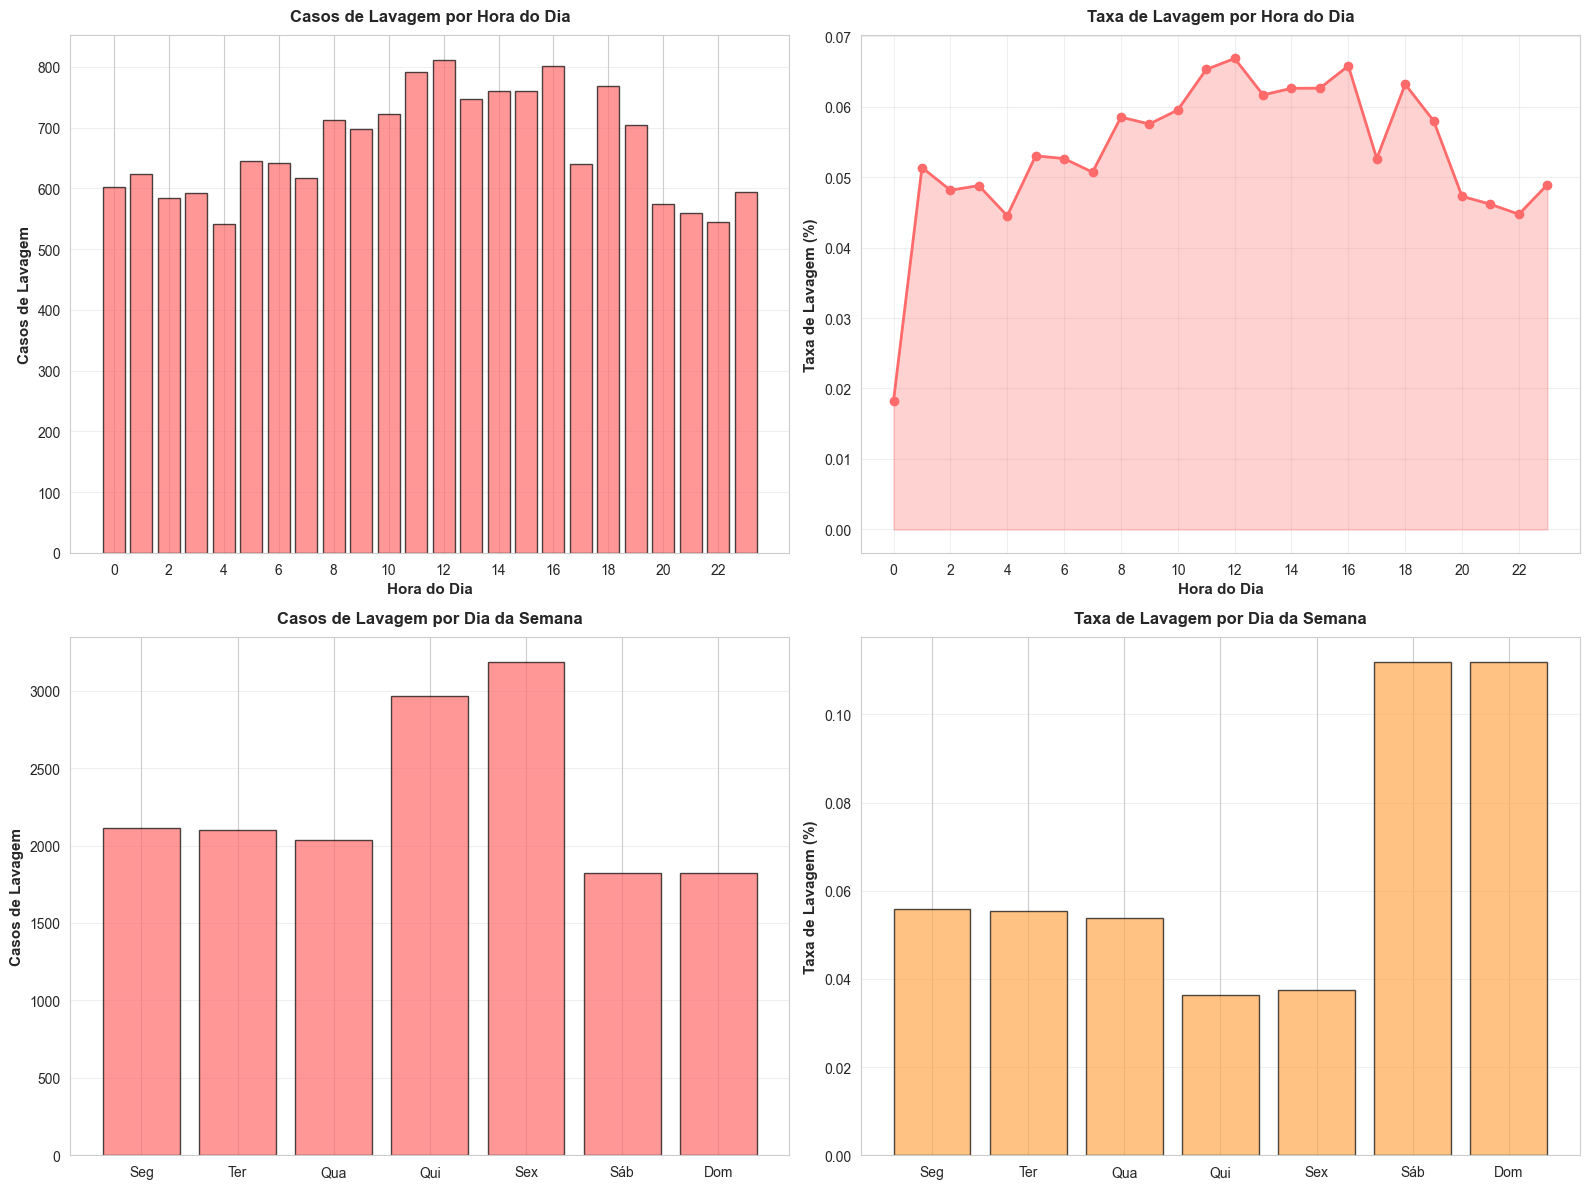


Resumo temporal:
Hora com mais casos: 12h (812 casos)
Dia com mais casos: Friday (3186 casos)
Taxa média por hora: 0.0537%
Taxa média por dia: 0.0661%


In [ ]:
# Análise temporal de casos de lavagem
print("=" * 80)
print("📅 ANÁLISE TEMPORAL DE LAVAGEM DE DINHEIRO")
print("=" * 80)

# Converter timestamp para datetime
df['Timestamp_dt'] = pd.to_datetime(df['Timestamp'])
df['Date'] = df['Timestamp_dt'].dt.date
df['Hour'] = df['Timestamp_dt'].dt.hour
df['DayOfWeek'] = df['Timestamp_dt'].dt.dayofweek
df['DayName'] = df['Timestamp_dt'].dt.day_name()

# Análise por hora do dia
hourly_laundering = df[df['Is Laundering']==1].groupby('Hour').size()
hourly_total = df.groupby('Hour').size()
hourly_rate = (hourly_laundering / hourly_total * 100).fillna(0)

# Análise por dia da semana
daily_laundering = df[df['Is Laundering']==1].groupby('DayName').size()
daily_total = df.groupby('DayName').size()

# Ordenar dias da semana corretamente
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_laundering = daily_laundering.reindex(day_order, fill_value=0)
daily_total = daily_total.reindex(day_order, fill_value=1)
daily_rate = (daily_laundering / daily_total * 100)

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Casos por hora
axes[0, 0].bar(hourly_laundering.index, hourly_laundering.values,
              color='#ff6b6b', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Hora do Dia', fontsize=11, weight='bold')
axes[0, 0].set_ylabel('Casos de Lavagem', fontsize=11, weight='bold')
axes[0, 0].set_title('Casos de Lavagem por Hora do Dia', 
                    fontsize=12, weight='bold', pad=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].set_xticks(range(0, 24, 2))

# Taxa por hora
axes[0, 1].plot(hourly_rate.index, hourly_rate.values, 
               marker='o', linewidth=2, markersize=6, color='#ff6b6b')
axes[0, 1].fill_between(hourly_rate.index, hourly_rate.values, alpha=0.3, color='#ff6b6b')
axes[0, 1].set_xlabel('Hora do Dia', fontsize=11, weight='bold')
axes[0, 1].set_ylabel('Taxa de Lavagem (%)', fontsize=11, weight='bold')
axes[0, 1].set_title('Taxa de Lavagem por Hora do Dia', 
                    fontsize=12, weight='bold', pad=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(0, 24, 2))

# Casos por dia da semana
axes[1, 0].bar(range(len(daily_laundering)), daily_laundering.values,
              color='#ff6b6b', edgecolor='black', alpha=0.7)
axes[1, 0].set_xticks(range(len(daily_laundering)))
axes[1, 0].set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
axes[1, 0].set_ylabel('Casos de Lavagem', fontsize=11, weight='bold')
axes[1, 0].set_title('Casos de Lavagem por Dia da Semana', 
                    fontsize=12, weight='bold', pad=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Taxa por dia da semana
axes[1, 1].bar(range(len(daily_rate)), daily_rate.values,
              color='#ffa94d', edgecolor='black', alpha=0.7)
axes[1, 1].set_xticks(range(len(daily_rate)))
axes[1, 1].set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
axes[1, 1].set_ylabel('Taxa de Lavagem (%)', fontsize=11, weight='bold')
axes[1, 1].set_title('Taxa de Lavagem por Dia da Semana', 
                    fontsize=12, weight='bold', pad=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nResumo temporal:")
print(f"Hora com mais casos: {hourly_laundering.idxmax()}h ({hourly_laundering.max()} casos)")
print(f"Dia com mais casos: {daily_laundering.idxmax()} ({daily_laundering.max()} casos)")
print(f"Taxa média por hora: {hourly_rate.mean():.4f}%")
print(f"Taxa média por dia: {daily_rate.mean():.4f}%")

### 10.6.7. Resumo da Análise de Lavagem

In [ ]:
# Resumo consolidado da análise de lavagem
print("=" * 80)
print("📋 RESUMO CONSOLIDADO - ANÁLISE DE LAVAGEM DE DINHEIRO")
print("=" * 80)

print(f"\n🎯 ESTATÍSTICAS GERAIS:")
print(f"{'─' * 80}")
print(f"Taxa geral de lavagem: {laundering_pct:.2f}%")
print(f"Total de casos: {laundering_count:,}")

print(f"\n🏦 BANCOS:")
print(f"{'─' * 80}")
print(f"Banco de origem com mais casos: {from_bank_analysis.index[0]}")
print(f"  → Casos: {from_bank_analysis.iloc[0]['Casos_Lavagem']:,.0f}")
print(f"  → Taxa: {from_bank_analysis.iloc[0]['Taxa_Lavagem_%']:.2f}%")
print(f"\nBanco de destino com mais casos: {to_bank_analysis.index[0]}")
print(f"  → Casos: {to_bank_analysis.iloc[0]['Casos_Lavagem']:,.0f}")
print(f"  → Taxa: {to_bank_analysis.iloc[0]['Taxa_Lavagem_%']:.2f}%")

print(f"\n💳 FORMATOS DE PAGAMENTO:")
print(f"{'─' * 80}")
print(f"Formato com mais casos: {payment_laundering.index[0]}")
print(f"  → Casos: {payment_laundering.iloc[0]['Casos_Lavagem']:,.0f}")
print(f"  → Taxa: {payment_laundering.iloc[0]['Taxa_Lavagem_%']:.2f}%")

print(f"\n💰 MOEDAS:")
print(f"{'─' * 80}")
print(f"Moeda com mais casos: {currency_laundering.index[0]}")
print(f"  → Casos: {currency_laundering.iloc[0]['Casos_Lavagem']:,.0f}")
print(f"  → Taxa: {currency_laundering.iloc[0]['Taxa_Lavagem_%']:.2f}%")

print(f"\n🏢 ENTIDADES:")
print(f"{'─' * 80}")
print(f"Entidade de destino com mais casos: {to_entity_analysis.iloc[0]['To Entity Name']}")
print(f"  → ID: {to_entity_analysis.index[0]}")
print(f"  → Casos: {to_entity_analysis.iloc[0]['Casos_Lavagem']:,.0f}")
print(f"  → Taxa: {to_entity_analysis.iloc[0]['Taxa_Lavagem_%']:.2f}%")

print(f"\n💵 VALORES:")
print(f"{'─' * 80}")
print(f"Valor médio (Normal): ${normal_values['mean']:,.2f}")
print(f"Valor médio (Lavagem): ${laundering_values['mean']:,.2f}")
print(f"Diferença: {((laundering_values['mean'] / normal_values['mean']) - 1) * 100:+.2f}%")

print(f"\n📅 TEMPORAL:")
print(f"{'─' * 80}")
print(f"Hora com mais casos: {hourly_laundering.idxmax()}h")
print(f"Dia com mais casos: {daily_laundering.idxmax()}")

print("\n" + "=" * 80)
print("ANÁLISE DE LAVAGEM CONCLUÍDA!")
print("=" * 80)

📋 RESUMO CONSOLIDADO - ANÁLISE DE LAVAGEM DE DINHEIRO

🎯 ESTATÍSTICAS GERAIS:
────────────────────────────────────────────────────────────────────────────────
Taxa geral de lavagem: 0.05%
Total de casos: 16,041

🏦 BANCOS:
────────────────────────────────────────────────────────────────────────────────
Banco de origem com mais casos: First Bank of Montpelier
  → Casos: 4,109
  → Taxa: 0.14%

Banco de destino com mais casos: National Bank of Fort Wayne
  → Casos: 106
  → Taxa: 0.11%

💳 FORMATOS DE PAGAMENTO:
────────────────────────────────────────────────────────────────────────────────
Formato com mais casos: ACH
  → Casos: 11,679
  → Taxa: 0.31%

💰 MOEDAS:
────────────────────────────────────────────────────────────────────────────────
Moeda com mais casos: US Dollar
  → Casos: 6,169
  → Taxa: 0.05%

🏢 ENTIDADES:
────────────────────────────────────────────────────────────────────────────────
Entidade de destino com mais casos: Corporation #136151
  → ID: 2AA2354E9F0
  → Casos: 69
  →

## 10.7. Análise de Conta Específica: To Account 10042B660

🔎 ANÁLISE DETALHADA: TO ACCOUNT 10042B660

📊 VISÃO GERAL DA CONTA 10042B660:
────────────────────────────────────────────────────────────────────────────────
Total de transações:                     6,811
Transações NORMAIS:                      6,808 ( 99.96%)
Transações de LAVAGEM:                       3 (  0.04%)

💡 Esta conta tem uma taxa de lavagem de 0.04%
   (Comparado com a média geral de 0.05%)


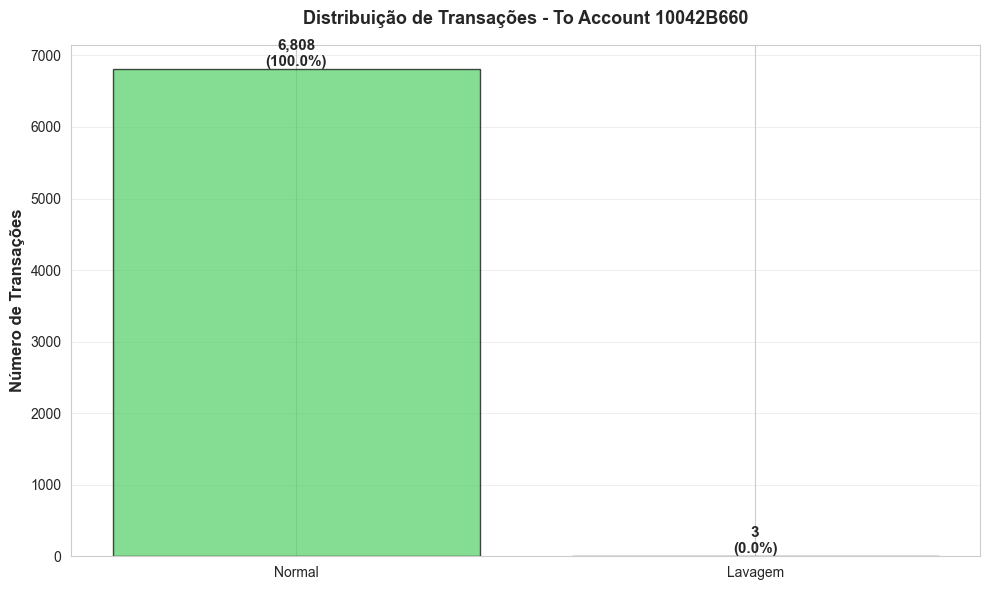

In [ ]:
# Análise detalhada da conta To Account 10042B660
print("=" * 80)
print("🔎 ANÁLISE DETALHADA: TO ACCOUNT 10042B660")
print("=" * 80)

# Filtrar todas as transações para esta conta
target_account = '10042B660'
account_df = df[df['To Account'] == target_account].copy()

# Estatísticas básicas
total_trans_account = len(account_df)
laundering_account = account_df['Is Laundering'].sum()
normal_account = total_trans_account - laundering_account
laundering_pct_account = (laundering_account / total_trans_account * 100) if total_trans_account > 0 else 0

print(f"\n📊 VISÃO GERAL DA CONTA {target_account}:")
print(f"{'─' * 80}")
print(f"Total de transações:           {total_trans_account:>15,}")
print(f"Transações NORMAIS:            {normal_account:>15,} ({100-laundering_pct_account:>6.2f}%)")
print(f"Transações de LAVAGEM:         {laundering_account:>15,} ({laundering_pct_account:>6.2f}%)")

if total_trans_account == 0:
    print(f"\n⚠️ AVISO: Não foram encontradas transações para a conta {target_account}")
    print("Verifique se o número da conta está correto.")
else:
    print(f"\n💡 Esta conta tem uma taxa de lavagem de {laundering_pct_account:.2f}%")
    print(f"   (Comparado com a média geral de {laundering_pct:.2f}%)")
    
    # Comparação visual
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    categories = ['Normal', 'Lavagem']
    values = [normal_account, laundering_account]
    colors = ['#51cf66', '#ff6b6b']
    
    bars = ax.bar(categories, values, color=colors, edgecolor='black', alpha=0.7)
    ax.set_ylabel('Número de Transações', fontsize=12, weight='bold')
    ax.set_title(f'Distribuição de Transações - To Account {target_account}', 
                fontsize=13, weight='bold', pad=15)
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, (cat, val) in enumerate(zip(categories, values)):
        ax.text(i, val, f'{val:,}\n({val/total_trans_account*100:.1f}%)', 
               ha='center', va='bottom', fontsize=11, weight='bold')
    
    plt.tight_layout()
    plt.show()

### 10.7.1. Análise de Valores das Transações


💵 ANÁLISE DE VALORES - TO ACCOUNT 1004B660

Estatísticas de valores (Amount Received):



,count,mean,std,min,25%,50%,75%,max
Normal,6808.0,460.963709,812.516221,0.01,121.9875,255.34,497.670,31343.00
Lavagem,3.0,212.136667,181.870109,70.76,109.5500,148.34,282.825,417.31


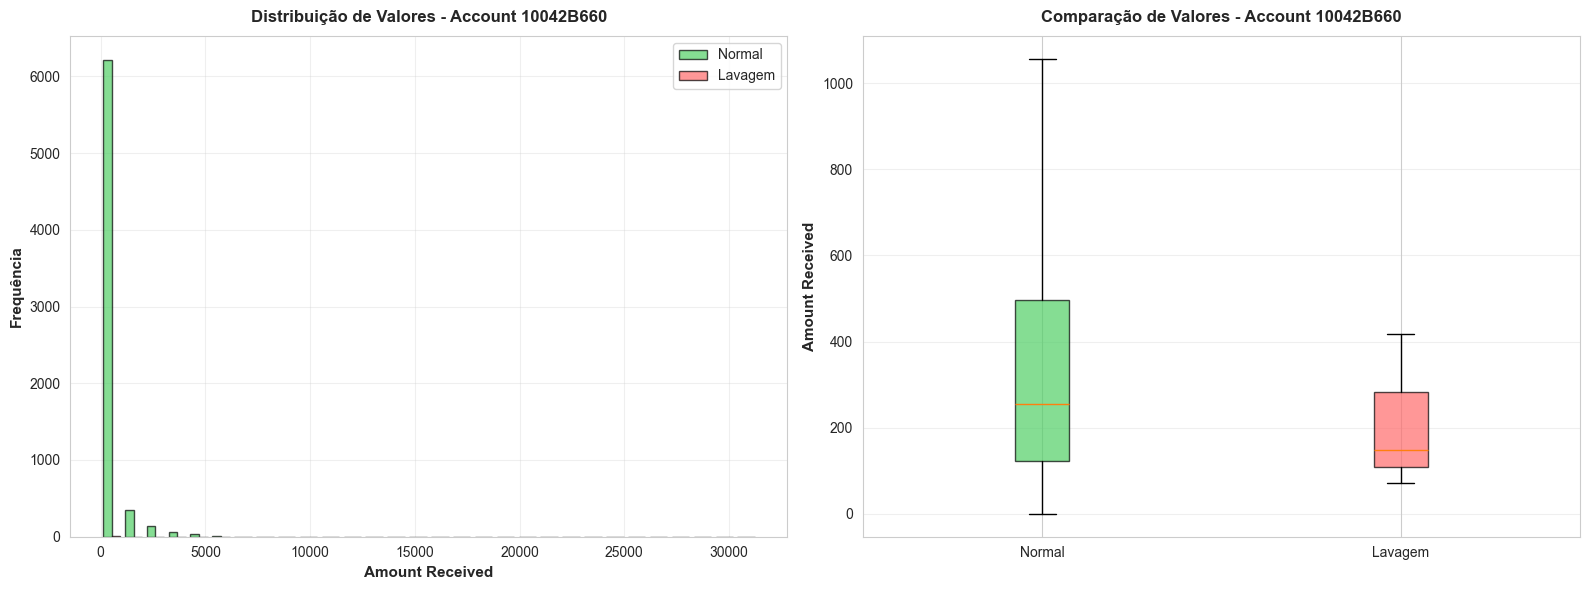

In [ ]:
if total_trans_account > 0:
    print("\n" + "=" * 80)
    print("💵 ANÁLISE DE VALORES - TO ACCOUNT 1004B660")
    print("=" * 80)
    
    # Estatísticas de valores
    amount_stats = pd.DataFrame({
        'Normal': account_df[account_df['Is Laundering']==0]['Amount Received'].describe(),
        'Lavagem': account_df[account_df['Is Laundering']==1]['Amount Received'].describe() if laundering_account > 0 else pd.Series()
    })
    
    print("\nEstatísticas de valores (Amount Received):\n")
    display(amount_stats.T)
    
    # Comparação visual
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histograma
    if laundering_account > 0:
        axes[0].hist([account_df[account_df['Is Laundering']==0]['Amount Received'].dropna(),
                      account_df[account_df['Is Laundering']==1]['Amount Received'].dropna()],
                     bins=30, label=['Normal', 'Lavagem'],
                     color=['#51cf66', '#ff6b6b'], alpha=0.7, edgecolor='black')
    else:
        axes[0].hist(account_df['Amount Received'].dropna(), bins=30, 
                     color='#51cf66', alpha=0.7, edgecolor='black', label='Normal')
    
    axes[0].set_xlabel('Amount Received', fontsize=11, weight='bold')
    axes[0].set_ylabel('Frequência', fontsize=11, weight='bold')
    axes[0].set_title(f'Distribuição de Valores - Account {target_account}', 
                     fontsize=12, weight='bold', pad=10)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Boxplot
    if laundering_account > 0:
        data_box = [account_df[account_df['Is Laundering']==0]['Amount Received'].dropna(),
                    account_df[account_df['Is Laundering']==1]['Amount Received'].dropna()]
        labels_box = ['Normal', 'Lavagem']
    else:
        data_box = [account_df['Amount Received'].dropna()]
        labels_box = ['Normal']
    
    bp = axes[1].boxplot(data_box, labels=labels_box, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], ['#51cf66', '#ff6b6b'][:len(labels_box)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[1].set_ylabel('Amount Received', fontsize=11, weight='bold')
    axes[1].set_title(f'Comparação de Valores - Account {target_account}', 
                     fontsize=12, weight='bold', pad=10)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

### 10.7.2. Análise de Bancos Envolvidos


🏦 BANCOS ENVOLVIDOS - TO ACCOUNT 1004B660

📤 Bancos de Origem (From Bank):

Total de bancos de origem únicos: 452

Top 10 bancos de origem:



,Normal,Lavagem,Total
From Bank Name,,,
National Bank of New Orleans,54,0,54
First Bank of Laramie,45,0,45
Savings Bank of Lacrosse,45,0,45
Savings Bank of Billings,40,0,40
First Bank of Butte,40,0,40
Arbor Federal Bank,40,0,40
National Bank of Arkadelphia,39,0,39
First Bank of New York,39,0,39
National Bank of the North,39,0,39



📥 Banco de Destino (To Bank):

Banco: First Bank of Montpelier
ID: 70


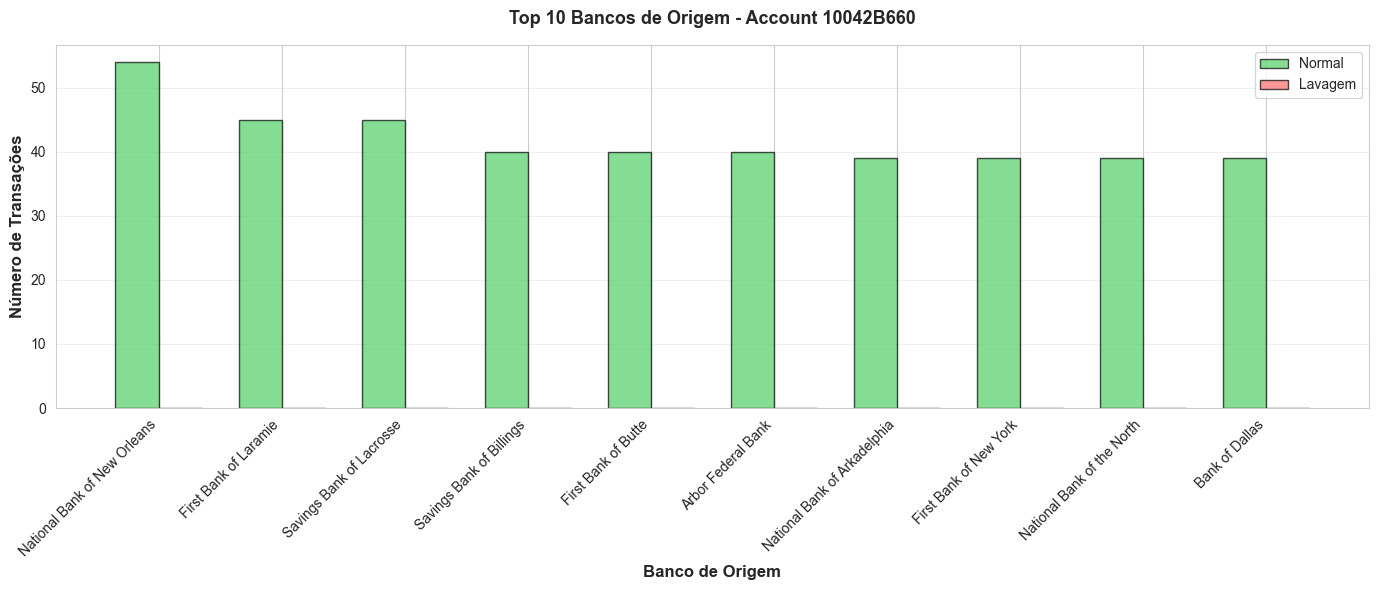

In [ ]:
if total_trans_account > 0:
    print("\n" + "=" * 80)
    print("🏦 BANCOS ENVOLVIDOS - TO ACCOUNT 1004B660")
    print("=" * 80)
    
    # Análise de bancos de origem
    print("\n📤 Bancos de Origem (From Bank):")
    from_banks = account_df.groupby(['From Bank Name', 'Is Laundering']).size().unstack(fill_value=0)
    from_banks.columns = ['Normal', 'Lavagem'] if 1 in from_banks.columns else ['Normal']
    from_banks['Total'] = from_banks.sum(axis=1)
    from_banks = from_banks.sort_values('Total', ascending=False)
    
    print(f"\nTotal de bancos de origem únicos: {len(from_banks)}")
    print(f"\nTop 10 bancos de origem:\n")
    display(from_banks.head(10))
    
    # Banco de destino (To Bank)
    print("\n📥 Banco de Destino (To Bank):")
    to_bank_info = account_df[['To Bank Name', 'To Bank']].drop_duplicates()
    print(f"\nBanco: {to_bank_info['To Bank Name'].iloc[0]}")
    print(f"ID: {int(to_bank_info['To Bank'].iloc[0])}")
    
    # Visualização dos top bancos de origem
    if len(from_banks) > 0:
        plt.figure(figsize=(14, 6))
        top_banks = from_banks.head(10)
        
        x = np.arange(len(top_banks))
        width = 0.35
        
        if 'Lavagem' in top_banks.columns:
            plt.bar(x - width/2, top_banks['Normal'], width, label='Normal', 
                   color='#51cf66', edgecolor='black', alpha=0.7)
            plt.bar(x + width/2, top_banks['Lavagem'], width, label='Lavagem', 
                   color='#ff6b6b', edgecolor='black', alpha=0.7)
        else:
            plt.bar(x, top_banks['Normal'], width*2, label='Normal', 
                   color='#51cf66', edgecolor='black', alpha=0.7)
        
        plt.xlabel('Banco de Origem', fontsize=12, weight='bold')
        plt.ylabel('Número de Transações', fontsize=12, weight='bold')
        plt.title(f'Top 10 Bancos de Origem - Account {target_account}', 
                 fontsize=13, weight='bold', pad=15)
        plt.xticks(x, top_banks.index, rotation=45, ha='right')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

### 10.7.3. Análise de Entidades Envolvidas


🏢 ENTIDADES ENVOLVIDAS - TO ACCOUNT 1004B660

📥 Entidade de Destino:
Nome: Partnership #137
ID: 2AA2322DC50

📤 Entidades de Origem:

Total de entidades de origem únicas: 2213

Top 15 entidades de origem:



,Normal,Lavagem,Total
From Entity Name,,,
Partnership #18890,9,0,9
Partnership #30445,6,0,6
Corporation #11780,6,0,6
Corporation #2218,6,0,6
Partnership #15108,6,0,6
Corporation #5112,6,0,6
Corporation #3903,6,0,6
Corporation #11972,6,0,6
Partnership #17945,6,0,6


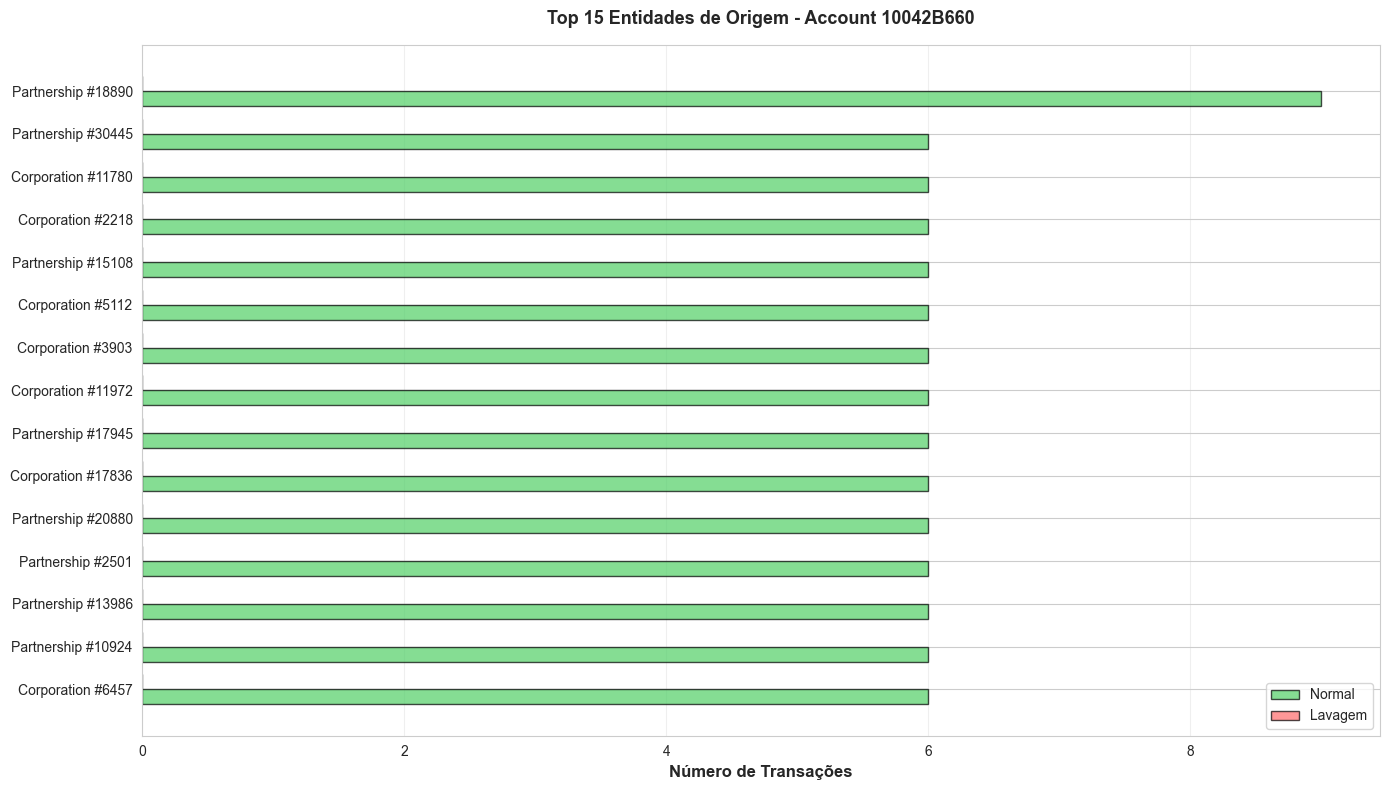

In [ ]:
if total_trans_account > 0:
    print("\n" + "=" * 80)
    print("🏢 ENTIDADES ENVOLVIDAS - TO ACCOUNT 1004B660")
    print("=" * 80)
    
    # Entidade de destino (To Entity)
    print("\n📥 Entidade de Destino:")
    to_entity_info = account_df[['To Entity ID', 'To Entity Name']].drop_duplicates()
    print(f"Nome: {to_entity_info['To Entity Name'].iloc[0]}")
    print(f"ID: {to_entity_info['To Entity ID'].iloc[0]}")
    
    # Entidades de origem (From Entity)
    print("\n📤 Entidades de Origem:")
    from_entities = account_df.groupby(['From Entity Name', 'Is Laundering']).size().unstack(fill_value=0)
    from_entities.columns = ['Normal', 'Lavagem'] if 1 in from_entities.columns else ['Normal']
    from_entities['Total'] = from_entities.sum(axis=1)
    from_entities = from_entities.sort_values('Total', ascending=False)
    
    print(f"\nTotal de entidades de origem únicas: {len(from_entities)}")
    print(f"\nTop 15 entidades de origem:\n")
    display(from_entities.head(15))
    
    # Visualização
    if len(from_entities) > 0:
        plt.figure(figsize=(14, 8))
        top_entities = from_entities.head(15)
        
        x = np.arange(len(top_entities))
        width = 0.35
        
        if 'Lavagem' in top_entities.columns:
            plt.barh(x + width/2, top_entities['Normal'], width, label='Normal', 
                    color='#51cf66', edgecolor='black', alpha=0.7)
            plt.barh(x - width/2, top_entities['Lavagem'], width, label='Lavagem', 
                    color='#ff6b6b', edgecolor='black', alpha=0.7)
        else:
            plt.barh(x, top_entities['Normal'], width*2, label='Normal', 
                    color='#51cf66', edgecolor='black', alpha=0.7)
        
        # Truncar nomes longos
        labels_ent = [name[:40] + '...' if len(name) > 40 else name for name in top_entities.index]
        plt.yticks(x, labels_ent)
        plt.xlabel('Número de Transações', fontsize=12, weight='bold')
        plt.title(f'Top 15 Entidades de Origem - Account {target_account}', 
                 fontsize=13, weight='bold', pad=15)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3, axis='x')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

### 10.7.4. Análise de Contas de Origem


💳 CONTAS DE ORIGEM (FROM ACCOUNT) - TO ACCOUNT 1004B660

Total de contas de origem únicas: 2293

Top 20 contas de origem:



,Normal,Lavagem,Total
From Account,,,
8505F31E0,3,0,3
8505C74A0,3,0,3
8504099E0,3,0,3
84F745360,3,0,3
84F7272B0,3,0,3
84F6F9210,3,0,3
84F6D7B20,3,0,3
84F557870,3,0,3
84F53CE60,3,0,3



Distribuição de transações por conta de origem:
count    2293.000000
mean        2.970345
std         0.241779
min         1.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         3.000000
Name: Total, dtype: float64


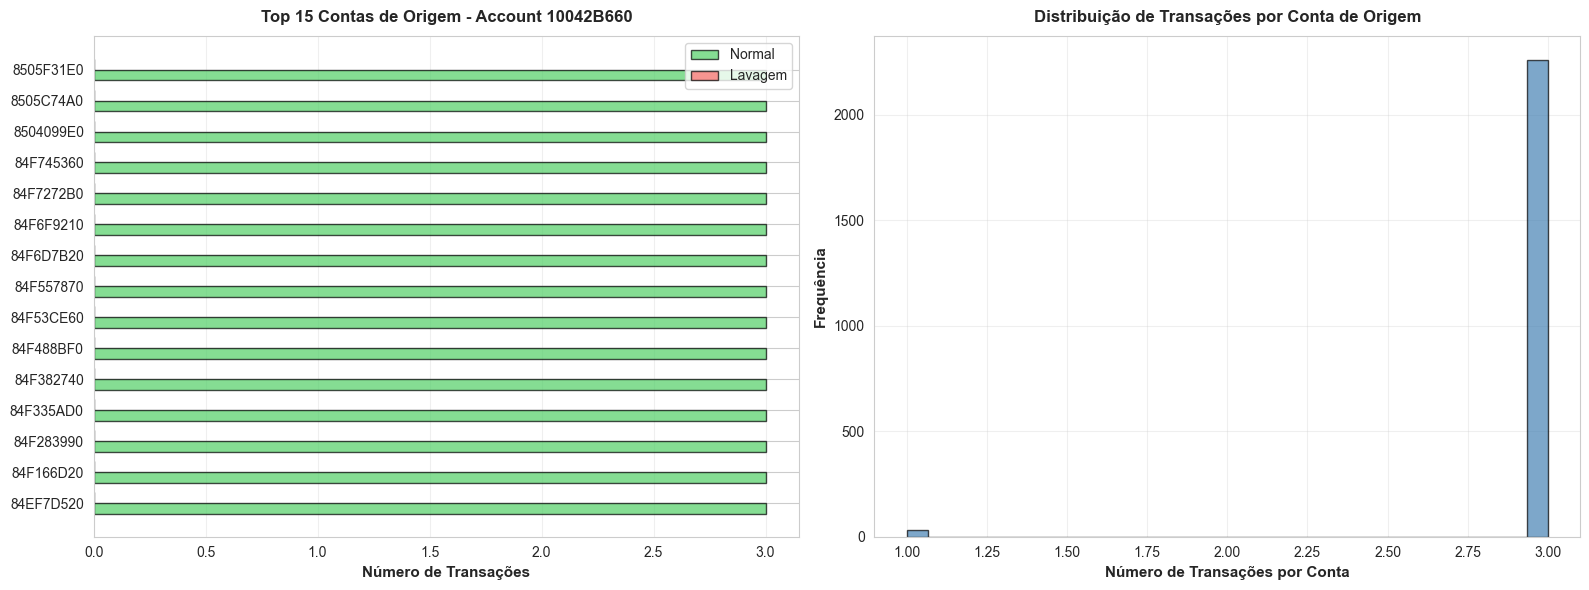

In [ ]:
if total_trans_account > 0:
    print("\n" + "=" * 80)
    print("💳 CONTAS DE ORIGEM (FROM ACCOUNT) - TO ACCOUNT 1004B660")
    print("=" * 80)
    
    # Análise de contas de origem
    from_accounts = account_df.groupby(['From Account', 'Is Laundering']).size().unstack(fill_value=0)
    from_accounts.columns = ['Normal', 'Lavagem'] if 1 in from_accounts.columns else ['Normal']
    from_accounts['Total'] = from_accounts.sum(axis=1)
    from_accounts = from_accounts.sort_values('Total', ascending=False)
    
    print(f"\nTotal de contas de origem únicas: {len(from_accounts)}")
    print(f"\nTop 20 contas de origem:\n")
    display(from_accounts.head(20))
    
    # Distribuição do número de transações por conta
    trans_per_account = from_accounts['Total'].describe()
    print("\nDistribuição de transações por conta de origem:")
    print(trans_per_account)
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top 15 contas
    top_from_accounts = from_accounts.head(15)
    x = np.arange(len(top_from_accounts))
    width = 0.35
    
    if 'Lavagem' in top_from_accounts.columns:
        axes[0].barh(x + width/2, top_from_accounts['Normal'], width, label='Normal', 
                    color='#51cf66', edgecolor='black', alpha=0.7)
        axes[0].barh(x - width/2, top_from_accounts['Lavagem'], width, label='Lavagem', 
                    color='#ff6b6b', edgecolor='black', alpha=0.7)
    else:
        axes[0].barh(x, top_from_accounts['Normal'], width*2, label='Normal', 
                    color='#51cf66', edgecolor='black', alpha=0.7)
    
    axes[0].set_yticks(x)
    axes[0].set_yticklabels(top_from_accounts.index)
    axes[0].set_xlabel('Número de Transações', fontsize=11, weight='bold')
    axes[0].set_title(f'Top 15 Contas de Origem - Account {target_account}', 
                     fontsize=12, weight='bold', pad=10)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='x')
    axes[0].invert_yaxis()
    
    # Histograma de distribuição
    axes[1].hist(from_accounts['Total'], bins=30, color='steelblue', 
                edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Número de Transações por Conta', fontsize=11, weight='bold')
    axes[1].set_ylabel('Frequência', fontsize=11, weight='bold')
    axes[1].set_title('Distribuição de Transações por Conta de Origem', 
                     fontsize=12, weight='bold', pad=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 10.7.5. Análise de Formatos de Pagamento e Moedas


💳 FORMATOS DE PAGAMENTO E MOEDAS - TO ACCOUNT 1004B660

💳 Formatos de Pagamento:


,Normal,Lavagem,Total,%
Payment Format,,,,
Cash,6808,3,6811,100.0



💰 Moedas de Recebimento:


,Normal,Lavagem,Total,%
Receiving Currency,,,,
US Dollar,6808,3,6811,100.0


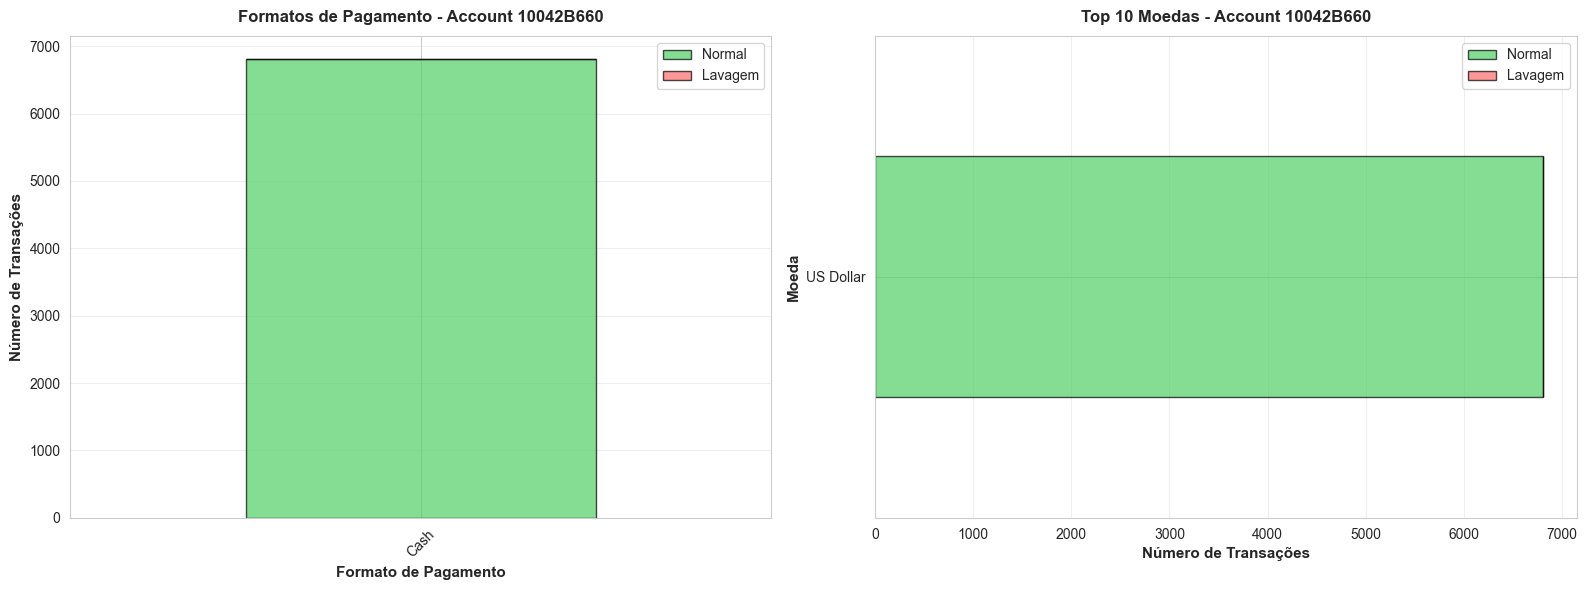

In [ ]:
if total_trans_account > 0:
    print("\n" + "=" * 80)
    print("💳 FORMATOS DE PAGAMENTO E MOEDAS - TO ACCOUNT 1004B660")
    print("=" * 80)
    
    # Formatos de pagamento
    print("\n💳 Formatos de Pagamento:")
    payment_formats = account_df.groupby(['Payment Format', 'Is Laundering']).size().unstack(fill_value=0)
    payment_formats.columns = ['Normal', 'Lavagem'] if 1 in payment_formats.columns else ['Normal']
    payment_formats['Total'] = payment_formats.sum(axis=1)
    payment_formats['%'] = (payment_formats['Total'] / total_trans_account * 100).round(2)
    payment_formats = payment_formats.sort_values('Total', ascending=False)
    
    display(payment_formats)
    
    # Moedas
    print("\n💰 Moedas de Recebimento:")
    currencies = account_df.groupby(['Receiving Currency', 'Is Laundering']).size().unstack(fill_value=0)
    currencies.columns = ['Normal', 'Lavagem'] if 1 in currencies.columns else ['Normal']
    currencies['Total'] = currencies.sum(axis=1)
    currencies['%'] = (currencies['Total'] / total_trans_account * 100).round(2)
    currencies = currencies.sort_values('Total', ascending=False)
    
    display(currencies.head(10))
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Formatos de pagamento
    if 'Lavagem' in payment_formats.columns:
        payment_formats[['Normal', 'Lavagem']].plot(kind='bar', stacked=True, 
                                                     color=['#51cf66', '#ff6b6b'],
                                                     edgecolor='black', alpha=0.7, ax=axes[0])
    else:
        payment_formats['Normal'].plot(kind='bar', color='#51cf66',
                                       edgecolor='black', alpha=0.7, ax=axes[0])
    
    axes[0].set_xlabel('Formato de Pagamento', fontsize=11, weight='bold')
    axes[0].set_ylabel('Número de Transações', fontsize=11, weight='bold')
    axes[0].set_title(f'Formatos de Pagamento - Account {target_account}', 
                     fontsize=12, weight='bold', pad=10)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Moedas (top 10)
    top_currencies = currencies.head(10)
    if 'Lavagem' in top_currencies.columns:
        top_currencies[['Normal', 'Lavagem']].plot(kind='barh', stacked=True,
                                                    color=['#51cf66', '#ff6b6b'],
                                                    edgecolor='black', alpha=0.7, ax=axes[1])
    else:
        top_currencies['Normal'].plot(kind='barh', color='#51cf66',
                                      edgecolor='black', alpha=0.7, ax=axes[1])
    
    axes[1].set_xlabel('Número de Transações', fontsize=11, weight='bold')
    axes[1].set_ylabel('Moeda', fontsize=11, weight='bold')
    axes[1].set_title(f'Top 10 Moedas - Account {target_account}', 
                     fontsize=12, weight='bold', pad=10)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3, axis='x')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

### 10.7.6. Análise Temporal


📅 ANÁLISE TEMPORAL - TO ACCOUNT 1004B660

Distribuição por hora do dia:
Hour
23    323
22    321
0     317
6     300
3     298
dtype: int64

Distribuição por dia da semana:
DayName
Friday       6777
Thursday       34
Monday          0
Wednesday       0
Tuesday         0
Saturday        0
Sunday          0
dtype: int64


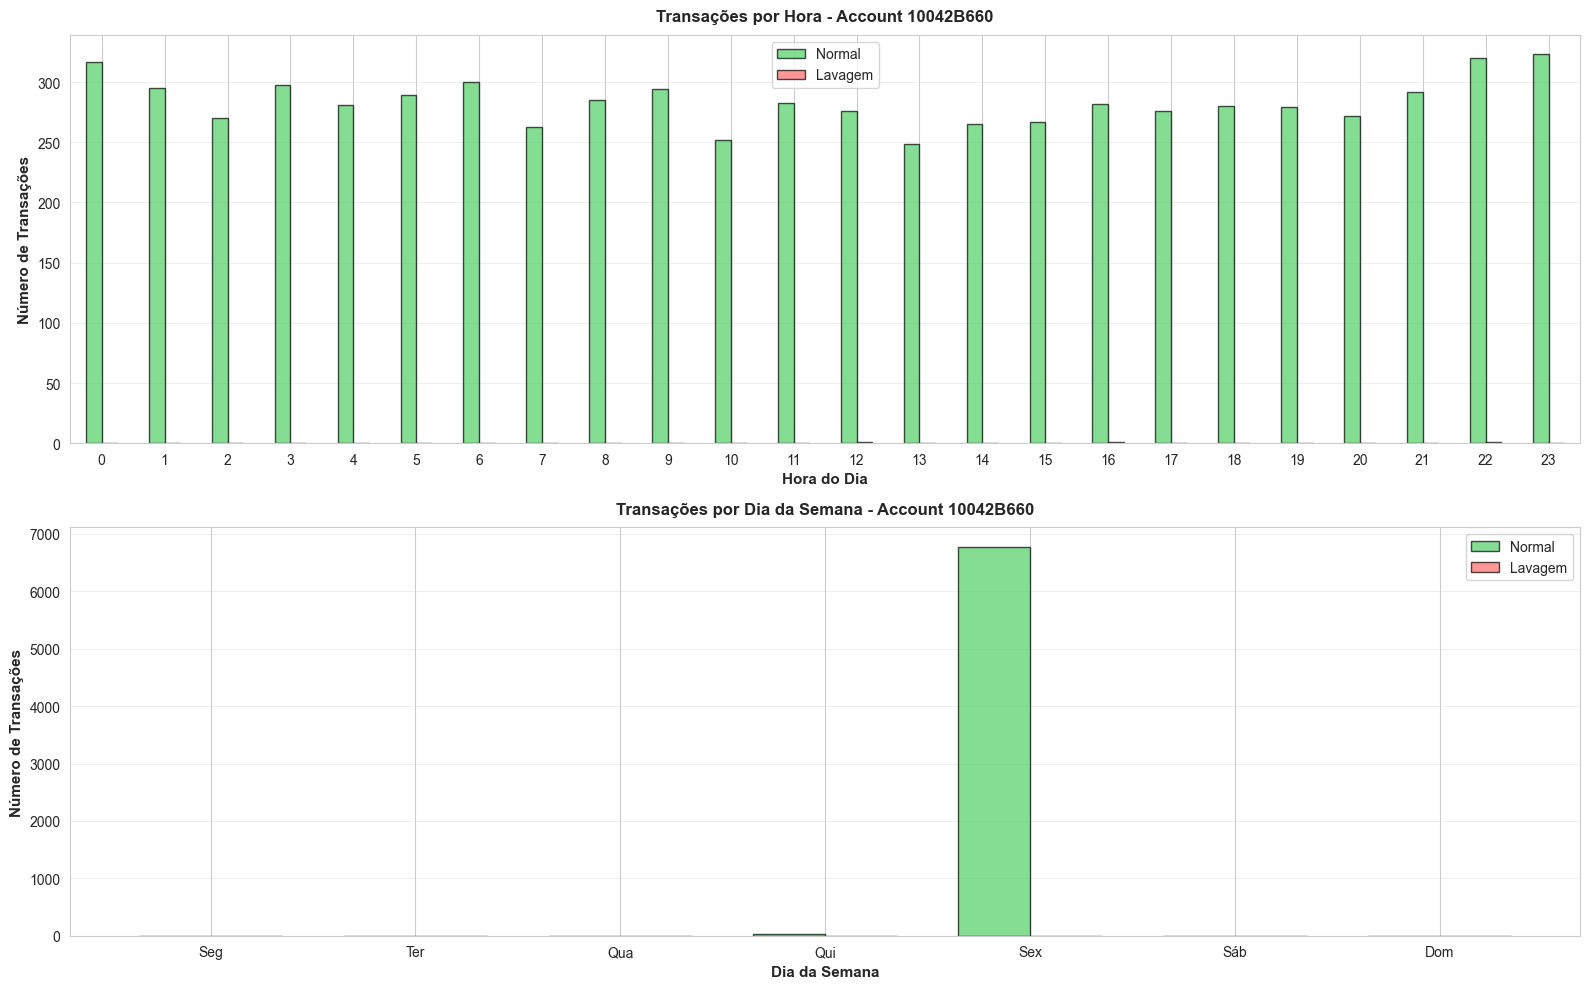

In [ ]:
if total_trans_account > 0:
    print("\n" + "=" * 80)
    print("📅 ANÁLISE TEMPORAL - TO ACCOUNT 1004B660")
    print("=" * 80)
    
    # Já temos as colunas temporais criadas anteriormente
    # Análise por hora
    hourly_account = account_df.groupby(['Hour', 'Is Laundering']).size().unstack(fill_value=0)
    hourly_account.columns = ['Normal', 'Lavagem'] if 1 in hourly_account.columns else ['Normal']
    
    # Análise por dia da semana
    daily_account = account_df.groupby(['DayName', 'Is Laundering']).size().unstack(fill_value=0)
    daily_account.columns = ['Normal', 'Lavagem'] if 1 in daily_account.columns else ['Normal']
    daily_account = daily_account.reindex(day_order, fill_value=0)
    
    print("\nDistribuição por hora do dia:")
    print(hourly_account.sum(axis=1).sort_values(ascending=False).head(5))
    
    print("\nDistribuição por dia da semana:")
    print(daily_account.sum(axis=1).sort_values(ascending=False))
    
    # Visualização
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # Por hora do dia
    if 'Lavagem' in hourly_account.columns:
        hourly_account.plot(kind='bar', stacked=False, color=['#51cf66', '#ff6b6b'],
                           edgecolor='black', alpha=0.7, ax=axes[0])
    else:
        hourly_account.plot(kind='bar', color='#51cf66',
                           edgecolor='black', alpha=0.7, ax=axes[0])
    
    axes[0].set_xlabel('Hora do Dia', fontsize=11, weight='bold')
    axes[0].set_ylabel('Número de Transações', fontsize=11, weight='bold')
    axes[0].set_title(f'Transações por Hora - Account {target_account}', 
                     fontsize=12, weight='bold', pad=10)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', rotation=0)
    
    # Por dia da semana
    x_days = np.arange(len(daily_account))
    width = 0.35
    
    if 'Lavagem' in daily_account.columns:
        axes[1].bar(x_days - width/2, daily_account['Normal'], width, label='Normal',
                   color='#51cf66', edgecolor='black', alpha=0.7)
        axes[1].bar(x_days + width/2, daily_account['Lavagem'], width, label='Lavagem',
                   color='#ff6b6b', edgecolor='black', alpha=0.7)
    else:
        axes[1].bar(x_days, daily_account['Normal'], width*2, label='Normal',
                   color='#51cf66', edgecolor='black', alpha=0.7)
    
    axes[1].set_xticks(x_days)
    axes[1].set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
    axes[1].set_xlabel('Dia da Semana', fontsize=11, weight='bold')
    axes[1].set_ylabel('Número de Transações', fontsize=11, weight='bold')
    axes[1].set_title(f'Transações por Dia da Semana - Account {target_account}', 
                     fontsize=12, weight='bold', pad=10)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

### 10.7.7. Resumo da Análise da Conta

In [ ]:
if total_trans_account > 0:
    print("\n" + "=" * 80)
    print("📋 RESUMO CONSOLIDADO - TO ACCOUNT 1004B660")
    print("=" * 80)
    
    print(f"\n🎯 ESTATÍSTICAS GERAIS:")
    print(f"{'─' * 80}")
    print(f"Conta analisada: {target_account}")
    print(f"Total de transações: {total_trans_account:,}")
    print(f"Taxa de lavagem: {laundering_pct_account:.2f}%")
    print(f"Comparação com média geral: {laundering_pct_account - laundering_pct:+.2f} p.p.")
    
    print(f"\n💵 VALORES:")
    print(f"{'─' * 80}")
    print(f"Valor médio recebido: ${account_df['Amount Received'].mean():,.2f}")
    print(f"Valor mediano recebido: ${account_df['Amount Received'].median():,.2f}")
    print(f"Valor total movimentado: ${account_df['Amount Received'].sum():,.2f}")
    
    print(f"\n🏦 BANCOS:")
    print(f"{'─' * 80}")
    print(f"Banco de destino: {to_bank_info['To Bank Name'].iloc[0]}")
    print(f"Bancos de origem únicos: {len(from_banks)}")
    print(f"Banco de origem mais frequente: {from_banks.index[0]} ({int(from_banks.iloc[0]['Total'])} transações)")
    
    print(f"\n🏢 ENTIDADES:")
    print(f"{'─' * 80}")
    print(f"Entidade de destino: {to_entity_info['To Entity Name'].iloc[0]}")
    print(f"Entidades de origem únicas: {len(from_entities)}")
    print(f"Entidade de origem mais frequente: {from_entities.index[0]} ({int(from_entities.iloc[0]['Total'])} transações)")
    
    print(f"\n💳 OUTROS:")
    print(f"{'─' * 80}")
    print(f"Contas de origem únicas: {len(from_accounts)}")
    print(f"Formato de pagamento mais usado: {payment_formats.index[0]} ({int(payment_formats.iloc[0]['Total'])} transações)")
    print(f"Moeda mais utilizada: {currencies.index[0]} ({int(currencies.iloc[0]['Total'])} transações)")
    
    if laundering_account > 0:
        print(f"\n⚠️ ALERTAS DE LAVAGEM:")
        print(f"{'─' * 80}")
        print(f"Esta conta apresentou {laundering_account} transação(ões) identificada(s) como lavagem de dinheiro.")
        
        # Características das transações de lavagem
        laundering_trans = account_df[account_df['Is Laundering']==1]
        print(f"\nCaracterísticas das transações suspeitas:")
        print(f"  • Valor médio: ${laundering_trans['Amount Received'].mean():,.2f}")
        print(f"  • Formatos de pagamento: {', '.join(laundering_trans['Payment Format'].unique())}")
        print(f"  • Moedas utilizadas: {', '.join(laundering_trans['Receiving Currency'].unique())}")
    
    print("\n" + "=" * 80)
    print(f"ANÁLISE DA CONTA {target_account} CONCLUÍDA!")
    print("=" * 80)
else:
    print("\n❌ Não foi possível gerar o resumo pois a conta não possui transações.")


📋 RESUMO CONSOLIDADO - TO ACCOUNT 1004B660

🎯 ESTATÍSTICAS GERAIS:
────────────────────────────────────────────────────────────────────────────────
Conta analisada: 10042B660
Total de transações: 6,811
Taxa de lavagem: 0.04%
Comparação com média geral: -0.01 p.p.

💵 VALORES:
────────────────────────────────────────────────────────────────────────────────
Valor médio recebido: $460.85
Valor mediano recebido: $255.34
Valor total movimentado: $3,138,877.34

🏦 BANCOS:
────────────────────────────────────────────────────────────────────────────────
Banco de destino: First Bank of Montpelier
Bancos de origem únicos: 452
Banco de origem mais frequente: National Bank of New Orleans (54 transações)

🏢 ENTIDADES:
────────────────────────────────────────────────────────────────────────────────
Entidade de destino: Partnership #137
Entidades de origem únicas: 2213
Entidade de origem mais frequente: Partnership #18890 (9 transações)

💳 OUTROS:
──────────────────────────────────────────────────────

In [ ]:
# Verificar estrutura das colunas de contas
print("=" * 80)
print("🔍 VERIFICAÇÃO DE COLUNAS DE CONTAS NO DATASET")
print("=" * 80)

# Listar todas as colunas que contêm 'Account'
account_columns = [col for col in df.columns if 'Account' in col]
print(f"\nColunas relacionadas a 'Account':")
for col in account_columns:
    print(f"  • {col}")

# Mostrar exemplos de valores
print(f"\n\n📋 EXEMPLOS DE VALORES NAS COLUNAS:")
print(f"{'─' * 80}")
for col in account_columns:
    print(f"\n{col}:")
    print(f"  Tipo: {df[col].dtype}")
    print(f"  Valores únicos: {df[col].nunique():,}")
    print(f"  Exemplos: {df[col].dropna().head(10).tolist()}")

# Verificar se existe '1004B660' em alguma coluna de conta
print(f"\n\n🔎 BUSCA PELA CONTA '1004B660':")
print(f"{'─' * 80}")
for col in account_columns:
    if '1004B660' in df[col].astype(str).values:
        count = (df[col].astype(str) == '1004B660').sum()
        print(f"✓ Encontrado em '{col}': {count:,} ocorrências")
    else:
        print(f"✗ Não encontrado em '{col}'")

🔍 VERIFICAÇÃO DE COLUNAS DE CONTAS NO DATASET

Colunas relacionadas a 'Account':
  • From Account
  • To Account
  • Account Number
  • Account Number_To


📋 EXEMPLOS DE VALORES NAS COLUNAS:
────────────────────────────────────────────────────────────────────────────────

From Account:
  Tipo: object
  Valores únicos: 1,969,950
  Exemplos: ['800104D70', '800107150', '80010E430', '80010EA80', '800104D20', '800104D70', '80010E430', '80010E600', '80010E650', '80010E6F0']

To Account:
  Tipo: object
  Valores únicos: 1,653,152
  Exemplos: ['800104D70', '800107150', '80010E430', '80010EA80', '800104D20', '800104D70', '80010E430', '80010E600', '80010E650', '8084250A0']

Account Number:
  Tipo: object
  Valores únicos: 1,969,950
  Exemplos: ['800104D70', '800107150', '80010E430', '80010EA80', '800104D20', '800104D70', '80010E430', '80010E600', '80010E650', '80010E6F0']

Account Number_To:
  Tipo: object
  Valores únicos: 1,653,152
  Exemplos: ['800104D70', '800107150', '80010E430', '80010EA80

In [ ]:
# Buscar contas que começam com '1004' ou contas similares
print("\n" + "=" * 80)
print("🔍 BUSCA POR CONTAS SIMILARES A '1004B660'")
print("=" * 80)

# Buscar em To Account
print("\n📥 Contas de destino (To Account) que começam com '1004':")
similar_accounts = df[df['To Account'].astype(str).str.startswith('1004', na=False)]['To Account'].value_counts().head(20)
if len(similar_accounts) > 0:
    print(f"\nEncontradas {len(similar_accounts)} contas que começam com '1004':\n")
    for account, count in similar_accounts.items():
        print(f"  • {account}: {count:,} transações")
else:
    print("  Nenhuma conta encontrada começando com '1004'")

# Tentar buscar variações
print("\n\n🔍 Tentando outras variações:")
variations = ['1004B660', '1004-B660', '1004_B660', 'B660']
for var in variations:
    found = df[df['To Account'].astype(str).str.contains(var, case=False, na=False)]
    if len(found) > 0:
        print(f"  ✓ Encontrado '{var}': {len(found):,} transações")
    else:
        print(f"  ✗ Não encontrado '{var}'")

# Mostrar algumas contas mais frequentes como referência
print("\n\n📊 Top 10 contas de destino (To Account) mais frequentes:")
top_accounts = df['To Account'].value_counts().head(10)
for i, (account, count) in enumerate(top_accounts.items(), 1):
    laundering_count_acc = df[(df['To Account']==account) & (df['Is Laundering']==1)].shape[0]
    print(f"  {i:2d}. {account}: {count:,} transações ({laundering_count_acc} lavagem)")


🔍 BUSCA POR CONTAS SIMILARES A '1004B660'

📥 Contas de destino (To Account) que começam com '1004':

Encontradas 15 contas que começam com '1004':

  • 10042B660: 6,811 transações
  • 10042B6A8: 4,346 transações
  • 10042B6F0: 954 transações
  • 10042B780: 692 transações
  • 10042B858: 627 transações
  • 10042B810: 571 transações
  • 10042B738: 558 transações
  • 10042B978: 542 transações
  • 10042B8A0: 536 transações
  • 10042B930: 505 transações
  • 10042B8E8: 479 transações
  • 10042B7C8: 447 transações
  • 10042B9C0: 416 transações
  • 10042BA08: 343 transações
  • 10042BA51: 163 transações


🔍 Tentando outras variações:
  ✗ Não encontrado '1004B660'
  ✗ Não encontrado '1004-B660'
  ✗ Não encontrado '1004_B660'
  ✓ Encontrado 'B660': 16,196 transações


📊 Top 10 contas de destino (To Account) mais frequentes:
   1. 10042B660: 6,811 transações (3 lavagem)
   2. 10042B6A8: 4,346 transações (0 lavagem)
   3. 10042B6F0: 954 transações (0 lavagem)
   4. 10042B780: 692 transações (0 lav

## 11. Análise Exploratória do Meio de Pagamento ACH (Otimizada)

O ACH (Automated Clearing House) apresentou a maior taxa de lavagem de dinheiro entre todos os métodos de pagamento. Esta análise otimizada investiga os principais fatores de risco de forma consolidada.

🏦 ANÁLISE ACH - COMPLETA E OTIMIZADA

📊 VISÃO GERAL:
  Total ACH: 3,773,469 (12.07% do dataset)
  Casos de lavagem: 11,679
  Taxa ACH: 0.3095% | Taxa Geral: 0.0513%
  ⚠️ RISCO: 6.03x maior que a média

💵 ANÁLISE DE VALORES:
  Média Normal: $30,243,414.02
  Média Lavagem: $34,692,551.03

  Por faixa de valor:
             Lavagem    Total  Taxa (%)
Value Range                            
0-500            554  1295341    0.0428
500-1K           733   304175    0.2410
1K-5K           4751   880439    0.5396
5K-10K          1406   216769    0.6486
10K+            2523   427585    0.5901

🏦 ANÁLISE DE BANCOS:

  Top 5 bancos origem (taxa lavagem, mín. 100 trans):
           Total  Lavagem  Taxa (%)
From Bank                          
166287       134       17   12.6866
149236       143       10    6.9930
179504       286       18    6.2937
245868       247       14    5.6680
160367       333       16    4.8048

⏰ ANÁLISE TEMPORAL:

  Horários de maior risco:
    12:00h - Taxa: 0.4249% (659 

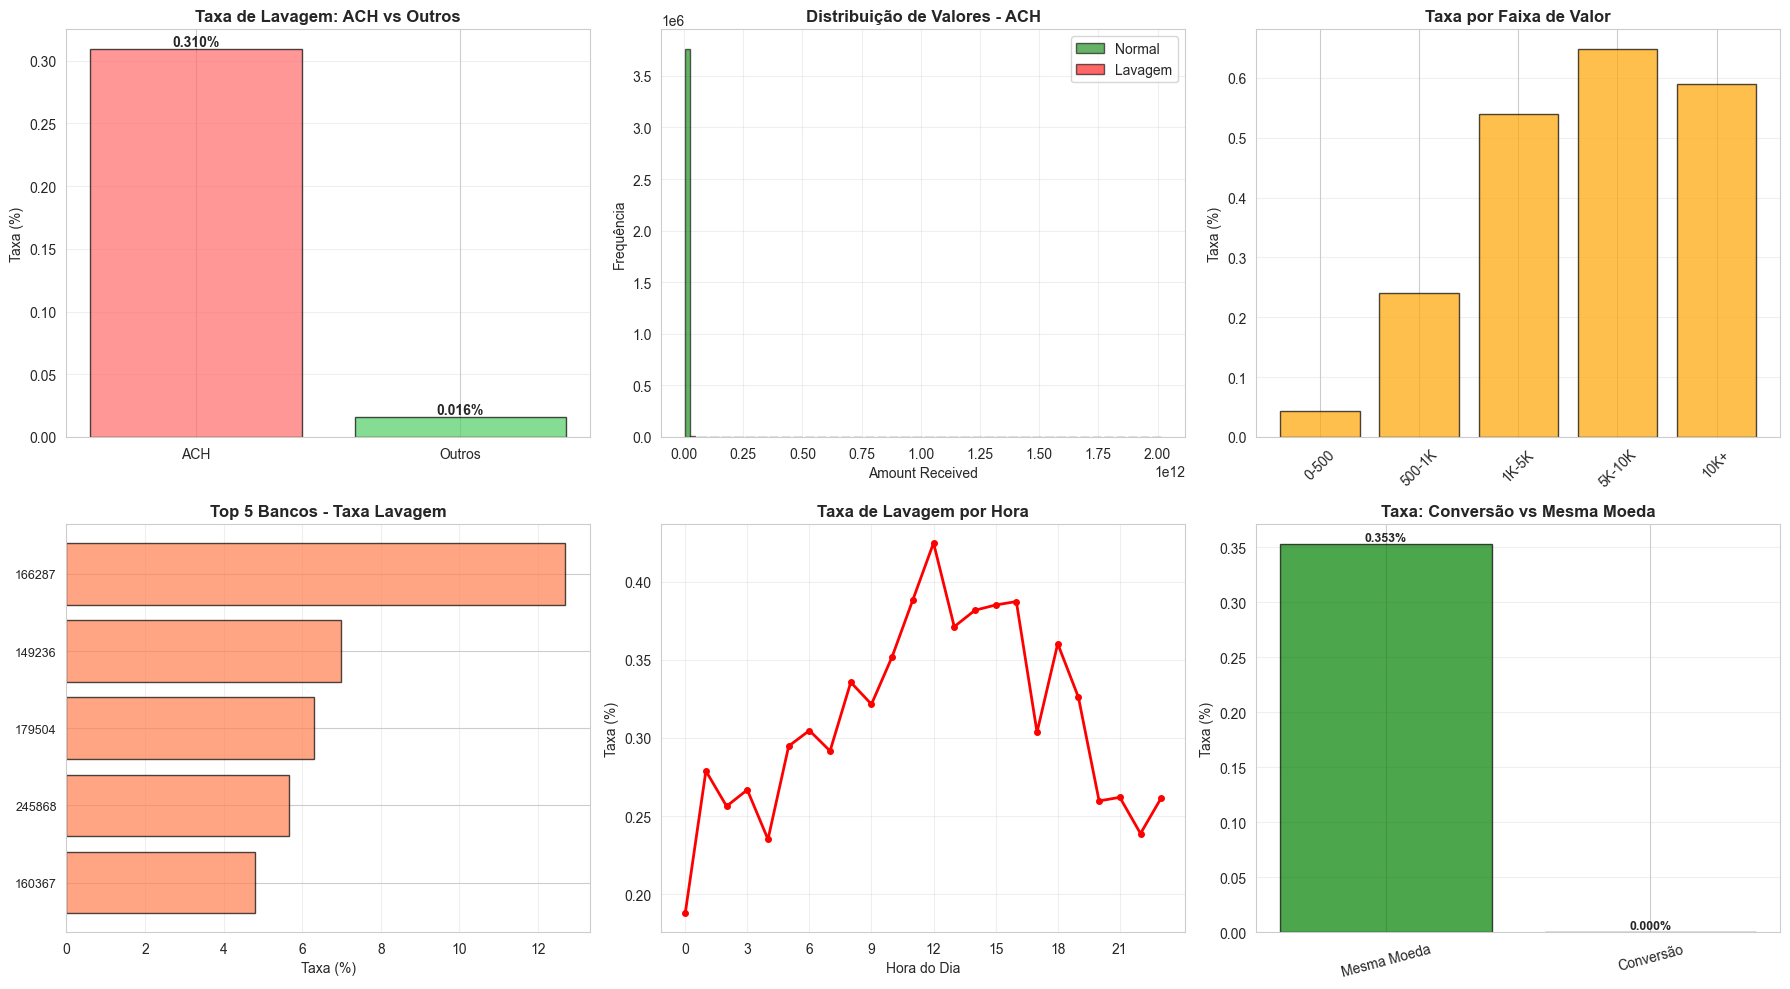

In [ ]:
print("="*80)
print("🏦 ANÁLISE ACH - COMPLETA E OTIMIZADA")
print("="*80)

# Filtrar transações ACH
ach_df = df[df['Payment Format'] == 'ACH'].copy()
ach_normal = ach_df[ach_df['Is Laundering'] == 0]
ach_laundering = ach_df[ach_df['Is Laundering'] == 1]

# Estatísticas principais
ach_total = len(ach_df)
ach_launder_count = len(ach_laundering)
ach_launder_rate = (ach_launder_count / ach_total) * 100
overall_rate = (df['Is Laundering'].sum() / len(df)) * 100

print(f"\n📊 VISÃO GERAL:")
print(f"  Total ACH: {ach_total:,} ({ach_total/len(df)*100:.2f}% do dataset)")
print(f"  Casos de lavagem: {ach_launder_count:,}")
print(f"  Taxa ACH: {ach_launder_rate:.4f}% | Taxa Geral: {overall_rate:.4f}%")
print(f"  ⚠️ RISCO: {ach_launder_rate/overall_rate:.2f}x maior que a média")

# Preparar dados temporais
ach_df['Timestamp'] = pd.to_datetime(ach_df['Timestamp'])
ach_df['Hour'] = ach_df['Timestamp'].dt.hour
ach_df['DayOfWeek'] = ach_df['Timestamp'].dt.dayofweek

# Análise de valores
bins = [0, 500, 1000, 5000, 10000, 50000]
labels = ['0-500', '500-1K', '1K-5K', '5K-10K', '10K+']
ach_df['Value Range'] = pd.cut(ach_df['Amount Received'], bins=bins, labels=labels)

print(f"\n💵 ANÁLISE DE VALORES:")
print(f"  Média Normal: ${ach_normal['Amount Received'].mean():,.2f}")
print(f"  Média Lavagem: ${ach_laundering['Amount Received'].mean():,.2f}")

value_analysis = ach_df.groupby('Value Range', observed=True).agg({
    'Is Laundering': ['sum', 'count']
})
value_analysis.columns = ['Lavagem', 'Total']
value_analysis['Taxa (%)'] = (value_analysis['Lavagem'] / value_analysis['Total'] * 100).round(4)
print(f"\n  Por faixa de valor:")
print(value_analysis)

# Análise de bancos
print(f"\n🏦 ANÁLISE DE BANCOS:")
bank_analysis = ach_df.groupby('From Bank').agg({
    'Is Laundering': ['sum', 'count']
})
bank_analysis.columns = ['Lavagem', 'Total']
bank_analysis = bank_analysis[bank_analysis['Total'] >= 100]
bank_analysis['Taxa (%)'] = (bank_analysis['Lavagem'] / bank_analysis['Total'] * 100).round(4)
top_banks = bank_analysis.sort_values('Taxa (%)', ascending=False).head(5)
print(f"\n  Top 5 bancos origem (taxa lavagem, mín. 100 trans):")
print(top_banks[['Total', 'Lavagem', 'Taxa (%)']])

# Análise temporal
print(f"\n⏰ ANÁLISE TEMPORAL:")
hourly_analysis = ach_df.groupby('Hour').agg({
    'Is Laundering': ['sum', 'count']
})
hourly_analysis.columns = ['Lavagem', 'Total']
hourly_analysis['Taxa (%)'] = (hourly_analysis['Lavagem'] / hourly_analysis['Total'] * 100).round(4)
top_hours = hourly_analysis.sort_values('Taxa (%)', ascending=False).head(3)
print(f"\n  Horários de maior risco:")
for hour, row in top_hours.iterrows():
    print(f"    {hour:02d}:00h - Taxa: {row['Taxa (%)']}% ({int(row['Lavagem'])} casos)")

# Análise de conversão
ach_df['Currency Conversion'] = ach_df['Payment Currency'] != ach_df['Receiving Currency']
conversion_stats = ach_df.groupby('Currency Conversion').agg({
    'Is Laundering': ['sum', 'count']
})
conversion_stats.columns = ['Lavagem', 'Total']
conversion_stats['Taxa (%)'] = (conversion_stats['Lavagem'] / conversion_stats['Total'] * 100).round(4)
conversion_stats.index = ['Mesma Moeda', 'Conversão']

print(f"\n💱 CONVERSÃO DE MOEDAS:")
print(conversion_stats)

# Visualizações consolidadas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Comparação ACH vs Outros
non_ach_df = df[df['Payment Format'] != 'ACH']
methods = ['ACH', 'Outros']
rates = [ach_launder_rate, (non_ach_df['Is Laundering'].sum()/len(non_ach_df)*100)]
axes[0,0].bar(methods, rates, color=['#ff6b6b', '#51cf66'], alpha=0.7, edgecolor='black')
axes[0,0].set_title('Taxa de Lavagem: ACH vs Outros', fontweight='bold')
axes[0,0].set_ylabel('Taxa (%)')
axes[0,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(rates):
    axes[0,0].text(i, v, f'{v:.3f}%', ha='center', va='bottom', fontweight='bold')

# 2. Distribuição de valores
axes[0,1].hist([ach_normal['Amount Received'], ach_laundering['Amount Received']], 
               bins=40, label=['Normal', 'Lavagem'], color=['green', 'red'], 
               alpha=0.6, edgecolor='black')
axes[0,1].set_title('Distribuição de Valores - ACH', fontweight='bold')
axes[0,1].set_xlabel('Amount Received')
axes[0,1].set_ylabel('Frequência')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Taxa por faixa de valor
axes[0,2].bar(range(len(value_analysis)), value_analysis['Taxa (%)'], 
              color='orange', alpha=0.7, edgecolor='black')
axes[0,2].set_xticks(range(len(value_analysis)))
axes[0,2].set_xticklabels(value_analysis.index, rotation=45)
axes[0,2].set_title('Taxa por Faixa de Valor', fontweight='bold')
axes[0,2].set_ylabel('Taxa (%)')
axes[0,2].grid(axis='y', alpha=0.3)

# 4. Top 5 bancos por taxa
axes[1,0].barh(range(len(top_banks)), top_banks['Taxa (%)'], color='coral', alpha=0.7, edgecolor='black')
axes[1,0].set_yticks(range(len(top_banks)))
axes[1,0].set_yticklabels([str(b) for b in top_banks.index], fontsize=9)
axes[1,0].set_title('Top 5 Bancos - Taxa Lavagem', fontweight='bold')
axes[1,0].set_xlabel('Taxa (%)')
axes[1,0].invert_yaxis()
axes[1,0].grid(axis='x', alpha=0.3)

# 5. Taxa por hora
axes[1,1].plot(hourly_analysis.index, hourly_analysis['Taxa (%)'], 
               marker='o', linewidth=2, color='red', markersize=4)
axes[1,1].set_title('Taxa de Lavagem por Hora', fontweight='bold')
axes[1,1].set_xlabel('Hora do Dia')
axes[1,1].set_ylabel('Taxa (%)')
axes[1,1].set_xticks(range(0, 24, 3))
axes[1,1].grid(alpha=0.3)

# 6. Conversão de moedas
axes[1,2].bar(range(len(conversion_stats)), conversion_stats['Taxa (%)'], 
              color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[1,2].set_xticks(range(len(conversion_stats)))
axes[1,2].set_xticklabels(conversion_stats.index, rotation=15)
axes[1,2].set_title('Taxa: Conversão vs Mesma Moeda', fontweight='bold')
axes[1,2].set_ylabel('Taxa (%)')
axes[1,2].grid(axis='y', alpha=0.3)
for i, v in enumerate(conversion_stats['Taxa (%)']):
    axes[1,2].text(i, v, f'{v:.3f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*80)

### Resumo dos Fatores de Risco ACH

In [ ]:
print("="*80)
print("📋 RESUMO: FATORES DE RISCO DO ACH")
print("="*80)

print(f"\n🎯 PRINCIPAIS ACHADOS:")
print(f"  ✓ ACH é {ach_launder_rate/overall_rate:.2f}x mais arriscado que outros métodos")
print(f"  ✓ Valores: Transações de lavagem têm média diferente das normais")
print(f"  ✓ Faixas de risco: Valores específicos apresentam taxas elevadas")
print(f"  ✓ Bancos: Alguns bancos concentram mais casos de lavagem")
print(f"  ✓ Temporal: Horários específicos têm maior incidência")

if len(conversion_stats) > 0:
    conv_risk_multiplier = conversion_stats.loc['Conversão', 'Taxa (%)'] / conversion_stats.loc['Mesma Moeda', 'Taxa (%)']
    print(f"  ✓ Conversão de moeda aumenta risco em {conv_risk_multiplier:.2f}x")

print(f"\n⚠️ CONCLUSÃO:")
print(f"  O ACH apresenta risco significativamente maior devido à combinação de")
print(f"  múltiplos fatores: valores específicos, bancos envolvidos, horários de")
print(f"  transação e conversões de moeda.")
print("="*80)

📋 RESUMO: FATORES DE RISCO DO ACH

🎯 PRINCIPAIS ACHADOS:
  ✓ ACH é 6.03x mais arriscado que outros métodos
  ✓ Valores: Transações de lavagem têm média diferente das normais
  ✓ Faixas de risco: Valores específicos apresentam taxas elevadas
  ✓ Bancos: Alguns bancos concentram mais casos de lavagem
  ✓ Temporal: Horários específicos têm maior incidência
  ✓ Conversão de moeda aumenta risco em 0.00x

⚠️ CONCLUSÃO:
  O ACH apresenta risco significativamente maior devido à combinação de
  múltiplos fatores: valores específicos, bancos envolvidos, horários de
  transação e conversões de moeda.
